In [137]:
# ============================================================================
# NOTEBOOK 10: CROSS-PROBABILITY STICKY MODEL ANALYSIS
# Compares Q-learning + sticky model parameters across 80-20 and 100-0 conditions
# All preprocessing consistent with notebook 07 (80-20 behavioral states)
# ============================================================================

In [138]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.optimize import minimize
from scipy.stats import ttest_rel, ttest_ind, ttest_1samp, sem
import warnings
warnings.filterwarnings('ignore')

# ── Style ─────────────────────────────────────────────────────────────────────
FONTSIZE    = 8
LINE_WIDTH  = 0.8
TICK_LENGTH = 3
plt.rcParams['font.family']  = 'Arial'
plt.rcParams['svg.fonttype'] = 'none'

# ── Colors ────────────────────────────────────────────────────────────────────
COLOR_80_20 = '#2E86AB'
COLOR_100_0 = '#A23B72'


# Standard animal order (left to right in all plots)
ANIMAL_ORDER = [
    'Coral',
    'Tuna',
    'Fiona',
    'Salmon',
    'Knuckles',
    'Raven', 
    'Sonic',
    'Zazu',
    'Griffin',
    'Sunflower',

]

# Standard animal colors (matching your asymptotic performance figure)
ANIMAL_COLORS = {
    'Coral': '#e74c3c',      # Coral/Red
    'Raven': '#2ecc71',      # Green
    'Tuna': '#8b7355',       # Brown/Tan
    'Sonic': '#34495e',      # Dark Gray
    'Griffin': '#9b59b6',    # Purple
    'Sunflower': '#1abc9c',  # Teal/Cyan
    'Zazu': '#3498db',       # Light Blue
    'Salmon': '#f39c12',     # Orange/Yellow
    'Fiona':  '#e91e63',      # Pink/Magenta
    'Knuckles': '#e67e22'    # Orange/Brown
}

OVERLAPPING_ANIMALS = ['Fiona', 'Knuckles', 'Sonic', 'Sunflower', 'Zazu']

# ── Paths ─────────────────────────────────────────────────────────────────────
BASE_PATH = (
    '/Users/kevinmastro/Library/CloudStorage/'
    'GoogleDrive-kmastro@broadinstitute.org/Shared drives/Broad Marmoset/'
    '2-Experiments/5 - Monkey Logic Task/4 - Outputs/'
)

SAVE_PATH_80 = os.path.join(
    BASE_PATH, '1-dataframes', 'behavioral_states_80_20_updated'
)
RAW_PATH_100 = os.path.join(
    BASE_PATH, '1-dataframes', 'WhereTask_100-0_Filtered.csv'
)
FIGURE_PATH = os.path.join(BASE_PATH, '2-graphs', 'CrossProbStickyModel')
os.makedirs(FIGURE_PATH, exist_ok=True)

ROLLING_WINDOW = 5

print("✓ Configuration loaded")

✓ Configuration loaded


In [ ]:
print("STEP 1: LOAD 80-20 DATA FROM NOTEBOOK 07")
print("="*70)

# Load preprocessed 80-20 data with behavioral states
df_80_full = pd.read_csv(os.path.join(SAVE_PATH_80, 'df_with_states.csv'))

# Load state config
with open(os.path.join(SAVE_PATH_80, 'state_config.pkl'), 'rb') as f:
    state_config = pickle.load(f)

STATES_ORDERED_FULL = state_config['STATES_ORDERED_FULL']
STATE_COLORS_FULL   = state_config['STATE_COLORS_FULL']

# Load sticky model parameters from notebook 07
sticky_params_80 = pd.read_csv(os.path.join(SAVE_PATH_80, 'sticky_params_df.csv'))

# Filter to overlapping animals
df_80 = df_80_full[df_80_full['Animal_Name'].isin(OVERLAPPING_ANIMALS)].copy()

print(f"80-20 loaded: {len(df_80):,} trials, {df_80['Session_ID'].nunique()} sessions")
print(f"Animals: {sorted(df_80['Animal_Name'].unique())}")
print(f"\n80-20 sticky model parameters:")
print(sticky_params_80[sticky_params_80['animal'].isin(OVERLAPPING_ANIMALS)][
    ['animal', 'alpha', 'beta', 'kappa', 'nll']
].to_string(index=False))

STEP 1: LOAD 80-20 DATA FROM NOTEBOOK 07
80-20 loaded: 36,673 trials, 100 sessions
Animals: ['Fiona', 'Knuckles', 'Sonic', 'Sunflower', 'Zazu']

80-20 sticky model parameters:
   animal    alpha     beta    kappa         nll
    Fiona 0.588792 1.458394 1.438142 2024.023325
 Knuckles 0.700046 1.201415 1.101963 5219.162225
    Sonic 0.836054 0.826765 1.462648 3100.403866
Sunflower 0.874737 1.347100 0.830489 4785.644900
     Zazu 0.701199 0.764339 1.470407 1462.677916


In [140]:
print("STEP 2: LOAD AND PREPROCESS 100-0 DATA")
print("="*70)

# df_100_raw = pd.read_csv(RAW_PATH_100)
df_100_raw = pd.read_csv('/Users/kevinmastro/Library/CloudStorage/GoogleDrive-kmastro@broadinstitute.org/Shared drives/Broad Marmoset/2-Experiments/5 - Monkey Logic Task/4 - Outputs/1-dataframes/100_reversal_data_only.csv')

df_100_raw['Outcome_Binary'] = df_100_raw['Reward'].map({'Rewarded': 1, 'Unrewarded': 0})

if 'Choice_Binary' not in df_100_raw.columns:
        df_100_raw['Choice_Binary'] = df_100_raw['PhysicalChoice'].map({
            'BottomLeft': 0, 'LeftCenter': 0, 'TopLeft': 0,
            'BottomRight': 1, 'RightCenter': 1, 'TopRight': 1,
        })


df_100 = df_100_raw[df_100_raw['Animal_Name'].isin(OVERLAPPING_ANIMALS)].copy()

print(f"100-0 loaded: {len(df_100):,} trials, {df_100['Session_ID'].nunique()} sessions")
print(f"Animals: {sorted(df_100['Animal_Name'].unique())}")

STEP 2: LOAD AND PREPROCESS 100-0 DATA
100-0 loaded: 12,791 trials, 52 sessions
Animals: ['Fiona', 'Knuckles', 'Sonic', 'Sunflower', 'Zazu']


In [141]:
# ── SLOT: Add mixed-session 80-20 dataframe here if available ────────────────
# If you have 80-20 sessions that contain both cued and reversal transitions,
# load that dataframe here and assign it to df_80_mixed.
# Otherwise leave as None and the original df_80 will be used directly.

df_80_mixed = None   # ← replace with pd.read_csv(...) if available

# ─────────────────────────────────────────────────────────────────────────────


def detect_transitions(df, session_col='Session_ID', block_col='BlockCount'):
    """
    Detect block transitions within each session.
    Returns a dataframe with transition type (REVERSAL or CUED) per transition.

    REVERSAL: same physical locations, reward side flips
    CUED    : physical locations change (target set changes)
    """
    records = []
    for session, sdf in df.groupby(session_col):
        sdf = sdf.sort_values('Trial').reset_index(drop=True)
        block_changes = sdf[sdf[block_col].diff().abs() > 0].index.tolist()

        for idx in block_changes:
            if idx == 0:
                continue
            prev = sdf.iloc[idx - 1]
            curr = sdf.iloc[idx]

            # Detect location change using PhysicalChoice sets per block
            prev_locs = set(
                sdf[sdf[block_col] == prev[block_col]]['PhysicalChoice'].dropna()
            )
            curr_locs = set(
                sdf[sdf[block_col] == curr[block_col]]['PhysicalChoice'].dropna()
            )
            trans_type = 'CUED' if prev_locs != curr_locs else 'REVERSAL'

            records.append(dict(
                Session_ID       = session,
                Transition_Trial = sdf.iloc[idx]['Trial'],
                Transition_Type  = trans_type,
                From_Block       = prev[block_col],
                To_Block         = curr[block_col],
            ))

    return pd.DataFrame(records)


def create_pseudo_sessions(df, transition_df, min_blocks=2, min_trials=40):
    """
    Split sessions at CUED transitions into pseudo-sessions.
    Only retains segments with >= min_blocks blocks (i.e., >= 1 reversal)
    and >= min_trials trials.
    """
    records = []

    for session, sdf in df.groupby('Session_ID'):
        sdf = sdf.sort_values('Trial').reset_index(drop=True)
        sess_trans = transition_df[
            (transition_df['Session_ID'] == session) &
            (transition_df['Transition_Type'] == 'CUED')
        ]['Transition_Trial'].tolist()

        trials       = sdf['Trial'].values
        boundaries   = [trials[0]] + sess_trans + [trials[-1] + 1]

        for seg_idx in range(len(boundaries) - 1):
            start = boundaries[seg_idx]
            end   = boundaries[seg_idx + 1]
            seg   = sdf[(sdf['Trial'] >= start) & (sdf['Trial'] < end)].copy()

            if seg['BlockCount'].nunique() < min_blocks:
                continue
            if len(seg) < min_trials:
                continue

            pseudo_id = f'{session}_SEG{seg_idx}'
            seg['Pseudo_Session_ID']  = pseudo_id
            seg['Original_Session_ID'] = session
            seg['Trial_in_Segment']   = range(len(seg))
            seg['Block_in_Segment']   = (
                seg['BlockCount'].rank(method='dense').astype(int) - 1
            )
            records.append(seg)

    if not records:
        return pd.DataFrame()

    out = pd.concat(records, ignore_index=True)
    out['Session_ID'] = out['Pseudo_Session_ID']
    return out


# ── Apply to 100-0 ────────────────────────────────────────────────────────────
print('Detecting transitions in 100-0...')
trans_100 = detect_transitions(df_100_raw)
print(f'  REVERSAL: {(trans_100["Transition_Type"]=="REVERSAL").sum()}')
print(f'  CUED    : {(trans_100["Transition_Type"]=="CUED").sum()}')

print('\nCreating 100-0 pseudo-sessions...')
df_100 = create_pseudo_sessions(df_100_raw, trans_100)
print(f'  Pseudo-sessions: {df_100["Session_ID"].nunique()}')
print(f'  Total trials   : {len(df_100):,}')

# ── Apply to 80-20 ────────────────────────────────────────────────────────────
if df_80_mixed is not None:
    print('\nDetecting transitions in 80-20 (mixed sessions)...')
    trans_80 = detect_transitions(df_80_mixed)
    print(f'  REVERSAL: {(trans_80["Transition_Type"]=="REVERSAL").sum()}')
    print(f'  CUED    : {(trans_80["Transition_Type"]=="CUED").sum()}')
    print('\nCreating 80-20 pseudo-sessions...')
    df_80_pseudo = create_pseudo_sessions(df_80_mixed, trans_80)
    print(f'  Pseudo-sessions: {df_80_pseudo["Session_ID"].nunique()}')
else:
    print('\nNo mixed 80-20 dataframe provided — using original sessions as-is.')
    df_80_pseudo = df_80.copy()
    df_80_pseudo['Original_Session_ID'] = df_80_pseudo['Session_ID']

print(f'\n80-20 sessions for analysis: {df_80_pseudo["Session_ID"].nunique()}')
print(f'100-0 sessions for analysis: {df_100["Session_ID"].nunique()}')

Detecting transitions in 100-0...
  REVERSAL: 430
  CUED    : 302

Creating 100-0 pseudo-sessions...
  Pseudo-sessions: 237
  Total trials   : 13,163

No mixed 80-20 dataframe provided — using original sessions as-is.

80-20 sessions for analysis: 100
100-0 sessions for analysis: 237


In [142]:
# ── Block-level variables for 100-0 ──────────────────────────────────────────

# Trial_in_Block
df_100['Trial_in_Block'] = (
    df_100.groupby(['Pseudo_Session_ID', 'BlockCount'])
    .cumcount()
)

# Block_Transition
df_100['Block_Transition'] = (
    df_100.groupby('Pseudo_Session_ID')['BlockCount']
    .diff().fillna(0).abs().astype(bool).astype(int)
)

# Trials_Since_Transition
df_100['Trials_Since_Transition'] = 0
for session in df_100['Pseudo_Session_ID'].unique():
    mask = df_100['Pseudo_Session_ID'] == session
    sdf  = df_100[mask].copy()
    trials_since, counter = [], 0
    for is_trans in sdf['Block_Transition']:
        if is_trans:
            counter = 0
        trials_since.append(counter)
        counter += 1
    df_100.loc[mask, 'Trials_Since_Transition'] = trials_since

# High_Prob_Is_Right — which Choice_Binary value is the high-prob option?
def get_high_prob_side(grp):
    high_prob_trials = grp[grp['ProbReward'] == 1.0]['Choice_Binary']
    if len(high_prob_trials) == 0:
        low_prob_trials = grp[grp['ProbReward'] == 0.0]['Choice_Binary']
        if len(low_prob_trials) == 0:
            return np.nan
        return int(1 - low_prob_trials.mode()[0])
    return int(high_prob_trials.mode()[0])

side_prob_100 = (
    df_100
    .groupby(['Pseudo_Session_ID', 'BlockCount'])
    .apply(get_high_prob_side)
    .reset_index()
    .rename(columns={0: 'High_Prob_Is_Right'})
)

df_100 = df_100.drop(columns='High_Prob_Is_Right', errors='ignore').merge(
    side_prob_100, on=['Pseudo_Session_ID', 'BlockCount'], how='left'
)

# High_Prob — did animal choose the high-prob side?
df_100['High_Prob'] = (
    ((df_100['Choice_Binary'] == 1) & (df_100['High_Prob_Is_Right'] == 1)) |
    ((df_100['Choice_Binary'] == 0) & (df_100['High_Prob_Is_Right'] == 0))
).astype(int)

# Expected_PRight — for 100-0, correct side should be chosen 100% of the time
df_100['Expected_PRight'] = df_100['High_Prob_Is_Right'].map({1: 1.0, 0: 0.0})

# Sanity checks
print(df_100['High_Prob_Is_Right'].value_counts())
print(f"Overall P(High_Prob): {df_100['High_Prob'].mean():.3f}  # expect >0.85")
print("  ✓ Trial_in_Block")
print("  ✓ Block_Transition")
print("  ✓ Trials_Since_Transition")
print("  ✓ High_Prob_Is_Right")


KeyError: 0

In [143]:
# Find a session with cued transitions
cued_session = df_100[df_100['Has_Cued_Transitions'] == True]['Original_Session_ID'].iloc[0]
cued_df = df_100[df_100['Original_Session_ID'] == cued_session]

print(cued_df[cued_df['Block_Transition'] == 1][
    ['Block', 'BlockCount', 'Block_in_Segment', 'Block_Transition', 
     'Trials_Since_Transition', 'Condition', 'Num_Cued_Transitions',
     'Target1_location', 'Target2_location']
].to_string())

      Block  BlockCount  Block_in_Segment  Block_Transition  Trials_Since_Transition  Condition  Num_Cued_Transitions Target1_location Target2_location
4103      2           2                 1                 1                        0          2                   1.0       LeftCenter      RightCenter
4225      4           4                 1                 1                        0          4                   1.0          TopLeft         TopRight
4304      2           6                 1                 1                        0          2                   1.0       LeftCenter      RightCenter


In [144]:
REVERSAL_LOCATIONS = {'LeftCenter', 'RightCenter'}

def is_cued_transition(row):
    locs = {row['Target1_location'], row['Target2_location']}
    return not locs.issubset(REVERSAL_LOCATIONS)

def create_correct_pseudo_sessions(df):
    records = []
    
    for orig_session, sdf in df.groupby('Original_Session_ID'):
        sdf = sdf.sort_values('Trial').copy()
        
        if not sdf['Has_Cued_Transitions'].iloc[0]:
            # Keep entire session intact
            sdf = sdf.copy()
            sdf['New_Pseudo_Session_ID'] = orig_session + '_SEG0'
            records.append(sdf)
            continue
        
        # Find cued transition points
        transition_rows = sdf[sdf['Block_Transition'] == 1].copy()
        cued_rows = transition_rows[transition_rows.apply(is_cued_transition, axis=1)]
        cued_block_counts = set(cued_rows['BlockCount'].values)
        
        # Split at cued transitions only
        seg = 0
        seg_start_block = sdf['BlockCount'].min()
        
        for block_count, block_df in sdf.groupby('BlockCount'):
            if block_count in cued_block_counts:
                seg += 1
            sdf.loc[block_df.index, 'New_Pseudo_Session_ID'] = f"{orig_session}_SEG{seg}"
        
        records.append(sdf)
    
    result = pd.concat(records).reset_index(drop=True)
    return result

df_100_corrected = create_correct_pseudo_sessions(df_100)

# Verify
print("Original pseudo sessions:", df_100['Pseudo_Session_ID'].nunique())
print("Corrected pseudo sessions:", df_100_corrected['New_Pseudo_Session_ID'].nunique())
print("\nSession counts per original session:")
print(df_100_corrected.groupby('Original_Session_ID')['New_Pseudo_Session_ID'].nunique().describe())

Original pseudo sessions: 237
Corrected pseudo sessions: 194

Session counts per original session:
count    69.000000
mean      2.811594
std       2.636148
min       1.000000
25%       1.000000
50%       2.000000
75%       4.000000
max      17.000000
Name: New_Pseudo_Session_ID, dtype: float64


In [145]:
df_100_corrected['High_Prob'] = df_100_corrected['ProbReward']

# High prob is Right when: animal chose Right (Choice_Binary==1) and it was high prob (ProbReward==1)
# OR animal chose Left (Choice_Binary==0) and it was low prob (ProbReward==0)
df_100_corrected['High_Prob_Is_Right'] = (
    df_100_corrected['Choice_Binary'] == df_100_corrected['ProbReward']
).astype(float)

# Verify — should be constant within each block
check = df_100_corrected.groupby(['New_Pseudo_Session_ID', 'BlockCount'])['High_Prob_Is_Right'].nunique()
print("Blocks with inconsistent High_Prob_Is_Right:", (check > 1).sum())
print(df_100_corrected['High_Prob_Is_Right'].value_counts(dropna=False))


Blocks with inconsistent High_Prob_Is_Right: 38
0.0    7020
1.0    6143
Name: High_Prob_Is_Right, dtype: int64


In [146]:
df_100 = df_100_corrected.copy()

# 4. Rolling metrics
df_100['PhysicalSwitch'] = (
    df_100.groupby('Pseudo_Session_ID')['Choice_Binary']
    .transform(lambda x: (x != x.shift(1)).astype(float))
)
df_100['Rolling_Accuracy'] = (
    df_100.groupby('Pseudo_Session_ID')['High_Prob']
    .transform(lambda x: x.rolling(ROLLING_WINDOW, min_periods=3).mean())
)
df_100['Rolling_PRight'] = (
    df_100.groupby('Pseudo_Session_ID')['Choice_Binary']
    .transform(lambda x: x.rolling(ROLLING_WINDOW, min_periods=3).mean())
)
df_100['Rolling_Switch_Rate'] = (
    df_100.groupby('Pseudo_Session_ID')['PhysicalSwitch']
    .transform(lambda x: x.rolling(ROLLING_WINDOW, min_periods=3).mean())
)

# 5. Choice_Deviation — uses Expected_PRight for 100-0
df_100['Expected_PRight'] = df_100['High_Prob_Is_Right'].map({True: 1.0, False: 0.0})
df_100['Choice_Deviation'] = (df_100['Rolling_PRight'] - df_100['Expected_PRight']).abs()

# Sanity checks
print(f"High_Prob_Is_Right: {df_100['High_Prob_Is_Right'].value_counts().to_dict()}")
print(f"P(High_Prob): {df_100['High_Prob'].mean():.3f}  # expect >0.85")
print(f"Choice_Deviation range: [{df_100['Choice_Deviation'].min():.3f}, "
      f"{df_100['Choice_Deviation'].max():.3f}]")

# Exclude sessions with no valid Choice_Binary
valid = df_100.groupby('Pseudo_Session_ID')['Choice_Binary'].apply(
    lambda x: set(x.dropna().unique()) == {0, 1}
)
bad_sessions = valid[~valid].index
if len(bad_sessions) > 0:
    print(f"\nExcluding {len(bad_sessions)} sessions with invalid Choice_Binary")
    df_100 = df_100[~df_100['Pseudo_Session_ID'].isin(bad_sessions)].copy()

print(f"\nFinal: {df_100['Pseudo_Session_ID'].nunique()} sessions, {len(df_100):,} trials")
print(f"\nP(High_Prob) by overlapping animal:")
print(df_100[df_100['Animal_Name'].isin(OVERLAPPING_ANIMALS)]
      .groupby('Animal_Name')['High_Prob'].mean().round(3))

High_Prob_Is_Right: {0.0: 7020, 1.0: 6143}
P(High_Prob): 0.744  # expect >0.85
Choice_Deviation range: [nan, nan]

Excluding 20 sessions with invalid Choice_Binary

Final: 217 sessions, 12,071 trials

P(High_Prob) by overlapping animal:
Animal_Name
Fiona        0.776
Knuckles     0.791
Sonic        0.772
Sunflower    0.727
Zazu         0.755
Name: High_Prob, dtype: float64


In [147]:
print("\n" + "="*70)
print("STEP 6: FIT STICKY Q-LEARNING MODEL — 100-0")
print("="*70)

def qlearn_sticky_nll(params, choices, rewards):
    """
    Q-learning + sticky choice kernel.
    Consistent with notebook 07:
    - κ applied as +1 (repeat) / -1 (switch)
    - No forgetting
    """
    alpha, beta, kappa = params
    if not (0 < alpha < 1) or beta <= 0:
        return np.inf

    Q           = np.array([0.5, 0.5], dtype=float)
    nll         = 0.0
    prev_choice = None

    for c, r in zip(choices, rewards):
        stick = 0.0 if prev_choice is None else (
            1.0 if prev_choice == 1 else -1.0)
        z   = beta * (Q[1] - Q[0]) + kappa * stick
        p1  = 1.0 / (1.0 + np.exp(-np.clip(z, -50, 50)))
        p   = p1 if c == 1 else (1.0 - p1)
        nll -= np.log(p + 1e-12)
        Q[c]       += alpha * (r - Q[c])
        prev_choice = c

    return nll

bounds = [(1e-4, 1-1e-4), (1e-3, 50.0), (-10.0, 10.0)]
animal_params_100 = []

for animal in sorted(df_100['Animal_Name'].unique()):
    animal_data = df_100[df_100['Animal_Name'] == animal].sort_values(
        ['Session_ID', 'Trial'])
    choices = animal_data['Choice_Binary'].dropna().values.astype(int)
    rewards = animal_data['Outcome_Binary'].dropna().values.astype(int)

    best_res = None
    for seed in range(10):
        rng = np.random.default_rng(seed)
        x0  = np.array([
            rng.uniform(0.1, 0.9),
            rng.uniform(0.5, 5.0),
            rng.uniform(-2.0, 2.0),
        ])
        res = minimize(
            qlearn_sticky_nll,
            x0=x0,
            args=(choices, rewards),
            method='L-BFGS-B',
            bounds=bounds
        )
        if best_res is None or res.fun < best_res.fun:
            best_res = res

    animal_params_100.append({
        'animal': animal,
        'alpha':  best_res.x[0],
        'beta':   best_res.x[1],
        'kappa':  best_res.x[2],
        'nll':    best_res.fun,
    })
    print(f"  {animal:<12} α={best_res.x[0]:.3f}  β={best_res.x[1]:.3f}  "
          f"κ={best_res.x[2]:.3f}")

sticky_params_100 = pd.DataFrame(animal_params_100)

# Save
sticky_params_100.to_csv(
    os.path.join(FIGURE_PATH, 'sticky_params_100_0.csv'), index=False
)
print("\n✓ Saved sticky_params_100_0.csv")


STEP 6: FIT STICKY Q-LEARNING MODEL — 100-0
  Coral        α=1.000  β=0.445  κ=0.550
  Fiona        α=0.863  β=1.155  κ=1.380
  Knuckles     α=0.957  β=1.087  κ=1.361
  Raven        α=1.000  β=0.795  κ=1.250
  Sonic        α=1.000  β=1.116  κ=1.282
  Sunflower    α=0.767  β=0.905  κ=1.085
  Zazu         α=1.000  β=1.120  κ=1.305

✓ Saved sticky_params_100_0.csv


In [148]:
# Session lengths for no-cued-transition sessions (should be fit as whole)
no_cued = df_100_corrected[df_100_corrected['Has_Cued_Transitions'] == False]
print("No cued transition sessions:")
print(no_cued.groupby('New_Pseudo_Session_ID').size().describe())

# Session lengths for cued-transition segments
cued = df_100_corrected[df_100_corrected['Has_Cued_Transitions'] == True]
print("\nCued transition segments:")
print(cued.groupby('New_Pseudo_Session_ID').size().describe())

# Also check blocks per pseudo session for each
print("\nBlocks per pseudo session (no cued):")
print(no_cued.groupby('New_Pseudo_Session_ID')['BlockCount'].nunique().describe())

print("\nBlocks per pseudo session (cued):")
print(cued.groupby('New_Pseudo_Session_ID')['BlockCount'].nunique().describe())

No cued transition sessions:
count     17.000000
mean     240.176471
std      132.819537
min       51.000000
25%       97.000000
50%      257.000000
75%      358.000000
max      425.000000
dtype: float64

Cued transition segments:
count    177.000000
mean      51.299435
std       26.661294
min       12.000000
25%       20.000000
50%       60.000000
75%       60.000000
max      142.000000
dtype: float64

Blocks per pseudo session (no cued):
count    17.000000
mean     11.352941
std       6.873329
min       2.000000
25%       5.000000
50%      11.000000
75%      17.000000
max      22.000000
Name: BlockCount, dtype: float64

Blocks per pseudo session (cued):
count    177.000000
mean       2.514124
std        1.243654
min        1.000000
25%        1.000000
50%        3.000000
75%        3.000000
max        7.000000
Name: BlockCount, dtype: float64



STEP 7: PARAMETER COMPARISON FIGURE
✓ Saved Parameter_Comparison_80_100.svg


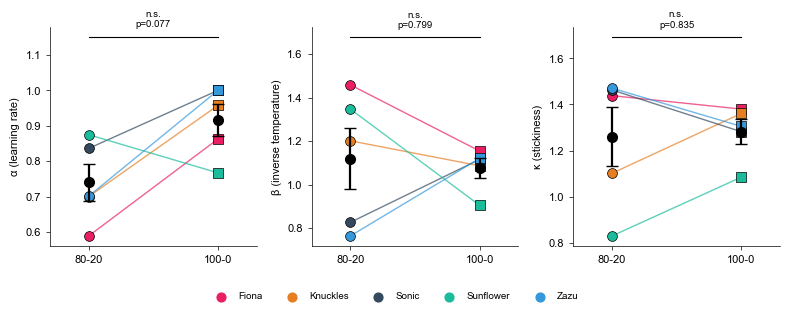


Parameter comparison (mean ± SEM):
Parameter                   80-20        100-0    p-value
----------------------------------------------------------
α (learning rate)    0.740±0.052  0.917±0.045  p=0.0770
β (inverse temperature) 1.120±0.139  1.076±0.044  p=0.7988
κ (stickiness)       1.261±0.128  1.283±0.053  p=0.8348


In [149]:
print("\n" + "="*70)
print("STEP 7: PARAMETER COMPARISON FIGURE")
print("="*70)

# Align parameters for paired comparison
params_80 = sticky_params_80[
    sticky_params_80['animal'].isin(OVERLAPPING_ANIMALS)
].set_index('animal')
params_100 = sticky_params_100.set_index('animal')

params_80  = params_80.loc[sorted(OVERLAPPING_ANIMALS)]
params_100 = params_100.loc[sorted(OVERLAPPING_ANIMALS)]

params = ['alpha', 'beta', 'kappa']
param_labels = ['α (learning rate)', 'β (inverse temperature)', 'κ (stickiness)']

fig, axes = plt.subplots(1, 3, figsize=(8, 3.0))

for ax, param, label in zip(axes, params, param_labels):
    vals_80  = params_80[param].values
    vals_100 = params_100[param].values

    # Paired lines
    for i, animal in enumerate(sorted(OVERLAPPING_ANIMALS)):
        ax.plot([0, 1], [vals_80[i], vals_100[i]],
                color=ANIMAL_COLORS[animal], linewidth=1.0,
                alpha=0.7, zorder=2)
        ax.scatter([0], [vals_80[i]],
                   color=ANIMAL_COLORS[animal], s=50,
                   edgecolor='black', linewidth=0.5,
                   zorder=3)
        ax.scatter([1], [vals_100[i]],
                   color=ANIMAL_COLORS[animal], s=50,
                   marker='s', edgecolor='black', linewidth=0.5,
                   zorder=3)

    # Mean ± SEM
    for x, vals in [(0, vals_80), (1, vals_100)]:
        mean = vals.mean()
        se   = sem(vals)
        ax.errorbar(x, mean, yerr=se, fmt='o',
                    color='black', markersize=7,
                    capsize=4, linewidth=LINE_WIDTH * 2,
                    markeredgecolor='black', zorder=5)

    # Stats
    t, p = ttest_rel(vals_80, vals_100)
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'n.s.'
    ymax = max(max(vals_80), max(vals_100)) * 1.15
    ax.plot([0, 1], [ymax, ymax], color='black', linewidth=0.8)
    ax.text(0.5, ymax * 1.02, f'{sig}\np={p:.3f}',
            ha='center', va='bottom', fontsize=FONTSIZE-1)

    ax.set_xticks([0, 1])
    ax.set_xticklabels(['80-20', '100-0'], fontsize=FONTSIZE)
    ax.set_ylabel(label, fontsize=FONTSIZE)
    ax.set_xlim(-0.3, 1.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(labelsize=FONTSIZE, length=TICK_LENGTH)

# Animal legend
legend_elements = [
    plt.scatter([], [], color=ANIMAL_COLORS[a], s=40, label=a)
    for a in sorted(OVERLAPPING_ANIMALS)
]
fig.legend(handles=legend_elements, loc='lower center', ncol=5,
           frameon=False, fontsize=FONTSIZE-1,
           bbox_to_anchor=(0.5, -0.05))

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig(os.path.join(FIGURE_PATH, 'Parameter_Comparison_80_100.svg'),
            dpi=300, bbox_inches='tight')
print("✓ Saved Parameter_Comparison_80_100.svg")
plt.show()

# Print comparison table
print("\nParameter comparison (mean ± SEM):")
print(f"{'Parameter':<20} {'80-20':>12} {'100-0':>12} {'p-value':>10}")
print("-" * 58)
for param, label in zip(params, param_labels):
    v80  = params_80[param].values
    v100 = params_100[param].values
    t, p = ttest_rel(v80, v100)
    print(f"{label:<20} {v80.mean():.3f}±{sem(v80):.3f}  "
          f"{v100.mean():.3f}±{sem(v100):.3f}  p={p:.4f}")

In [15]:
# # plot the choice binary and the outcome binary for each session by using the color to fill in the outcome binary
# for session in df_100_corrected['Session_ID'].unique():
#     session_data = df_100_corrected[df_100_corrected['Session_ID'] == session]
#     plt.figure(figsize=(6, 2))
#     plt.scatter(session_data['Trial'], session_data['Choice_Binary'])
#     plt.scatter(session_data['Trial'], session_data['BlockCount'])
#     plt.show()

In [150]:
ROLLING_WINDOW = 5  # confirm this matches your 80-20 notebook

df_100_corrected = df_100_corrected.sort_values(
    ['Animal_Name', 'New_Pseudo_Session_ID', 'Trial']
).copy()

df_100_corrected['PhysicalSwitch'] = (
    df_100_corrected.groupby('New_Pseudo_Session_ID')['Choice_Binary']
    .transform(lambda x: (x != x.shift(1)).astype(float))
)
df_100_corrected['Rolling_Accuracy'] = (
    df_100_corrected.groupby('New_Pseudo_Session_ID')['High_Prob']
    .transform(lambda x: x.rolling(ROLLING_WINDOW, min_periods=3).mean())
)
df_100_corrected['Rolling_PRight'] = (
    df_100_corrected.groupby('New_Pseudo_Session_ID')['Choice_Binary']
    .transform(lambda x: x.rolling(ROLLING_WINDOW, min_periods=3).mean())
)
df_100_corrected['Rolling_Switch_Rate'] = (
    df_100_corrected.groupby('New_Pseudo_Session_ID')['PhysicalSwitch']
    .transform(lambda x: x.rolling(ROLLING_WINDOW, min_periods=3).mean())
)

# Verify
print(df_100_corrected[['Rolling_Accuracy', 'Rolling_PRight', 
                          'Rolling_Switch_Rate']].describe().round(3))

       Rolling_Accuracy  Rolling_PRight  Rolling_Switch_Rate
count         12775.000       12477.000            12775.000
mean              0.745           0.478                0.192
std               0.285           0.394                0.233
min               0.000           0.000                0.000
25%               0.600           0.000                0.000
50%               0.800           0.400                0.200
75%               1.000           0.800                0.250
max               1.000           1.000                1.000


In [151]:
df_100_corrected.Behavioral_State_Full.value_counts()

AttributeError: 'DataFrame' object has no attribute 'Behavioral_State_Full'

In [152]:
ws_ls_condition_records = []

for condition in ['80-20', '100-0']:
    cdf = df_80_pseudo[df_80_pseudo['Condition'] == condition].copy()
    
    for state in STATES_ORDERED_FULL:
        sdf = cdf[cdf['Behavioral_State_Full'] == state].copy()
        
        if len(sdf) < 30:
            continue
        
        sdf = sdf.sort_values(['Animal_Name', 'Session_ID', 'Trial'])
        sdf['Prev_Outcome'] = sdf.groupby(
            ['Animal_Name', 'Session_ID'])['Outcome_Binary'].shift(1)
        
        win_trials = sdf[sdf['Prev_Outcome'] == 1].dropna(subset=['PhysicalSwitch'])
        lose_trials = sdf[sdf['Prev_Outcome'] == 0].dropna(subset=['PhysicalSwitch'])
        
        if len(win_trials) < 10 or len(lose_trials) < 10:
            continue
        
        ws_animal = (win_trials.groupby('Animal_Name')
                     .apply(lambda x: 1 - x['PhysicalSwitch'].mean(),
                            include_groups=False)
                     .reset_index(name='win_stay'))
        ls_animal = (lose_trials.groupby('Animal_Name')
                     .apply(lambda x: x['PhysicalSwitch'].mean(),
                            include_groups=False)
                     .reset_index(name='lose_switch'))
        
        ws_ls_condition_records.append({
            'condition':   condition,
            'state':       state,
            'win_stay':    ws_animal['win_stay'].mean(),
            'lose_switch': ls_animal['lose_switch'].mean(),
            'ws_sem':      ws_animal['win_stay'].sem(),
            'ls_sem':      ls_animal['lose_switch'].sem(),
        })

ws_ls_condition_df = pd.DataFrame(ws_ls_condition_records)
print(ws_ls_condition_df[['condition', 'state', 'win_stay', 'ws_sem', 
                           'lose_switch', 'ls_sem']].to_string(index=False))

KeyError: "None of [Index(['condition', 'state', 'win_stay', 'ws_sem', 'lose_switch', 'ls_sem'], dtype='object')] are in the [columns]"

✓ Saved ModelFree_Comparison.svg


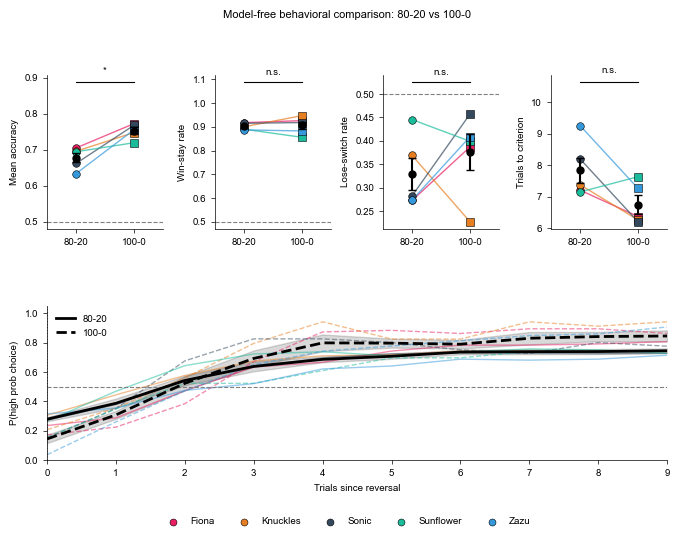

In [153]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import ttest_rel, sem

ROLLING_WINDOW = 5
WINDOW     = 10  # trials post-reversal
FONTSIZE   = 7
LINE_WIDTH = 1.0
TICK_LENGTH = 3

# ── 1. Win-stay / Lose-switch ────────────────────────────────────────────────
def compute_wslr(df, session_col, animal_col='Animal_Name'):
    records = []
    for (animal, session), sdf in df.groupby([animal_col, session_col]):
        sdf = sdf.sort_values('Trial').copy()
        choice  = sdf['Choice_Binary'].values
        outcome = sdf['Outcome_Binary'].values
        valid   = ~(np.isnan(choice) | np.isnan(outcome))
        choice, outcome = choice[valid].astype(int), outcome[valid].astype(int)
        if len(choice) < 4:
            continue
        stay = (choice[1:] == choice[:-1])
        win  = outcome[:-1] == 1
        lose = outcome[:-1] == 0
        ws = stay[win].mean()   if win.sum()  > 0 else np.nan
        lr = (~stay[lose]).mean() if lose.sum() > 0 else np.nan
        # add switch rate 
        switch_rate = sdf['PhysicalSwitch'].mean()
        records.append(dict(Animal_Name=animal, WinStay=ws, LoseSwitch=lr, SwitchRate=switch_rate))
    return (pd.DataFrame(records)
            .groupby('Animal_Name')[['WinStay', 'LoseSwitch', 'SwitchRate']]
            .mean())

wslr_80  = compute_wslr(df_80_pseudo,     session_col='Session_ID')
wslr_100 = compute_wslr(df_100_corrected, session_col='New_Pseudo_Session_ID')

# ── 2. Overall accuracy ──────────────────────────────────────────────────────
acc_80 = (df_80_pseudo[df_80_pseudo['Animal_Name'].isin(OVERLAPPING_ANIMALS)]
          .groupby('Animal_Name')['High_Prob'].mean())
acc_100 = (df_100_corrected[df_100_corrected['Animal_Name'].isin(OVERLAPPING_ANIMALS)]
           .groupby('Animal_Name')['High_Prob'].mean())

# ── 3. Post-reversal accuracy curve ─────────────────────────────────────────
def reversal_curve(df, session_col, window=WINDOW):
    curves = {a: [] for a in OVERLAPPING_ANIMALS}
    for (animal, session), sdf in df.groupby(['Animal_Name', session_col]):
        if animal not in OVERLAPPING_ANIMALS:
            continue
        sdf = sdf.sort_values('Trial').reset_index(drop=True)
        rev_idx = sdf.index[sdf['Block_Transition'] == 1].tolist()
        for idx in rev_idx:
            seg = sdf.loc[idx:idx+window-1, 'High_Prob'].values
            if len(seg) == window and not np.isnan(seg).any():
                curves[animal].append(seg)
    return {a: np.mean(v, axis=0) for a, v in curves.items() if len(v) > 0}

curve_80  = reversal_curve(df_80_pseudo,     session_col='Session_ID')
curve_100 = reversal_curve(df_100_corrected, session_col='New_Pseudo_Session_ID')

# ── 4. Trials to criterion ───────────────────────────────────────────────────
def trials_to_criterion(df, session_col, threshold=0.8, window=5):
    records = []
    for (animal, session), sdf in df.groupby(['Animal_Name', session_col]):
        if animal not in OVERLAPPING_ANIMALS:
            continue
        sdf = sdf.sort_values('Trial').reset_index(drop=True)
        rev_idx = sdf.index[sdf['Block_Transition'] == 1].tolist()
        for idx in rev_idx:
            post = sdf.loc[idx:, 'High_Prob'].values
            if len(post) < window:
                continue
            roll = pd.Series(post).rolling(window, min_periods=window).mean().values
            hit  = np.where(roll >= threshold)[0]
            ttc  = hit[0] if len(hit) > 0 else np.nan
            records.append(dict(Animal_Name=animal, TTC=ttc))
    return (pd.DataFrame(records)
            .groupby('Animal_Name')['TTC']
            .mean())

ttc_80  = trials_to_criterion(df_80_pseudo,     session_col='Session_ID')
ttc_100 = trials_to_criterion(df_100_corrected, session_col='New_Pseudo_Session_ID')

# ── figure ───────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(8, 5))
gs  = gridspec.GridSpec(2, 4, figure=fig, hspace=0.5, wspace=0.45)

ax_acc  = fig.add_subplot(gs[0, 0])
ax_ws   = fig.add_subplot(gs[0, 1])
ax_lr   = fig.add_subplot(gs[0, 2])
ax_ttc  = fig.add_subplot(gs[0, 3])
ax_curv = fig.add_subplot(gs[1, :])

def paired_ax(ax, vals_80, vals_100, ylabel, chance=None, higher_is_better=True):
    animals = sorted(OVERLAPPING_ANIMALS)
    v80  = np.array([vals_80.loc[a]  if a in vals_80.index  else np.nan for a in animals])
    v100 = np.array([vals_100.loc[a] if a in vals_100.index else np.nan for a in animals])
    mask = ~(np.isnan(v80) | np.isnan(v100))

    for a, y0, y1 in zip(np.array(animals)[mask], v80[mask], v100[mask]):
        ax.plot([0, 1], [y0, y1], color=ANIMAL_COLORS[a],
                lw=LINE_WIDTH, alpha=0.7, zorder=2)
        ax.scatter([0], [y0], color=ANIMAL_COLORS[a], s=30,
                   edgecolor='black', linewidth=0.4, zorder=3)
        ax.scatter([1], [y1], color=ANIMAL_COLORS[a], s=30,
                   marker='s', edgecolor='black', linewidth=0.4, zorder=3)

    for x, vals in [(0, v80[mask]), (1, v100[mask])]:
        ax.errorbar(x, vals.mean(), yerr=sem(vals), fmt='o',
                    color='black', markersize=5, capsize=3,
                    linewidth=LINE_WIDTH*1.5, zorder=5)

    if mask.sum() >= 2:
        _, p = ttest_rel(v80[mask], v100[mask])
        sig  = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'n.s.'
        ymax = np.nanmax([v80, v100]) * 1.15
        ax.plot([0, 1], [ymax, ymax], color='black', lw=0.8)
        ax.text(0.5, ymax*1.02, sig, ha='center', va='bottom', fontsize=FONTSIZE)

    if chance is not None:
        ax.axhline(chance, color='gray', lw=0.8, ls='--', zorder=1)

    ax.set_xticks([0, 1])
    ax.set_xticklabels(['80-20', '100-0'], fontsize=FONTSIZE)
    ax.set_ylabel(ylabel, fontsize=FONTSIZE)
    ax.set_xlim(-0.5, 1.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(labelsize=FONTSIZE, length=TICK_LENGTH)

paired_ax(ax_acc, acc_80,               acc_100,               'Mean accuracy',    chance=0.5)
paired_ax(ax_ws,  wslr_80['WinStay'],   wslr_100['WinStay'],   'Win-stay rate',    chance=0.5)
paired_ax(ax_lr,  wslr_80['LoseSwitch'],wslr_100['LoseSwitch'],'Lose-switch rate', chance=0.5)
paired_ax(ax_ttc, ttc_80,               ttc_100,               'Trials to criterion')

# ── post-reversal curve ──────────────────────────────────────────────────────
x = np.arange(WINDOW)
all_80  = np.array([curve_80[a]  for a in OVERLAPPING_ANIMALS if a in curve_80])
all_100 = np.array([curve_100[a] for a in OVERLAPPING_ANIMALS if a in curve_100])

for a in OVERLAPPING_ANIMALS:
    if a in curve_80:
        ax_curv.plot(x, curve_80[a],  color=ANIMAL_COLORS[a],
                     lw=LINE_WIDTH, alpha=0.5, ls='-')
    if a in curve_100:
        ax_curv.plot(x, curve_100[a], color=ANIMAL_COLORS[a],
                     lw=LINE_WIDTH, alpha=0.5, ls='--')

if len(all_80) > 0:
    ax_curv.plot(x, all_80.mean(axis=0), color='black', lw=2.0,
                 ls='-', label='80-20', zorder=5)
    ax_curv.fill_between(x,
        all_80.mean(axis=0) - sem(all_80, axis=0),
        all_80.mean(axis=0) + sem(all_80, axis=0),
        color='black', alpha=0.15)
if len(all_100) > 0:
    ax_curv.plot(x, all_100.mean(axis=0), color='black', lw=2.0,
                 ls='--', label='100-0', zorder=5)
    ax_curv.fill_between(x,
        all_100.mean(axis=0) - sem(all_100, axis=0),
        all_100.mean(axis=0) + sem(all_100, axis=0),
        color='black', alpha=0.15)

ax_curv.axhline(0.5, color='gray', lw=0.8, ls='--')
ax_curv.axvline(0,   color='gray', lw=0.8, ls=':')
ax_curv.set_xlabel('Trials since reversal', fontsize=FONTSIZE)
ax_curv.set_ylabel('P(high prob choice)', fontsize=FONTSIZE)
ax_curv.set_xlim(0, WINDOW-1)
ax_curv.set_ylim(0, 1.05)
ax_curv.legend(frameon=False, fontsize=FONTSIZE)
ax_curv.spines['top'].set_visible(False)
ax_curv.spines['right'].set_visible(False)
ax_curv.tick_params(labelsize=FONTSIZE, length=TICK_LENGTH)

# ── legend ───────────────────────────────────────────────────────────────────
handles = [plt.scatter([], [], color=ANIMAL_COLORS[a], s=25,
                       edgecolor='black', linewidth=0.4, label=a)
           for a in OVERLAPPING_ANIMALS]
fig.legend(handles=handles, loc='lower center', ncol=5,
           frameon=False, fontsize=FONTSIZE,
           bbox_to_anchor=(0.5, -0.04))

plt.suptitle('Model-free behavioral comparison: 80-20 vs 100-0',
             fontsize=FONTSIZE+1, y=1.01)

plt.savefig('ModelFree_Comparison.svg', dpi=300, bbox_inches='tight')
print("✓ Saved ModelFree_Comparison.svg")
plt.show()

✓ Saved ModelFree_Comparison.svg


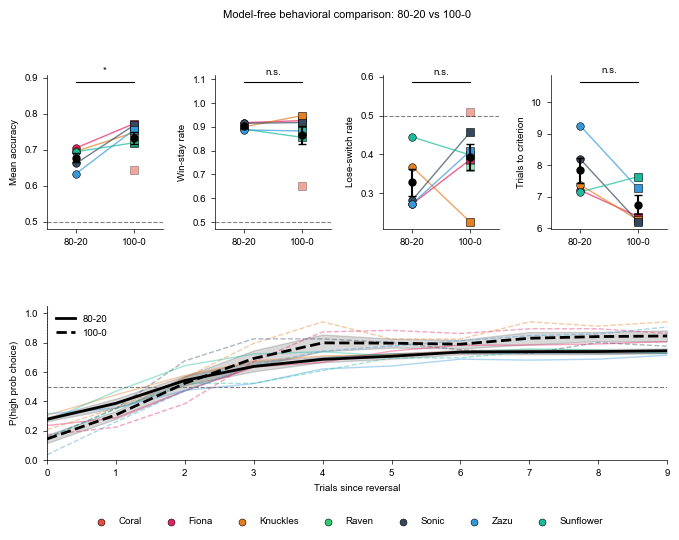

In [154]:
ANIMALS_80  = sorted(df_80_pseudo['Animal_Name'].unique())
ANIMALS_100 = sorted(df_100_corrected['Animal_Name'].unique())
UNPAIRED_100 = [a for a in ANIMALS_100 if a not in ANIMALS_80]  # Coral, Raven

# ── recompute metrics for all animals ────────────────────────────────────────
acc_80 = (df_80_pseudo
          .groupby('Animal_Name')['High_Prob'].mean())
acc_100 = (df_100_corrected
           .groupby('Animal_Name')['High_Prob'].mean())

wslr_80  = compute_wslr(df_80_pseudo,     session_col='Session_ID')
wslr_100 = compute_wslr(df_100_corrected, session_col='New_Pseudo_Session_ID')

ttc_80  = trials_to_criterion(df_80_pseudo,     session_col='Session_ID')
ttc_100 = trials_to_criterion(df_100_corrected, session_col='New_Pseudo_Session_ID')

curve_80  = reversal_curve(df_80_pseudo,     session_col='Session_ID')
curve_100 = reversal_curve(df_100_corrected, session_col='New_Pseudo_Session_ID')

# ── updated paired_ax ────────────────────────────────────────────────────────
def paired_ax(ax, vals_80, vals_100, ylabel, chance=None):
    # Draw paired lines for overlapping animals
    for a in OVERLAPPING_ANIMALS:
        if a not in vals_80.index or a not in vals_100.index:
            continue
        y0, y1 = vals_80.loc[a], vals_100.loc[a]
        ax.plot([0, 1], [y0, y1], color=ANIMAL_COLORS[a],
                lw=LINE_WIDTH, alpha=0.7, zorder=2)
        ax.scatter([0], [y0], color=ANIMAL_COLORS[a], s=30,
                   edgecolor='black', linewidth=0.4, zorder=3)
        ax.scatter([1], [y1], color=ANIMAL_COLORS[a], s=30,
                   marker='s', edgecolor='black', linewidth=0.4, zorder=3)

    # Unpaired 100-0 animals
    for a in UNPAIRED_100:
        if a not in vals_100.index:
            continue
        ax.scatter([1], [vals_100.loc[a]], color=ANIMAL_COLORS[a], s=30,
                   edgecolor='black', linewidth=0.4, zorder=3,
                   marker='s', alpha=0.5)

    # Mean ± SEM for each condition separately
    v80  = np.array([vals_80.loc[a]  for a in OVERLAPPING_ANIMALS
                     if a in vals_80.index])
    v100_paired = np.array([vals_100.loc[a] for a in OVERLAPPING_ANIMALS
                            if a in vals_100.index])
    v100_all    = np.array([vals_100.loc[a] for a in ANIMALS_100
                            if a in vals_100.index])

    for x, vals in [(0, v80), (1, v100_all)]:
        if len(vals) > 0:
            ax.errorbar(x, vals.mean(), yerr=sem(vals), fmt='o',
                        color='black', markersize=5, capsize=3,
                        linewidth=LINE_WIDTH*1.5, zorder=5)

    # Stats on paired animals only
    mask = np.array([a in vals_80.index and a in vals_100.index
                     for a in OVERLAPPING_ANIMALS])
    if mask.sum() >= 2:
        _, p = ttest_rel(v80, v100_paired)
        sig  = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'n.s.'
        ymax = max(np.nanmax(v80), np.nanmax(v100_all)) * 1.15
        ax.plot([0, 1], [ymax, ymax], color='black', lw=0.8)
        ax.text(0.5, ymax*1.02, sig, ha='center', va='bottom', fontsize=FONTSIZE)

    if chance is not None:
        ax.axhline(chance, color='gray', lw=0.8, ls='--', zorder=1)

    ax.set_xticks([0, 1])
    ax.set_xticklabels(['80-20', '100-0'], fontsize=FONTSIZE)
    ax.set_ylabel(ylabel, fontsize=FONTSIZE)
    ax.set_xlim(-0.5, 1.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(labelsize=FONTSIZE, length=TICK_LENGTH)

# ── figure ───────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(8, 5))
gs  = gridspec.GridSpec(2, 4, figure=fig, hspace=0.5, wspace=0.45)

ax_acc  = fig.add_subplot(gs[0, 0])
ax_ws   = fig.add_subplot(gs[0, 1])
ax_lr   = fig.add_subplot(gs[0, 2])
ax_ttc  = fig.add_subplot(gs[0, 3])
ax_curv = fig.add_subplot(gs[1, :])

paired_ax(ax_acc, acc_80,                acc_100,                'Mean accuracy',    chance=0.5)
paired_ax(ax_ws,  wslr_80['WinStay'],    wslr_100['WinStay'],    'Win-stay rate',    chance=0.5)
paired_ax(ax_lr,  wslr_80['LoseSwitch'], wslr_100['LoseSwitch'], 'Lose-switch rate', chance=0.5)
paired_ax(ax_ttc, ttc_80,                ttc_100,                'Trials to criterion')

# ── post-reversal curve — all animals ────────────────────────────────────────
x = np.arange(WINDOW)

# Individual animal traces
for a in ANIMALS_80:
    if a in curve_80:
        ax_curv.plot(x, curve_80[a], color=ANIMAL_COLORS[a],
                     lw=LINE_WIDTH, alpha=0.4, ls='-')
for a in ANIMALS_100:
    if a in curve_100:
        alpha = 0.4 if a in OVERLAPPING_ANIMALS else 0.25
        ax_curv.plot(x, curve_100[a], color=ANIMAL_COLORS[a],
                     lw=LINE_WIDTH, alpha=alpha, ls='--')

# Group means
all_80  = np.array([curve_80[a]  for a in ANIMALS_80  if a in curve_80])
all_100 = np.array([curve_100[a] for a in ANIMALS_100 if a in curve_100])

if len(all_80) > 0:
    ax_curv.plot(x, all_80.mean(axis=0), color='black', lw=2.0,
                 ls='-', label='80-20', zorder=5)
    ax_curv.fill_between(x,
        all_80.mean(axis=0) - sem(all_80, axis=0),
        all_80.mean(axis=0) + sem(all_80, axis=0),
        color='black', alpha=0.15)
if len(all_100) > 0:
    ax_curv.plot(x, all_100.mean(axis=0), color='black', lw=2.0,
                 ls='--', label='100-0', zorder=5)
    ax_curv.fill_between(x,
        all_100.mean(axis=0) - sem(all_100, axis=0),
        all_100.mean(axis=0) + sem(all_100, axis=0),
        color='black', alpha=0.15)

ax_curv.axhline(0.5, color='gray', lw=0.8, ls='--')
ax_curv.axvline(0,   color='gray', lw=0.8, ls=':')
ax_curv.set_xlabel('Trials since reversal', fontsize=FONTSIZE)
ax_curv.set_ylabel('P(high prob choice)', fontsize=FONTSIZE)
ax_curv.set_xlim(0, WINDOW-1)
ax_curv.set_ylim(0, 1.05)
ax_curv.legend(frameon=False, fontsize=FONTSIZE)
ax_curv.spines['top'].set_visible(False)
ax_curv.spines['right'].set_visible(False)
ax_curv.tick_params(labelsize=FONTSIZE, length=TICK_LENGTH)

# ── legend ───────────────────────────────────────────────────────────────────
handles = [plt.scatter([], [], color=ANIMAL_COLORS[a], s=25,
                       edgecolor='black', linewidth=0.4, label=a)
           for a in ANIMAL_ORDER if a in ANIMALS_80 + ANIMALS_100]
fig.legend(handles=handles, loc='lower center', ncol=7,
           frameon=False, fontsize=FONTSIZE,
           bbox_to_anchor=(0.5, -0.04))

plt.suptitle('Model-free behavioral comparison: 80-20 vs 100-0',
             fontsize=FONTSIZE+1, y=1.01)

plt.savefig('ModelFree_Comparison.svg', dpi=300, bbox_inches='tight')
print("✓ Saved ModelFree_Comparison.svg")
plt.show()

In [155]:
# For 100-0, use Original_Session_ID for no-cued sessions,
# New_Pseudo_Session_ID for cued sessions
df_100_corrected['Fit_Session_ID'] = np.where(
    df_100_corrected['Has_Cued_Transitions'] == False,
    df_100_corrected['Original_Session_ID'],
    df_100_corrected['New_Pseudo_Session_ID']
)

print(df_100_corrected['Fit_Session_ID'].nunique(), 'fit sessions')
print(df_100_corrected.groupby('Fit_Session_ID').size().describe())
print(df_100_corrected.groupby('Has_Cued_Transitions')['Fit_Session_ID'].nunique())

194 fit sessions
count    194.000000
mean      67.850515
std       70.552397
min       12.000000
25%       32.500000
50%       60.000000
75%       80.000000
max      425.000000
dtype: float64
Has_Cued_Transitions
False     17
True     177
Name: Fit_Session_ID, dtype: int64


In [156]:
def fit_rl_model_session(df, session_col='Session_ID', min_trials=30, n_starts=5):
    bounds  = [(1e-4, 1-1e-4), (1e-3, 50.0), (-10.0, 10.0)]
    records = []

    for session, sdf in df.groupby(session_col):
        sdf     = sdf.sort_values('Trial').copy()
        choices = sdf['Choice_Binary'].dropna().values.astype(int)
        rewards = sdf['Outcome_Binary'].dropna().values.astype(int)

        if len(choices) < min_trials:
            continue

        best_res = None
        for seed in range(n_starts):
            rng = np.random.default_rng(seed)
            x0  = np.array([
                rng.uniform(0.1, 0.9),
                rng.uniform(0.5, 5.0),
                rng.uniform(-2.0, 2.0),
            ])
            res = minimize(
                qlearn_sticky_nll,
                x0=x0,
                args=(choices, rewards),
                method='L-BFGS-B',
                bounds=bounds
            )
            if best_res is None or res.fun < best_res.fun:
                best_res = res

        records.append(dict(
            Session_ID     = session,
            Animal_Name    = sdf['Animal_Name'].iloc[0],
            alpha          = best_res.x[0],
            beta           = best_res.x[1],
            kappa          = best_res.x[2],
            nll            = best_res.fun,
            n_trials       = len(choices),
            beta_at_bound  = best_res.x[1] >= 49.9,
            kappa_at_bound = abs(best_res.x[2]) >= 9.9,
            alpha_at_bound = best_res.x[0] <= 0.001 or best_res.x[0] >= 0.999,
        ))

    return pd.DataFrame(records)


print("Fitting session-level model to 100-0 (corrected)...")
params_100_corrected = fit_rl_model_session(
    df_100_corrected,
    session_col='Fit_Session_ID',
    min_trials=30
)
print(f"  {len(params_100_corrected)} sessions fitted")

any_bound = params_100_corrected[['beta_at_bound','kappa_at_bound','alpha_at_bound']].any(axis=1)
print(f"  Boundary solutions: {any_bound.sum()} ({any_bound.mean()*100:.1f}%)")
print(f"  Chance-level (nll<0.70): {(params_100_corrected['nll']<0.70).sum()}")

# Parameter summary by group
params_100_corrected['group'] = 'non_boundary'
params_100_corrected.loc[any_bound & (params_100_corrected['nll'] >= 0.70), 'group'] = 'fast_learner'
params_100_corrected.loc[any_bound & (params_100_corrected['nll'] < 0.70), 'group'] = 'non_learner'

print(params_100_corrected.groupby('group')[['n_trials','alpha','beta','kappa']].mean().round(3))
print(params_100_corrected['group'].value_counts())

Fitting session-level model to 100-0 (corrected)...
  146 sessions fitted
  Boundary solutions: 75 (51.4%)
  Chance-level (nll<0.70): 0
              n_trials  alpha    beta  kappa
group                                       
fast_learner    76.347  0.646  11.168  2.702
non_boundary    91.338  0.691   1.388  1.122
fast_learner    75
non_boundary    71
Name: group, dtype: int64


In [40]:
# Get non-boundary session IDs
non_boundary_sessions_80 = params_80_sess[
    params_80_sess['group'] == 'non_boundary'
]['Session_ID'].values

print(f"Total sessions: {len(params_80_sess)}")
print(f"Non-boundary sessions: {len(non_boundary_sessions_80)}")

# Filter trial-level data
df_non_boundary_80 = df_80_pseudo[
    df_80_pseudo['Session_ID'].isin(non_boundary_sessions_80)
].copy()

# Recompute Q-value alignment by state
def compute_q_alignment(sdf):
    valid = sdf[sdf['Q_diff'].abs() > 0]
    if len(valid) == 0:
        return np.nan
    chose_higher = (
        ((valid['Choice_Binary'] == 1) & (valid['Q_diff'] > 0)) |
        ((valid['Choice_Binary'] == 0) & (valid['Q_diff'] < 0))
    )
    return chose_higher.mean()

print(f"Total trials in full dataset: {len(df_80_pseudo)}")
print(f"Total trials in non-boundary dataset: {len(df_non_boundary_80)}")

print("\nViolation rate by state:")
print(f"{'State':<25} {'Full':>8} {'Non-boundary':>15}")
print("-" * 50)
for state in STATES_ORDERED_FULL:
    full_sdf = df_80_pseudo[
        (df_80_pseudo['Behavioral_State_Full'] == state) &
        (df_80_pseudo['Q_diff'].abs() > 0)
    ]
    nb_sdf = df_non_boundary_80[
        (df_non_boundary_80['Behavioral_State_Full'] == state) &
        (df_non_boundary_80['Q_diff'].abs() > 0)
    ]
    full_viol = (full_sdf['Chose_Higher_Q'] == 0).mean()
    nb_viol = (nb_sdf['Chose_Higher_Q'] == 0).mean()
    print(f"{state:<25} {full_viol:>8.3f} {nb_viol:>15.3f}")
# Compare Q-value alignment by state
print("\nQ-value alignment by state:")
print(f"{'State':<25} {'Full':>8} {'Non-boundary':>15}")
print("-" * 50)
for state in STATES_ORDERED_FULL:
    full = compute_q_alignment(
        df_80_pseudo[df_80_pseudo['Behavioral_State_Full'] == state]
    )
    nb = compute_q_alignment(
        df_non_boundary_80[df_non_boundary_80['Behavioral_State_Full'] == state]
    )
    print(f"{state:<25} {full:>8.3f} {nb:>15.3f}")

Total sessions: 100
Non-boundary sessions: 79
Total trials in full dataset: 36673
Total trials in non-boundary dataset: 29214

Violation rate by state:
State                         Full    Non-boundary
--------------------------------------------------
Engaged                      0.133           0.119
Adapting (fast)              0.350           0.339
Adapting (slow)              0.296           0.279
Directed Exploration         0.336           0.332
Random Exploration           0.494           0.484
Left Bias                    0.653           0.651
Right Bias                   0.640           0.605

Q-value alignment by state:
State                         Full    Non-boundary
--------------------------------------------------
Engaged                      0.867           0.881
Adapting (fast)              0.650           0.661
Adapting (slow)              0.704           0.721
Directed Exploration         0.664           0.668
Random Exploration           0.506           0.516
Lef

In [24]:
print("Fitting session-level model to 80-20...")
params_80_sess = fit_rl_model_session(
    df_80_pseudo,
    session_col='Session_ID',
    min_trials=30
)
print(f"  {len(params_80_sess)} sessions fitted")

any_bound_80 = params_80_sess[['beta_at_bound','kappa_at_bound','alpha_at_bound']].any(axis=1)
print(f"  Boundary solutions: {any_bound_80.sum()} ({any_bound_80.mean()*100:.1f}%)")
print(f"  Chance-level (nll<0.70): {(params_80_sess['nll']<0.70).sum()}")

params_80_sess['group'] = 'non_boundary'
params_80_sess.loc[any_bound_80 & (params_80_sess['nll'] >= 0.70), 'group'] = 'fast_learner'
params_80_sess.loc[any_bound_80 & (params_80_sess['nll'] < 0.70), 'group'] = 'non_learner'

print(params_80_sess.groupby('group')[['n_trials','alpha','beta','kappa']].mean().round(3))
print(params_80_sess['group'].value_counts())

Fitting session-level model to 80-20...
  100 sessions fitted
  Boundary solutions: 21 (21.0%)
  Chance-level (nll<0.70): 0
              n_trials  alpha    beta  kappa
group                                       
fast_learner   355.190  0.667  10.302  1.164
non_boundary   369.797  0.699   1.738  1.089
non_boundary    79
fast_learner    21
Name: group, dtype: int64


In [29]:
# print all 100 rows of params_80_sess
# need to change options
pd.set_option('display.max_rows', None)
print(params_80_sess.head(100))

                                           Session_ID Animal_Name     alpha  \
0               2022-04-25_20220425_Fiona_Reversal3.1       Fiona  0.595789   
1               2022-04-26_20220426_Fiona_Reversal3.1       Fiona  0.588661   
2               2022-05-02_20220502_Fiona_Reversal3.1       Fiona  0.715109   
3            2022-05-03_20220503_Fiona_Reversal3.1(1)       Fiona  0.880842   
4               2022-05-04_20220504_Fiona_Reversal3.1       Fiona  0.811076   
5               2022-05-05_20220505_Fiona_Reversal3.1       Fiona  0.480955   
6               2022-05-06_20220506_Fiona_Reversal3.1       Fiona  0.472246   
7               2022-05-09_20220509_Fiona_Reversal3.1       Fiona  0.564877   
8               2022-05-10_20220510_Fiona_Reversal3.1       Fiona  0.522415   
9               2022-05-12_20220512_Fiona_Reversal3.1       Fiona  0.475166   
10              2022-05-13_20220513_Fiona_Reversal3.1       Fiona  0.635358   
11              2022-05-16_20220516_Fiona_Reversal3.

In [25]:
# Animal-level aggregation — non-boundary sessions only for clean parameter estimates
def animal_params(params_df, condition_label):
    any_bound = params_df[['beta_at_bound','kappa_at_bound','alpha_at_bound']].any(axis=1)
    non_bound = params_df[~any_bound]
    
    agg = (non_bound
           .groupby('Animal_Name')[['alpha','beta','kappa']]
           .mean()
           .reset_index())
    agg['condition'] = condition_label
    return agg

animal_80  = animal_params(params_80_sess,         '80-20')
animal_100 = animal_params(params_100_corrected,   '100-0')

print("80-20 animal params:")
print(animal_80.to_string(index=False))
print("\n100-0 animal params:")
print(animal_100.to_string(index=False))


from scipy.stats import ttest_rel, wilcoxon

# Merge overlapping animals
merged = animal_80.merge(animal_100, on='Animal_Name', suffixes=('_80','_100'))
merged = merged[merged['Animal_Name'].isin(OVERLAPPING_ANIMALS)]
print(merged[['Animal_Name','alpha_80','alpha_100','beta_80','beta_100','kappa_80','kappa_100']].to_string(index=False))

# Stats
for param in ['alpha','beta','kappa']:
    v80  = merged[f'{param}_80'].values
    v100 = merged[f'{param}_100'].values
    t, p = ttest_rel(v80, v100)
    print(f"{param}: mean 80-20={v80.mean():.3f}, 100-0={v100.mean():.3f}, t={t:.3f}, p={p:.3f}")

80-20 animal params:
Animal_Name    alpha     beta    kappa condition
      Fiona 0.613720 1.478911 1.485812     80-20
   Knuckles 0.676265 1.329684 1.090210     80-20
      Sonic 0.782166 0.994928 1.390450     80-20
  Sunflower 0.726995 1.970166 0.739382     80-20
       Zazu 0.704293 3.219162 1.191810     80-20

100-0 animal params:
Animal_Name    alpha     beta    kappa condition
      Coral 0.613184 1.536132 0.586420     100-0
      Fiona 0.684294 1.339808 1.313579     100-0
   Knuckles 0.697263 1.583087 1.342069     100-0
      Raven 0.599269 1.208255 1.360904     100-0
      Sonic 0.840883 1.476954 1.266875     100-0
  Sunflower 0.686637 1.227475 0.951463     100-0
       Zazu 0.680971 1.470493 0.993151     100-0
Animal_Name  alpha_80  alpha_100  beta_80  beta_100  kappa_80  kappa_100
      Fiona  0.613720   0.684294 1.478911  1.339808  1.485812   1.313579
   Knuckles  0.676265   0.697263 1.329684  1.583087  1.090210   1.342069
      Sonic  0.782166   0.840883 0.994928  1.476954 

✓ Saved ModelFree_Full_Comparison.svg


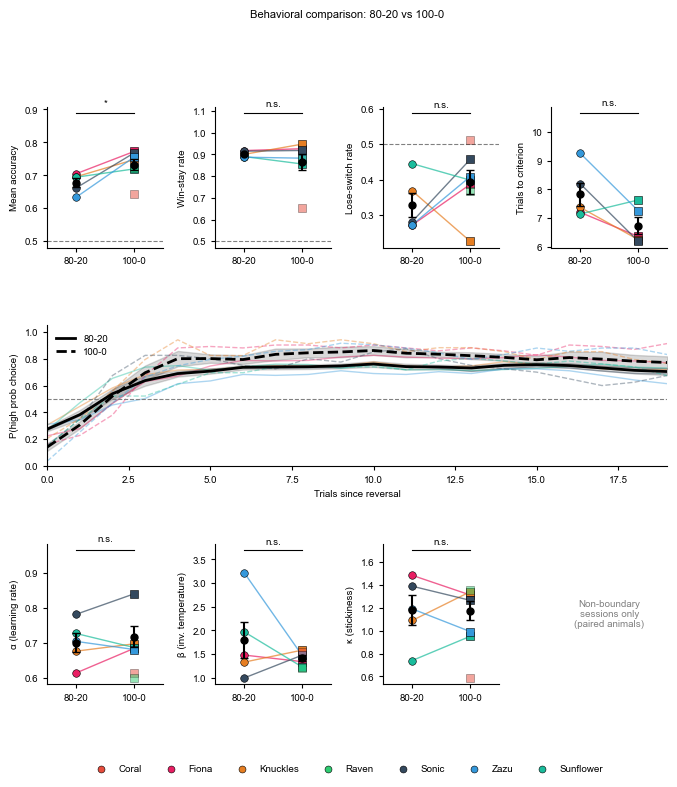

In [99]:
# Rebuild figure with parameter row added
fig = plt.figure(figsize=(8, 7.5))
gs  = gridspec.GridSpec(3, 4, figure=fig, hspace=0.55, wspace=0.45)

ax_acc  = fig.add_subplot(gs[0, 0])
ax_ws   = fig.add_subplot(gs[0, 1])
ax_lr   = fig.add_subplot(gs[0, 2])
ax_ttc  = fig.add_subplot(gs[0, 3])
ax_curv = fig.add_subplot(gs[1, :])
ax_alph = fig.add_subplot(gs[2, 0])
ax_beta = fig.add_subplot(gs[2, 1])
ax_kapp = fig.add_subplot(gs[2, 2])

# ── reuse paired_ax for model-free metrics ───────────────────────────────────
paired_ax(ax_acc, acc_80,                acc_100,                'Mean accuracy',    chance=0.5)
paired_ax(ax_ws,  wslr_80['WinStay'],    wslr_100['WinStay'],    'Win-stay rate',    chance=0.5)
paired_ax(ax_lr,  wslr_80['LoseSwitch'], wslr_100['LoseSwitch'], 'Lose-switch rate', chance=0.5)
paired_ax(ax_ttc, ttc_80,               ttc_100,                 'Trials to criterion')

# ── reversal curve ───────────────────────────────────────────────────────────
x = np.arange(WINDOW)
for a in ANIMALS_80:
    if a in curve_80:
        ax_curv.plot(x, curve_80[a], color=ANIMAL_COLORS[a],
                     lw=LINE_WIDTH, alpha=0.4, ls='-')
for a in ANIMALS_100:
    if a in curve_100:
        alpha = 0.4 if a in OVERLAPPING_ANIMALS else 0.25
        ax_curv.plot(x, curve_100[a], color=ANIMAL_COLORS[a],
                     lw=LINE_WIDTH, alpha=alpha, ls='--')

all_80  = np.array([curve_80[a]  for a in ANIMALS_80  if a in curve_80])
all_100 = np.array([curve_100[a] for a in ANIMALS_100 if a in curve_100])

for arr, ls, label in [(all_80, '-', '80-20'), (all_100, '--', '100-0')]:
    if len(arr) > 0:
        ax_curv.plot(x, arr.mean(axis=0), color='black', lw=2.0,
                     ls=ls, label=label, zorder=5)
        ax_curv.fill_between(x,
            arr.mean(axis=0) - sem(arr, axis=0),
            arr.mean(axis=0) + sem(arr, axis=0),
            color='black', alpha=0.15)

ax_curv.axhline(0.5, color='gray', lw=0.8, ls='--')
ax_curv.axvline(0,   color='gray', lw=0.8, ls=':')
ax_curv.set_xlabel('Trials since reversal', fontsize=FONTSIZE)
ax_curv.set_ylabel('P(high prob choice)', fontsize=FONTSIZE)
ax_curv.set_xlim(0, WINDOW-1)
ax_curv.set_ylim(0, 1.05)
ax_curv.legend(frameon=False, fontsize=FONTSIZE)
ax_curv.spines['top'].set_visible(False)
ax_curv.spines['right'].set_visible(False)
ax_curv.tick_params(labelsize=FONTSIZE, length=TICK_LENGTH)

# ── parameter paired plots ───────────────────────────────────────────────────
def param_paired_ax(ax, param, ylabel):
    v80  = merged[f'{param}_80'].values
    v100 = merged[f'{param}_100'].values
    animals = merged['Animal_Name'].values

    for a, y0, y1 in zip(animals, v80, v100):
        ax.plot([0, 1], [y0, y1], color=ANIMAL_COLORS[a],
                lw=LINE_WIDTH, alpha=0.7, zorder=2)
        ax.scatter([0], [y0], color=ANIMAL_COLORS[a], s=30,
                   edgecolor='black', linewidth=0.4, zorder=3)
        ax.scatter([1], [y1], color=ANIMAL_COLORS[a], s=30,
                   marker='s', edgecolor='black', linewidth=0.4, zorder=3)

    # Unpaired 100-0 animals
    for a in UNPAIRED_100:
        if a in animal_100['Animal_Name'].values:
            val = animal_100.loc[animal_100['Animal_Name']==a, param].values[0]
            ax.scatter([1], [val], color=ANIMAL_COLORS[a], s=30,
                       marker='s', edgecolor='black', linewidth=0.4,
                       alpha=0.5, zorder=3)

    for x, vals in [(0, v80), (1, v100)]:
        ax.errorbar(x, vals.mean(), yerr=sem(vals), fmt='o',
                    color='black', markersize=5, capsize=3,
                    linewidth=LINE_WIDTH*1.5, zorder=5)

    _, p = ttest_rel(v80, v100)
    sig  = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'n.s.'
    ymax = max(v80.max(), v100.max()) * 1.15
    ax.plot([0, 1], [ymax, ymax], color='black', lw=0.8)
    ax.text(0.5, ymax*1.02, sig, ha='center', va='bottom', fontsize=FONTSIZE)

    ax.set_xticks([0, 1])
    ax.set_xticklabels(['80-20', '100-0'], fontsize=FONTSIZE)
    ax.set_ylabel(ylabel, fontsize=FONTSIZE)
    ax.set_xlim(-0.5, 1.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(labelsize=FONTSIZE, length=TICK_LENGTH)

param_paired_ax(ax_alph, 'alpha', 'α (learning rate)')
param_paired_ax(ax_beta, 'beta',  'β (inv. temperature)')
param_paired_ax(ax_kapp, 'kappa', 'κ (stickiness)')

# leave gs[2,3] empty or add a note
ax_note = fig.add_subplot(gs[2, 3])
ax_note.axis('off')
ax_note.text(0.5, 0.5, 'Non-boundary\nsessions only\n(paired animals)',
             ha='center', va='center', fontsize=FONTSIZE,
             color='gray', transform=ax_note.transAxes)

# ── legend ───────────────────────────────────────────────────────────────────
handles = [plt.scatter([], [], color=ANIMAL_COLORS[a], s=25,
                       edgecolor='black', linewidth=0.4, label=a)
           for a in ANIMAL_ORDER if a in ANIMALS_80 + ANIMALS_100]
fig.legend(handles=handles, loc='lower center', ncol=7,
           frameon=False, fontsize=FONTSIZE,
           bbox_to_anchor=(0.5, -0.02))

plt.suptitle('Behavioral comparison: 80-20 vs 100-0',
             fontsize=FONTSIZE+1, y=1.01)

plt.savefig('ModelFree_Full_Comparison.svg', dpi=300, bbox_inches='tight')
print("✓ Saved ModelFree_Full_Comparison.svg")
plt.show()

In [157]:
print("\n" + "="*70)
print("STEP 8: GENERATE Q-VALUES FOR 100-0")
print("="*70)

def compute_qvalues_sticky(df, params_df,
                            session_col='Session_ID',
                            choice_col='Choice_Binary'):
    all_rows = []
    for _, param_row in params_df.iterrows():
        animal = param_row['animal']
        alpha  = param_row['alpha']
        beta   = param_row['beta']
        kappa  = param_row['kappa']

        animal_data = df[df['Animal_Name'] == animal].sort_values(
            [session_col, 'Trial'])

        for session_id, session_data in animal_data.groupby(session_col,
                                                             sort=False):
            session_data = session_data.sort_values('Trial')
            Q = np.array([0.5, 0.5], dtype=float)
            prev_choice = None

            for _, trial in session_data.iterrows():
                c = int(trial[choice_col])
                r = int(trial['Outcome_Binary'])

                stick   = 0.0 if prev_choice is None else (
                    1.0 if prev_choice == 1 else -1.0)
                z       = beta * (Q[1] - Q[0]) + kappa * stick
                p_right = 1.0 / (1.0 + np.exp(-np.clip(z, -50, 50)))

                all_rows.append({
                    'Animal_Name':   animal,
                    session_col:     session_id,
                    'Trial':         trial['Trial'],
                    'Q_left':        Q[0],
                    'Q_right':       Q[1],
                    'Q_diff':        Q[1] - Q[0],
                    'Model_P_Right': p_right,
                })
                Q[c] += alpha * (r - Q[c])
                prev_choice = c

    return pd.DataFrame(all_rows)

qval_100 = compute_qvalues_sticky(
    df_100, sticky_params_100,
    session_col='Pseudo_Session_ID',
    choice_col='Choice_Binary'
)

df_100 = df_100.merge(
    qval_100[['Animal_Name', 'Pseudo_Session_ID', 'Trial',
              'Q_left', 'Q_right', 'Q_diff', 'Model_P_Right']],
    on=['Animal_Name', 'Pseudo_Session_ID', 'Trial'],
    how='left'
)

df_100['Chose_Higher_Q'] = (
    ((df_100['Choice_Binary'] == 1) & (df_100['Q_diff'] > 0)) |
    ((df_100['Choice_Binary'] == 0) & (df_100['Q_diff'] < 0))
).astype(float)

print(f"✓ Q-values generated for 100-0")
print(f"  Mean P(follows Q): {df_100['Chose_Higher_Q'].mean():.3f}")


STEP 8: GENERATE Q-VALUES FOR 100-0
✓ Q-values generated for 100-0
  Mean P(follows Q): 0.757



STEP 9: VIOLATION RATE COMPARISON
✓ Saved Violation_Rate_Comparison.svg

Violation rate: 80-20 = 0.298 ± 0.015
Violation rate: 100-0 = 0.246 ± 0.025
Paired t-test: t=3.920, p=0.0173


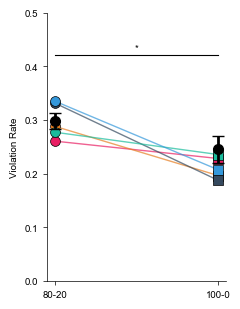

In [158]:
print("\n" + "="*70)
print("STEP 9: VIOLATION RATE COMPARISON")
print("="*70)

# Session-level violation rates
viol_80 = (
    df_80[df_80['Q_diff'] != 0]
    .groupby(['Animal_Name', 'Session_ID'])
    .apply(lambda x: (x['Chose_Higher_Q'] == 0).mean())
    .reset_index()
    .rename(columns={0: 'violation_rate'})
)
viol_80['condition'] = '80-20'

viol_100 = (
    df_100[df_100['Q_diff'] != 0]
    .groupby(['Animal_Name', 'Pseudo_Session_ID'])
    .apply(lambda x: (x['Chose_Higher_Q'] == 0).mean())
    .reset_index()
    .rename(columns={0: 'violation_rate', 'Pseudo_Session_ID': 'Session_ID'})
)
viol_100['condition'] = '100-0'

# Animal-level means for paired test
viol_animal_80  = viol_80.groupby('Animal_Name')['violation_rate'].mean()
viol_animal_100 = viol_100.groupby('Animal_Name')['violation_rate'].mean()

t, p = ttest_rel(
    viol_animal_80.loc[sorted(OVERLAPPING_ANIMALS)],
    viol_animal_100.loc[sorted(OVERLAPPING_ANIMALS)]
)

fig_v, ax_v = plt.subplots(figsize=(2.5, 3.2))

for animal in sorted(OVERLAPPING_ANIMALS):
    v80  = viol_animal_80[animal]
    v100 = viol_animal_100[animal]
    ax_v.plot([0, 1], [v80, v100],
              color=ANIMAL_COLORS[animal], linewidth=1.0,
              alpha=0.7, zorder=2)
    ax_v.scatter([0], [v80], color=ANIMAL_COLORS[animal],
                 s=50, edgecolor='black', linewidth=0.5, zorder=3)
    ax_v.scatter([1], [v100], color=ANIMAL_COLORS[animal],
                 s=50, marker='s', edgecolor='black', linewidth=0.5, zorder=3)

# Grand means
for x, vals in [(0, viol_animal_80), (1, viol_animal_100)]:
    ax_v.errorbar(x, vals.mean(), yerr=sem(vals.values),
                  fmt='o', color='black', markersize=7,
                  capsize=4, linewidth=LINE_WIDTH * 2, zorder=5)

sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'n.s.'
ymax = 0.42
ax_v.plot([0, 1], [ymax, ymax], color='black', linewidth=0.8)
ax_v.text(0.5, ymax + 0.01, f'{sig}', ha='center', fontsize=FONTSIZE)

ax_v.set_xticks([0, 1])
ax_v.set_xticklabels(['80-20', '100-0'], fontsize=FONTSIZE)
ax_v.set_ylabel('Violation Rate', fontsize=FONTSIZE)
ax_v.set_ylim(0, 0.50)
ax_v.spines['top'].set_visible(False)
ax_v.spines['right'].set_visible(False)
ax_v.tick_params(labelsize=FONTSIZE, length=TICK_LENGTH)

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_PATH, 'Violation_Rate_Comparison.svg'),
            dpi=300, bbox_inches='tight')
print(f"✓ Saved Violation_Rate_Comparison.svg")
print(f"\nViolation rate: 80-20 = {viol_animal_80.mean():.3f} ± {sem(viol_animal_80.values):.3f}")
print(f"Violation rate: 100-0 = {viol_animal_100.mean():.3f} ± {sem(viol_animal_100.values):.3f}")
print(f"Paired t-test: t={t:.3f}, p={p:.4f}")
plt.show()

In [ ]:
print("\n" + "="*70)
print("STEP 10: SAVE PREPROCESSED 100-0 DATA")
print("="*70)

SAVE_PATH_100 = os.path.join(
    BASE_PATH, '1-dataframes', 'behavioral_states_100_0'
)
os.makedirs(SAVE_PATH_100, exist_ok=True)

df_100.to_csv(os.path.join(SAVE_PATH_100, 'df_100_preprocessed.csv'), index=False)
sticky_params_100.to_csv(os.path.join(SAVE_PATH_100, 'sticky_params_100.csv'), index=False)

print(f"✓ Saved df_100_preprocessed.csv")
print(f"✓ Saved sticky_params_100.csv")
print(f"All files saved to: {SAVE_PATH_100}")

In [159]:
print("="*70)
print("STEP 9: COMPUTING Q-VALUES — 100-0")
print("="*70)

def compute_qvalues_sticky_100(df, params_df, session_col='Fit_Session_ID'):
    all_rows = []

    for _, param_row in params_df.iterrows():
        animal = param_row['Animal_Name']
        alpha  = param_row['alpha']
        beta   = param_row['beta']
        kappa  = param_row['kappa']

        animal_data = (df[df['Animal_Name'] == animal]
                       .sort_values([session_col, 'Trial']))

        for session_id, session_data in animal_data.groupby(session_col, sort=False):
            session_data = session_data.sort_values('Trial')

            Q = np.array([0.5, 0.5], dtype=float)
            prev_choice = None

            for _, trial in session_data.iterrows():
                # Skip NaN trials
                if pd.isna(trial['Choice_Binary']) or pd.isna(trial['Outcome_Binary']):
                    all_rows.append({
                        'Animal_Name':   animal,
                        session_col:     session_id,
                        'Trial':         trial['Trial'],
                        'Q_left':        np.nan,
                        'Q_right':       np.nan,
                        'Q_diff':        np.nan,
                        'Model_P_Right': np.nan,
                        'Model_Switch':  np.nan,
                    })
                    continue

                c = int(trial['Choice_Binary'])
                r = int(trial['Outcome_Binary'])

                stick   = 0.0 if prev_choice is None else (
                    1.0 if prev_choice == 1 else -1.0)
                z       = beta * (Q[1] - Q[0]) + kappa * stick
                p_right = 1.0 / (1.0 + np.exp(-np.clip(z, -50, 50)))

                all_rows.append({
                    'Animal_Name':   animal,
                    session_col:     session_id,
                    'Trial':         trial['Trial'],
                    'Q_left':        Q[0],
                    'Q_right':       Q[1],
                    'Q_diff':        Q[1] - Q[0],
                    'Model_P_Right': p_right,
                    'Model_Switch':  (1 - p_right) if prev_choice == 1
                                     else p_right  if prev_choice == 0
                                     else np.nan,
                })

                Q[c] += alpha * (r - Q[c])
                prev_choice = c

    return pd.DataFrame(all_rows)

# Use non-boundary session params only
any_bound_100 = params_100_corrected[
    ['beta_at_bound','kappa_at_bound','alpha_at_bound']].any(axis=1)
params_100_clean = params_100_corrected[~any_bound_100].copy()

# Animal-level mean params for Q-value computation
params_100_animal = (params_100_clean
                     .groupby('Animal_Name')[['alpha','beta','kappa']]
                     .mean()
                     .reset_index())
print("Animal-level params for Q-value computation:")
print(params_100_animal.to_string(index=False))

qval_100 = compute_qvalues_sticky_100(
    df_100_corrected, params_100_animal,
    session_col='Fit_Session_ID'
)

# Merge into df_100_corrected
df_100_corrected = df_100_corrected.merge(
    qval_100[['Animal_Name', 'Fit_Session_ID', 'Trial',
              'Q_left', 'Q_right', 'Q_diff', 'Model_P_Right', 'Model_Switch']],
    on=['Animal_Name', 'Fit_Session_ID', 'Trial'],
    how='left'
)

print(f"\n✓ Computed Q-values: {len(df_100_corrected):,} trials")
print(f"  Q_diff range: [{df_100_corrected['Q_diff'].min():.3f}, "
      f"{df_100_corrected['Q_diff'].max():.3f}]")
print(f"  NaN Q-values: {df_100_corrected['Q_diff'].isna().sum()}")

# ── Rolling metrics ──────────────────────────────────────────────────────────
print("\n" + "="*70)
print("STEP 7B: ROLLING WINDOW METRICS — 100-0")
print("="*70)

ROLLING_WINDOW = 5

df_100_corrected['Rolling_Accuracy'] = (
    df_100_corrected.groupby('Fit_Session_ID')['Outcome_Binary']
    .transform(lambda x: x.rolling(ROLLING_WINDOW, min_periods=3).mean())
)
df_100_corrected['Rolling_Accuracy_High_Prob'] = (
    df_100_corrected.groupby('Fit_Session_ID')['High_Prob']
    .transform(lambda x: x.rolling(ROLLING_WINDOW, min_periods=3).mean())
)
df_100_corrected['Rolling_PRight'] = (
    df_100_corrected.groupby('Fit_Session_ID')['Choice_Binary']
    .transform(lambda x: x.rolling(ROLLING_WINDOW, min_periods=3).mean())
)
df_100_corrected['Rolling_Switch_Rate'] = (
    df_100_corrected.groupby('Fit_Session_ID')['PhysicalSwitch']
    .transform(lambda x: x.rolling(ROLLING_WINDOW, min_periods=3).mean())
)

# Expected_PRight — 1.0 for high prob right, 0.0 for high prob left
df_100_corrected['Expected_PRight'] = df_100_corrected['High_Prob_Is_Right'].map(
    {1.0: 1.0, 0.0: 0.0}
)
df_100_corrected['Choice_Deviation'] = (
    df_100_corrected['Rolling_PRight'] - df_100_corrected['Expected_PRight']
).abs()

print(f"Created rolling metrics (window={ROLLING_WINDOW}):")
print(f"  Rolling_Accuracy:          "
      f"{df_100_corrected['Rolling_Accuracy'].mean():.3f}")
print(f"  Rolling_Accuracy_High_Prob:"
      f"{df_100_corrected['Rolling_Accuracy_High_Prob'].mean():.3f}")
print(f"  Rolling_PRight:            "
      f"{df_100_corrected['Rolling_PRight'].mean():.3f}")
print(f"  Choice_Deviation:          "
      f"{df_100_corrected['Choice_Deviation'].mean():.3f}")
print(f"  Rolling_Switch_Rate:       "
      f"{df_100_corrected['Rolling_Switch_Rate'].mean():.3f}")

STEP 9: COMPUTING Q-VALUES — 100-0
Animal-level params for Q-value computation:
Animal_Name    alpha     beta    kappa
      Coral 0.613184 1.536132 0.586420
      Fiona 0.684294 1.339808 1.313579
   Knuckles 0.697263 1.583087 1.342069
      Raven 0.599269 1.208255 1.360904
      Sonic 0.840883 1.476954 1.266875
  Sunflower 0.686637 1.227475 0.951463
       Zazu 0.680971 1.470493 0.993151

✓ Computed Q-values: 13,163 trials
  Q_diff range: [-1.000, 1.000]
  NaN Q-values: 332

STEP 7B: ROLLING WINDOW METRICS — 100-0
Created rolling metrics (window=5):
  Rolling_Accuracy:          0.745
  Rolling_Accuracy_High_Prob:0.745
  Rolling_PRight:            0.478
  Choice_Deviation:          0.295
  Rolling_Switch_Rate:       0.192


In [160]:
def classify_state_updated(row):
    acc          = row['Rolling_Accuracy']
    dev          = row['Choice_Deviation']
    switch_rate  = row['Rolling_Switch_Rate']
    trials_since = row['Trials_Since_Transition']

    if pd.isna(acc) or pd.isna(dev):
        return 'Unknown'

    # Early in block — single Adapting state
    if trials_since <= 5:
        return 'Adapting'

    # Strong spatial bias
    if dev > 0.4:
        if row['High_Prob_Is_Right']:
            return 'Left Bias' if row['Rolling_PRight'] < 0.4 else 'Right Bias'
        else:
            return 'Right Bias' if row['Rolling_PRight'] > 0.6 else 'Left Bias'

    # Random exploration — value-independent, high switching
    if acc < 0.4:
        return 'Random Exploration'

    # Directed exploration — uncertainty-guided, moderate performance
    if switch_rate >= 0.2 and acc <= 0.6:
        return 'Directed Exploration'

    # Default late-block state
    return 'Exploit'


def classify_state_updated_noAdapting(row):
    acc          = row['Rolling_Accuracy']
    dev          = row['Choice_Deviation']
    switch_rate  = row['Rolling_Switch_Rate']
    trials_since = row['Trials_Since_Transition']

    if pd.isna(acc) or pd.isna(dev):
        return 'Unknown'

    # # Early in block — single Adapting state
    # if trials_since <= 5:
    #     return 'Adapting'

    # Strong spatial bias
    if dev > 0.4:
        if row['High_Prob_Is_Right']:
            return 'Left Bias' if row['Rolling_PRight'] < 0.4 else 'Right Bias'
        else:
            return 'Right Bias' if row['Rolling_PRight'] > 0.6 else 'Left Bias'

    # Random exploration — value-independent, high switching
    if acc < 0.4:
        return 'Random Exploration'

    # Directed exploration — uncertainty-guided, moderate performance
    if switch_rate >= 0.2 and acc <= 0.6:
        return 'Directed Exploration'

    # Default late-block state
    return 'Engaged'

In [ ]:
# ======================================================================
# STEP 10: BEHAVIORAL STATE CLASSIFICATION — 100-0
# ======================================================================
# State distribution (100-0):
#   Engaged                  :  6557 (49.8%)
#   Adapting                 :  3366 (25.6%)
#   Directed Exploration     :  1155 (8.8%)
#   Right Bias               :   702 (5.3%)
#   Unknown                  :   686 (5.2%)
#   Left Bias                :   683 (5.2%)
#   Random Exploration       :    14 (0.1%)

# State distribution (80-20):
#   Engaged                  : 13371 (36.5%)
#   Adapting                 : 11015 (30.0%)
#   Directed Exploration     :  7731 (21.1%)
#   Left Bias                :  1531 (4.2%)
#   Random Exploration       :  1455 (4.0%)
#   Right Bias               :  1370 (3.7%)
#   Unknown                  :   200 (0.5%)


#   ======================================================================
# STEP 10: BEHAVIORAL STATE CLASSIFICATION — 100-0
# ======================================================================
# State distribution (100-0):
#   Engaged                  :  7427 (56.4%)
#   Left Bias                :  1736 (13.2%)
#   Right Bias               :  1623 (12.3%)
#   Directed Exploration     :  1589 (12.1%)
#   Unknown                  :   686 (5.2%)
#   Random Exploration       :   102 (0.8%)

# State distribution (80-20):
#   Engaged                  : 15600 (42.5%)
#   Directed Exploration     : 11022 (30.1%)
#   Left Bias                :  3749 (10.2%)
#   Right Bias               :  3720 (10.1%)
#   Random Exploration       :  2382 (6.5%)
#   Unknown                  :   200 (0.5%)

In [161]:
# Apply no-Adapting classifier
# df_80_pseudo['Behavioral_State_NoAdapt']  = df_80_pseudo.apply(
#     classify_state_updated_noAdapting, axis=1)
df_100_corrected['Behavioral_State_NoAdapt'] = df_100_corrected.apply(
    classify_state_updated_noAdapting, axis=1)

# # Compare original vs no-Adapting for trials that were previously Adapting
# for df_cond, label in [(df_80_q, '80-20'), (df_100_q, '100-0')]:
#     adapting_trials = df_cond[df_cond['Behavioral_State'] == 'Adapting']
#     print(f"\n{label} — what Adapting trials become without the rule:")
#     print(adapting_trials['Behavioral_State_NoAdapt'].value_counts(normalize=True).round(3))

In [162]:
print("="*70)
print("STEP 10: BEHAVIORAL STATE CLASSIFICATION — 100-0")
print("="*70)

df_100_corrected['Behavioral_State'] = df_100_corrected.apply(
    classify_state_updated, axis=1
)

df_100_corrected['Behavioral_State_NoAdapting'] = df_100_corrected.apply(
    classify_state_updated_noAdapting, axis=1
)

df_80_corrected = df_80_pseudo.copy()

df_80_corrected['Behavioral_State'] = df_80_corrected.apply(
    classify_state_updated, axis=1
)


# Summary
state_counts = df_100_corrected['Behavioral_State'].value_counts()
state_pct    = (state_counts / len(df_100_corrected) * 100).round(1)

print("State distribution (100-0):")
for state, count in state_counts.items():
    print(f"  {state:25s}: {count:5d} ({state_pct[state]:.1f}%)")

# Compare to 80-20
print("\nState distribution (80-20):")
state_counts_80 = df_80_corrected['Behavioral_State'].value_counts()
state_pct_80    = (state_counts_80 / len(df_80_corrected) * 100).round(1)
for state, count in state_counts_80.items():
    print(f"  {state:25s}: {count:5d} ({state_pct_80[state]:.1f}%)")

STEP 10: BEHAVIORAL STATE CLASSIFICATION — 100-0
State distribution (100-0):
  Exploit                  :  6557 (49.8%)
  Adapting                 :  3366 (25.6%)
  Directed Exploration     :  1155 (8.8%)
  Right Bias               :   702 (5.3%)
  Unknown                  :   686 (5.2%)
  Left Bias                :   683 (5.2%)
  Random Exploration       :    14 (0.1%)

State distribution (80-20):
  Exploit                  : 13371 (36.5%)
  Adapting                 : 11015 (30.0%)
  Directed Exploration     :  7731 (21.1%)
  Left Bias                :  1531 (4.2%)
  Random Exploration       :  1455 (4.0%)
  Right Bias               :  1370 (3.7%)
  Unknown                  :   200 (0.5%)


In [59]:
df_100_corrected['Behavioral_State'].unique()

df_80_corrected['Behavioral_State'].unique()

STATES_ORDERED_FULL = df_80_corrected['Behavioral_State'].unique()


In [61]:
ws_ls_condition_records = []

for condition, cdf in [('80-20', df_80_corrected), ('100-0', df_100_corrected)]:
    
    for state in STATES_ORDERED_FULL:
        sdf = cdf[cdf['Behavioral_State'] == state].copy()
        
        if len(sdf) < 30:
            continue
        
        sdf = sdf.sort_values(['Animal_Name', 'Session_ID', 'Trial'])
        sdf['Prev_Outcome'] = sdf.groupby(
            ['Animal_Name', 'Session_ID'])['Outcome_Binary'].shift(1)
        
        win_trials = sdf[sdf['Prev_Outcome'] == 1].dropna(subset=['PhysicalSwitch'])
        lose_trials = sdf[sdf['Prev_Outcome'] == 0].dropna(subset=['PhysicalSwitch'])
        
        if len(win_trials) < 10 or len(lose_trials) < 10:
            continue
        
        ws_animal = (win_trials.groupby('Animal_Name')
                     .apply(lambda x: 1 - x['PhysicalSwitch'].mean())
                     .reset_index(name='win_stay'))
        ls_animal = (lose_trials.groupby('Animal_Name')
                     .apply(lambda x: x['PhysicalSwitch'].mean()
                            )
                     .reset_index(name='lose_switch'))
        
        ws_ls_condition_records.append({
            'condition':   condition,
            'state':       state,
            'win_stay':    ws_animal['win_stay'].mean(),
            'lose_switch': ls_animal['lose_switch'].mean(),
            'ws_sem':      ws_animal['win_stay'].sem(),
            'ls_sem':      ls_animal['lose_switch'].sem(),
        })

ws_ls_condition_df = pd.DataFrame(ws_ls_condition_records)
print(ws_ls_condition_df[['condition', 'state', 'win_stay', 'ws_sem', 
                           'lose_switch', 'ls_sem']].to_string(index=False))

print("80-20 animals:", df_80_pseudo['Animal_Name'].unique())
print("100-0 animals:", df_100_corrected['Animal_Name'].unique())

condition                state  win_stay   ws_sem  lose_switch   ls_sem
    80-20              Unknown  0.730198 0.113226     0.662857 0.100547
    80-20             Adapting  0.887687 0.005947     0.307913 0.035425
    80-20 Directed Exploration  0.761020 0.015300     0.385117 0.035768
    80-20   Random Exploration  0.601025 0.025911     0.402274 0.027104
    80-20            Left Bias  0.800493 0.021744     0.354818 0.023364
    80-20           Right Bias  0.775512 0.042754     0.320177 0.034397
    80-20              Exploit  0.947531 0.009187     0.071551 0.017051
    100-0              Unknown  0.442170 0.104291     0.583502 0.115923
    100-0             Adapting  0.872447 0.025932     0.351722 0.031847
    100-0 Directed Exploration  0.835024 0.040139     0.466166 0.057635
    100-0            Left Bias  0.688924 0.093209     0.348608 0.064255
    100-0           Right Bias  0.790999 0.037487     0.387423 0.046559
    100-0              Exploit  0.913253 0.017124     0.378388 0

✓ Saved: /Users/kevinmastro/Library/CloudStorage/GoogleDrive-kmastro@broadinstitute.org/Shared drives/Broad Marmoset/2-Experiments/5 - Monkey Logic Task/4 - Outputs/2-graphs/CrossProbStickyModel/Figure7_WinStay_LoseSwitch_Fixed.svg


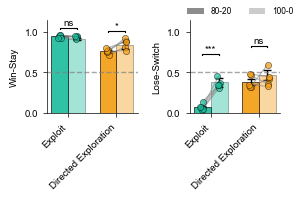

Paired t-tests (overlapping animals only):
State                     Metric            80-20 mean   100-0 mean   t-stat    p-value   sig
----------------------------------------------------------------------------------------------------
Exploit                   win_stay               0.948        0.938    0.995     0.3763    ns
Exploit                   lose_switch            0.072        0.364   -9.622     0.0007   ***
Directed Exploration      win_stay               0.761        0.857   -3.641     0.0220     *
Directed Exploration      lose_switch            0.385        0.428   -0.648     0.5522    ns


In [196]:
from scipy import stats
from matplotlib.patches import Patch

ws_ls_condition_animal_records = []

plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['axes.linewidth'] = 0.5
plt.rcParams['xtick.major.width'] = 0.5
plt.rcParams['ytick.major.width'] = 0.5

for condition, cdf in [('80-20', df_80_corrected), ('100-0', df_100_corrected)]:
    for state in ['Exploit', 'Directed Exploration']:
        sdf = cdf[cdf['Behavioral_State'] == state].copy()
        
        if len(sdf) < 30:
            continue
        
        sdf = sdf.sort_values(['Animal_Name', 'Session_ID', 'Trial'])
        sdf['Prev_Outcome'] = sdf.groupby(
            ['Animal_Name', 'Session_ID'])['Outcome_Binary'].shift(1)
        
        win_trials = sdf[sdf['Prev_Outcome'] == 1].dropna(subset=['PhysicalSwitch'])
        lose_trials = sdf[sdf['Prev_Outcome'] == 0].dropna(subset=['PhysicalSwitch'])
        
        ws_animal = (win_trials.groupby('Animal_Name')
                     .apply(lambda x: 1 - x['PhysicalSwitch'].mean())
                     .reset_index(name='win_stay'))
        ls_animal = (lose_trials.groupby('Animal_Name')
                     .apply(lambda x: x['PhysicalSwitch'].mean())
                     .reset_index(name='lose_switch'))
        
        for _, row in ws_animal.iterrows():
            ws_ls_condition_animal_records.append({
                'condition': condition,
                'state':     state,
                'animal':    row['Animal_Name'],
                'metric':    'win_stay',
                'value':     row['win_stay']
            })
        for _, row in ls_animal.iterrows():
            ws_ls_condition_animal_records.append({
                'condition': condition,
                'state':     state,
                'animal':    row['Animal_Name'],
                'metric':    'lose_switch',
                'value':     row['lose_switch']
            })

animal_df = pd.DataFrame(ws_ls_condition_animal_records)

# ── Compute p-values ──────────────────────────────────────────────────────────
pval_dict = {}
for state in ['Exploit', 'Directed Exploration']:
    for metric in ['win_stay', 'lose_switch']:
        vals_80, vals_100 = [], []
        for animal in OVERLAPPING_ANIMALS:
            v80 = animal_df[
                (animal_df['state'] == state) &
                (animal_df['condition'] == '80-20') &
                (animal_df['metric'] == metric) &
                (animal_df['animal'] == animal)
            ]['value'].values
            v100 = animal_df[
                (animal_df['state'] == state) &
                (animal_df['condition'] == '100-0') &
                (animal_df['metric'] == metric) &
                (animal_df['animal'] == animal)
            ]['value'].values
            if len(v80) > 0 and len(v100) > 0:
                vals_80.append(v80[0])
                vals_100.append(v100[0])
        if len(vals_80) >= 3:
            _, p_val = stats.ttest_rel(vals_80, vals_100)
            pval_dict[(state, metric)] = p_val

def get_sig_marker(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return 'ns'

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(3, 2), sharex=True)

colors_state = {'Exploit':              STATE_COLORS['Exploit'],
                'Directed Exploration': STATE_COLORS['Directed Exploration']}
STATES_TO_PLOT = ['Exploit', 'Directed Exploration']

for ax, metric, ylabel in zip(axes,
                               ['win_stay', 'lose_switch'],
                               ['Win-Stay', 'Lose-Switch']):
    
    x_pos = np.arange(len(STATES_TO_PLOT))
    width = 0.35
    
    for xi, state in enumerate(STATES_TO_PLOT):
        color = colors_state[state]
        
        for ci, condition in enumerate(['80-20', '100-0']):
            alpha = 0.9 if condition == '80-20' else 0.4
            x = xi + (ci - 0.5) * width
            
            vals = animal_df[
                (animal_df['state'] == state) &
                (animal_df['condition'] == condition) &
                (animal_df['metric'] == metric)
            ]
            
            if len(vals) == 0:
                continue
            
            mean = vals['value'].mean()
            sem  = vals['value'].sem()
            
            ax.bar(x, mean, width=width, color=color, alpha=alpha,
                   edgecolor='black', linewidth=0.5)
            ax.errorbar(x, mean, yerr=sem, fmt='none',
                       color='black', capsize=3, linewidth=LINE_WIDTH)
            
            rng = np.random.default_rng(xi + ci + 42)
            for _, row in vals.iterrows():
                if row['animal'] in OVERLAPPING_ANIMALS:
                    ax.scatter(x + rng.normal(0, 0.02),
                              row['value'],
                              color=color, s=20, alpha=0.7,
                              edgecolor='black', linewidth=0.4, zorder=4)
        
        # Draw connecting lines for overlapping animals
        for animal in OVERLAPPING_ANIMALS:
            v80 = animal_df[
                (animal_df['state'] == state) &
                (animal_df['condition'] == '80-20') &
                (animal_df['metric'] == metric) &
                (animal_df['animal'] == animal)
            ]['value'].values
            v100 = animal_df[
                (animal_df['state'] == state) &
                (animal_df['condition'] == '100-0') &
                (animal_df['metric'] == metric) &
                (animal_df['animal'] == animal)
            ]['value'].values
            
            if len(v80) > 0 and len(v100) > 0:
                x0 = xi - 0.5 * width
                x1 = xi + 0.5 * width
                ax.plot([x0, x1], [v80[0], v100[0]],
                       color='gray', linewidth=0.8,
                       alpha=0.6, zorder=3)
        
        # Add significance marker
        p_val = pval_dict.get((state, metric), 1.0)
        marker = get_sig_marker(p_val)
        
        # Find max value for bar height positioning
        all_vals = animal_df[
            (animal_df['state'] == state) &
            (animal_df['metric'] == metric)
        ]['value'].values
        y_max = max(all_vals) + 0.05 if len(all_vals) > 0 else 0.9
        
        x0 = xi - 0.5 * width
        x1 = xi + 0.5 * width
        y_bar = y_max + 0.02
        
        ax.plot([x0, x0, x1, x1],
                [y_bar, y_bar + 0.01, y_bar + 0.01, y_bar],
                color='black', linewidth=0.8)
        ax.text(xi, y_bar + 0.02, marker,
                ha='center', va='bottom',
                fontsize=FONTSIZE, color='black')
    
    ax.axhline(0.5, color='gray', linestyle='--',
               linewidth=LINE_WIDTH, alpha=0.7)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(STATES_TO_PLOT, rotation=45,
                       ha='right', fontsize=FONTSIZE)
    ax.set_ylabel(ylabel, fontsize=FONTSIZE)
    ax.set_ylim(0, 1.15)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(labelsize=FONTSIZE, length=TICK_LENGTH)

legend_elements = [
    Patch(facecolor='gray', alpha=0.9, label='80-20'),
    Patch(facecolor='gray', alpha=0.4, label='100-0'),
]
fig.legend(handles=legend_elements, fontsize=FONTSIZE-1, ncol=2,
           frameon=False, loc='upper right')

plt.tight_layout()
output_path = os.path.join(FIGURE_PATH, 'Figure7_WinStay_LoseSwitch_Fixed.svg')
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"✓ Saved: {output_path}")
plt.show()

# ── Print stats ───────────────────────────────────────────────────────────────
print("Paired t-tests (overlapping animals only):")
print(f"{'State':<25} {'Metric':<15} {'80-20 mean':>12} {'100-0 mean':>12} {'t-stat':>8} {'p-value':>10} {'sig':>5}")
print("-" * 100)
for state in ['Exploit', 'Directed Exploration']:
    for metric in ['win_stay', 'lose_switch']:
        vals_80, vals_100 = [], []
        for animal in OVERLAPPING_ANIMALS:
            v80 = animal_df[
                (animal_df['state'] == state) &
                (animal_df['condition'] == '80-20') &
                (animal_df['metric'] == metric) &
                (animal_df['animal'] == animal)
            ]['value'].values
            v100 = animal_df[
                (animal_df['state'] == state) &
                (animal_df['condition'] == '100-0') &
                (animal_df['metric'] == metric) &
                (animal_df['animal'] == animal)
            ]['value'].values
            if len(v80) > 0 and len(v100) > 0:
                vals_80.append(v80[0])
                vals_100.append(v100[0])
        if len(vals_80) >= 3:
            t_stat, p_val = stats.ttest_rel(vals_80, vals_100)
            print(f"{state:<25} {metric:<15} {np.mean(vals_80):>12.3f} {np.mean(vals_100):>12.3f} {t_stat:>8.3f} {p_val:>10.4f} {get_sig_marker(p_val):>5}")

In [110]:
streak_records = []
state_of_interest = 'Directed Exploration'

for condition, cdf in [('80-20', df_80_corrected), ('100-0', df_100_corrected)]:
    
    exploit_df = cdf[cdf['Behavioral_State'] == state_of_interest].copy()
    exploit_df = exploit_df.sort_values(['Animal_Name', 'Session_ID', 'Trial'])
    
    # Compute loss streak manually without groupby apply
    loss_streak_col = []
    
    for (animal, session), grp in exploit_df.groupby(['Animal_Name', 'Session_ID']):
        outcomes = grp['Outcome_Binary'].values
        current_streak = 0
        for i in range(len(outcomes)):
            loss_streak_col.append(current_streak)
            if outcomes[i] == 0:
                current_streak += 1
            else:
                current_streak = 0
    
    exploit_df['loss_streak'] = loss_streak_col
    
    # Compute switch rate by loss streak
    for streak in range(0, 5):
        sdf = exploit_df[exploit_df['loss_streak'] == streak]
        if len(sdf) < 10:
            continue
        
        animal_switch = (sdf.groupby('Animal_Name')['PhysicalSwitch']
                        .mean()
                        .reset_index(name='switch_rate'))
        
        streak_records.append({
            'condition':   condition,
            'state':       state_of_interest,
            'loss_streak': streak,
            'switch_rate': animal_switch['switch_rate'].mean(),
            'sem':         animal_switch['switch_rate'].sem(),
            'n_trials':    len(sdf)
        })

streak_df_results = pd.DataFrame(streak_records)
print(streak_df_results.to_string(index=False))

condition                state  loss_streak  switch_rate      sem  n_trials
    80-20 Directed Exploration            0     0.243897 0.015092      4294
    80-20 Directed Exploration            1     0.365497 0.037851      2012
    80-20 Directed Exploration            2     0.406896 0.046137       926
    80-20 Directed Exploration            3     0.447903 0.030076       362
    80-20 Directed Exploration            4     0.412228 0.048257        98
    100-0 Directed Exploration            0     0.156088 0.034236       772
    100-0 Directed Exploration            1     0.442923 0.061096       313
    100-0 Directed Exploration            2     0.554069 0.068520        68


✓ Saved: /Users/kevinmastro/Library/CloudStorage/GoogleDrive-kmastro@broadinstitute.org/Shared drives/Broad Marmoset/2-Experiments/5 - Monkey Logic Task/4 - Outputs/2-graphs/CrossProbStickyModel/Figure7_LossStreak_Directed Exploration.svg


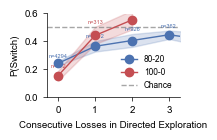

In [113]:
fig, ax = plt.subplots(figsize=(2, 1.5))

colors = {'80-20': '#4C72B0', '100-0': '#C44E52'}

for condition in ['80-20', '100-0']:
    cdf = streak_df_results[streak_df_results['condition'] == condition]
    
    ax.plot(cdf['loss_streak'], cdf['switch_rate'],
            'o-', color=colors[condition],
            linewidth=LINE_WIDTH, markersize=6,
            label=condition, zorder=4)
    ax.fill_between(cdf['loss_streak'],
                    cdf['switch_rate'] - cdf['sem'],
                    cdf['switch_rate'] + cdf['sem'],
                    alpha=0.2, color=colors[condition])

ax.axhline(0.5, color='gray', linestyle='--',
           linewidth=LINE_WIDTH, alpha=0.7, label='Chance')

ax.set_xlabel(f'Consecutive Losses in {state_of_interest}',
              fontsize=FONTSIZE)
ax.set_ylabel('P(Switch)', fontsize=FONTSIZE)
ax.set_xticks([0, 1, 2, 3])
ax.set_xticklabels(['0', '1', '2', '3'], fontsize=FONTSIZE)
ax.set_ylim(0, 0.6)
ax.set_xlim(-0.3, 3.3)
ax.legend(fontsize=FONTSIZE-1, frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(labelsize=FONTSIZE, length=TICK_LENGTH)

# Add n_trials annotations
for _, row in streak_df_results.iterrows():
    if row['n_trials'] >= 10:
        ax.annotate(f"n={row['n_trials']}",
                   (row['loss_streak'], row['switch_rate'] + row['sem'] + 0.02),
                   fontsize=FONTSIZE-3, ha='center', color=colors[row['condition']])

plt.tight_layout()
output_path = os.path.join(FIGURE_PATH, f'Figure7_LossStreak_{state_of_interest}.svg')
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"✓ Saved: {output_path}")
plt.show()

In [114]:
# Panel a — asymptotic performance
print("Asymptotic performance (last 5 pre-reversal trials):")
for condition, cdf in [('80-20', df_80_corrected), ('100-0', df_100_corrected)]:
    late_trials = cdf[cdf['Trials_Since_Transition'] > 10]
    animal_means = late_trials.groupby('Animal_Name')['High_Prob'].mean()
    print(f"  {condition}: {animal_means.mean():.3f} ± {animal_means.sem():.3f}")

# Panel b — basal switch rate (pre-reversal)
print("\nBasal switch rate (pre-reversal trials):")
for condition, cdf in [('80-20', df_80_corrected), ('100-0', df_100_corrected)]:
    pre_trials = cdf[cdf['Trials_Since_Transition'] < 0]
    animal_means = pre_trials.groupby('Animal_Name')['PhysicalSwitch'].mean()
    print(f"  {condition}: {animal_means.mean():.3f} ± {animal_means.sem():.3f}")

# Panel c — state proportions
print("\nState proportions by condition:")
for condition, cdf in [('80-20', df_80_corrected), ('100-0', df_100_corrected)]:
    print(f"\n  {condition}:")
    for state in STATES_ORDERED_FULL:
        prop = (cdf['Behavioral_State'] == state).mean()
        print(f"    {state}: {prop:.3f}")

Asymptotic performance (last 5 pre-reversal trials):
  80-20: 0.734 ± 0.018
  100-0: 0.786 ± 0.026

Basal switch rate (pre-reversal trials):
  80-20: nan ± nan
  100-0: nan ± nan

State proportions by condition:

  80-20:
    Unknown: 0.005
    Adapting: 0.300
    Directed Exploration: 0.211
    Random Exploration: 0.040
    Left Bias: 0.042
    Right Bias: 0.037
    Exploit: 0.365

  100-0:
    Unknown: 0.052
    Adapting: 0.256
    Directed Exploration: 0.088
    Random Exploration: 0.001
    Left Bias: 0.052
    Right Bias: 0.053
    Exploit: 0.498


In [118]:
from scipy import stats

print("Overall switch rate excluding Adapting state:")
for condition, cdf in [('80-20', df_80_corrected), ('100-0', df_100_corrected)]:
    non_adapt = cdf[~cdf['Behavioral_State'].isin(['Adapting', 'Unknown'])]
    animal_means = non_adapt.groupby('Animal_Name')['PhysicalSwitch'].mean()
    print(f"  {condition}: {animal_means.mean():.3f} ± {animal_means.sem():.3f}")

# Paired t-test
sw_80 = df_80_corrected[
    ~df_80_corrected['Behavioral_State'].isin(['Adapting', 'Unknown'])
].groupby('Animal_Name')['PhysicalSwitch'].mean().reindex(OVERLAPPING_ANIMALS)

sw_100 = df_100_corrected[
    df_100_corrected['Animal_Name'].isin(OVERLAPPING_ANIMALS)
][~df_100_corrected['Behavioral_State'].isin(['Adapting', 'Unknown'])
].groupby('Animal_Name')['PhysicalSwitch'].mean().reindex(OVERLAPPING_ANIMALS)

t_stat, p_val = stats.ttest_rel(sw_80, sw_100)
print(f"\nSwitch rate paired t-test: t={t_stat:.3f}, p={p_val:.4f}")

Overall switch rate excluding Adapting state:
  80-20: 0.175 ± 0.016
  100-0: 0.157 ± 0.034

Switch rate paired t-test: t=3.464, p=0.0257


In [119]:
from scipy import stats

perf_80 = df_80_corrected.groupby('Animal_Name')['High_Prob'].mean()
perf_100 = df_100_corrected[
    df_100_corrected['Animal_Name'].isin(OVERLAPPING_ANIMALS)
].groupby('Animal_Name')['High_Prob'].mean()

t_stat, p_val = stats.ttest_rel(
    perf_80.reindex(OVERLAPPING_ANIMALS),
    perf_100.reindex(OVERLAPPING_ANIMALS)
)
print(f"Asymptotic performance: t={t_stat:.3f}, p={p_val:.4f}")

from scipy import stats

for state in ['Exploit', 'Directed Exploration', 'Random Exploration']:
    props_80 = df_80_corrected.groupby('Animal_Name').apply(
        lambda x: (x['Behavioral_State'] == state).mean()
    ).reindex(OVERLAPPING_ANIMALS)
    
    props_100 = df_100_corrected[
        df_100_corrected['Animal_Name'].isin(OVERLAPPING_ANIMALS)
    ].groupby('Animal_Name').apply(
        lambda x: (x['Behavioral_State'] == state).mean()
    ).reindex(OVERLAPPING_ANIMALS)
    
    t_stat, p_val = stats.ttest_rel(props_80, props_100)
    print(f"{state}:")
    print(f"  80-20: {props_80.mean():.3f} ± {props_80.sem():.3f}")
    print(f"  100-0: {props_100.mean():.3f} ± {props_100.sem():.3f}")
    print(f"  t={t_stat:.3f}, p={p_val:.4f}")
    print()

Asymptotic performance: t=-4.214, p=0.0135
Exploit:
  80-20: 0.369 ± 0.014
  100-0: 0.521 ± 0.016
  t=-7.778, p=0.0015

Directed Exploration:
  80-20: 0.202 ± 0.016
  100-0: 0.076 ± 0.009
  t=8.605, p=0.0010

Random Exploration:
  80-20: 0.038 ± 0.002
  100-0: 0.002 ± 0.001
  t=15.004, p=0.0001



In [72]:
full_streak_records = []

for condition, cdf in [('80-20', df_80_corrected), ('100-0', df_100_corrected)]:
    
    working_df = cdf.copy()
    working_df = working_df.sort_values(['Animal_Name', 'Session_ID', 'Trial'])
    
    # Compute loss streak across all trials
    loss_streak_col = []
    
    for (animal, session), grp in working_df.groupby(['Animal_Name', 'Session_ID']):
        outcomes = grp['Outcome_Binary'].values
        current_streak = 0
        for i in range(len(outcomes)):
            loss_streak_col.append(current_streak)
            if outcomes[i] == 0:
                current_streak += 1
            else:
                current_streak = 0
    
    working_df['loss_streak'] = loss_streak_col
    
    for streak in range(0, 4):
        sdf = working_df[working_df['loss_streak'] == streak]
        if len(sdf) < 10:
            continue
        
        animal_switch = (sdf.groupby('Animal_Name')['PhysicalSwitch']
                        .mean()
                        .reset_index(name='switch_rate'))
        
        full_streak_records.append({
            'condition':   condition,
            'loss_streak': streak,
            'switch_rate': animal_switch['switch_rate'].mean(),
            'sem':         animal_switch['switch_rate'].sem(),
            'n_trials':    len(sdf)
        })

full_streak_df = pd.DataFrame(full_streak_records)
print(full_streak_df.to_string(index=False))

condition  loss_streak  switch_rate      sem  n_trials
    80-20            0     0.092364 0.006156     22062
    80-20            1     0.231691 0.039875      7450
    80-20            2     0.381270 0.046147      3487
    80-20            3     0.455295 0.033546      1819
    100-0            0     0.140654 0.027182      9852
    100-0            1     0.325252 0.038680      1340
    100-0            2     0.395843 0.031139       885
    100-0            3     0.433999 0.033534       517


✓ Saved: /Users/kevinmastro/Library/CloudStorage/GoogleDrive-kmastro@broadinstitute.org/Shared drives/Broad Marmoset/2-Experiments/5 - Monkey Logic Task/4 - Outputs/2-graphs/CrossProbStickyModel/Figure7_LossStreak_Both.svg


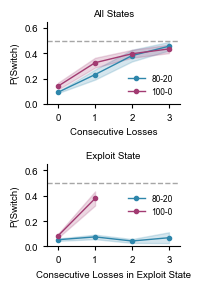

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(2, 3))

colors = {'80-20': COLOR_80_20, '100-0': COLOR_100_0}


# Panel 1 — Exploit state only
ax = axes[1]
for condition in ['80-20', '100-0']:
    cdf = streak_df_results[streak_df_results['condition'] == condition]
    
    ax.plot(cdf['loss_streak'], cdf['switch_rate'],
            'o-', color=colors[condition],
            linewidth=LINE_WIDTH, markersize=3,
            label=condition, zorder=4)
    ax.fill_between(cdf['loss_streak'],
                    cdf['switch_rate'] - cdf['sem'],
                    cdf['switch_rate'] + cdf['sem'],
                    alpha=0.2, color=colors[condition])

ax.axhline(0.5, color='gray', linestyle='--',
           linewidth=LINE_WIDTH, alpha=0.7)
ax.set_xlabel('Consecutive Losses in Exploit State',
              fontsize=FONTSIZE)
ax.set_ylabel('P(Switch)', fontsize=FONTSIZE)
ax.set_xticks([0, 1, 2, 3])
ax.set_ylim(0, 0.65)
ax.set_xlim(-0.3, 3.3)
ax.legend(fontsize=FONTSIZE-1, frameon=False)
ax.set_title('Exploit State', fontsize=FONTSIZE, pad=4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(labelsize=FONTSIZE, length=TICK_LENGTH)

# # Add n_trials annotations
# for _, row in streak_df_results.iterrows():
#     if row['n_trials'] >= 10:
#         ax.annotate(f"n={row['n_trials']}",
#                    (row['loss_streak'],
#                     row['switch_rate'] + row['sem'] + 0.02),
#                    fontsize=FONTSIZE-3, ha='center',
#                    color=colors[row['condition']])

# Panel 2 — Full dataset
ax = axes[0]
for condition in ['80-20', '100-0']:
    cdf = full_streak_df[full_streak_df['condition'] == condition]
    
    ax.plot(cdf['loss_streak'], cdf['switch_rate'],
            'o-', color=colors[condition],
            linewidth=LINE_WIDTH, markersize=3,
            label=condition, zorder=4)
    ax.fill_between(cdf['loss_streak'],
                    cdf['switch_rate'] - cdf['sem'],
                    cdf['switch_rate'] + cdf['sem'],
                    alpha=0.2, color=colors[condition])

ax.axhline(0.5, color='gray', linestyle='--',
           linewidth=LINE_WIDTH, alpha=0.7)
ax.set_xlabel('Consecutive Losses',
              fontsize=FONTSIZE)
ax.set_ylabel('P(Switch)', fontsize=FONTSIZE)
ax.set_xticks([0, 1, 2, 3])
ax.set_ylim(0, 0.65)
ax.set_xlim(-0.3, 3.3)
ax.legend(fontsize=FONTSIZE-1, frameon=False)
ax.set_title('All States', fontsize=FONTSIZE, pad=4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(labelsize=FONTSIZE, length=TICK_LENGTH)

# # Add n_trials annotations
# for _, row in full_streak_df.iterrows():
#     if row['n_trials'] >= 10:
#         ax.annotate(f"n={row['n_trials']}",
#                    (row['loss_streak'],
#                     row['switch_rate'] + row['sem'] + 0.02),
#                    fontsize=FONTSIZE-3, ha='center',
#                    color=colors[row['condition']])

plt.tight_layout()
output_path = os.path.join(FIGURE_PATH, 'Figure7_LossStreak_Both.svg')
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"✓ Saved: {output_path}")
plt.show()

In [112]:
win_streak_records = []

for condition, cdf in [('80-20', df_80_corrected), ('100-0', df_100_corrected)]:
    
    exploit_df = cdf[cdf['Behavioral_State'] == 'Directed Exploration'].copy()
    exploit_df = exploit_df.sort_values(['Animal_Name', 'Session_ID', 'Trial'])
    
    # Compute consecutive win streak before each trial
    win_streak_col = []
    
    for (animal, session), grp in exploit_df.groupby(['Animal_Name', 'Session_ID']):
        outcomes = grp['Outcome_Binary'].values
        current_streak = 0
        for i in range(len(outcomes)):
            win_streak_col.append(current_streak)
            if outcomes[i] == 1:
                current_streak += 1
            else:
                current_streak = 0
    
    exploit_df['win_streak'] = win_streak_col
    
    for streak in range(0, 5):
        sdf = exploit_df[exploit_df['win_streak'] == streak]
        if len(sdf) < 10:
            continue
        
        animal_stay = (sdf.groupby('Animal_Name')['PhysicalSwitch']
                        .apply(lambda x: 1 - x.mean())
                        .reset_index(name='stay_rate'))
        
        win_streak_records.append({
            'condition':   condition,
            'win_streak':  streak,
            'stay_rate':   animal_stay['stay_rate'].mean(),
            'sem':         animal_stay['stay_rate'].sem(),
            'n_trials':    len(sdf)
        })

win_streak_df = pd.DataFrame(win_streak_records)
print(win_streak_df.to_string(index=False))

condition  win_streak  stay_rate      sem  n_trials
    80-20           0   0.613492 0.035404      3537
    80-20           1   0.784299 0.016958      2004
    80-20           2   0.738999 0.022917      1201
    80-20           3   0.733508 0.041848       622
    80-20           4   0.826198 0.044950       213
    100-0           0   0.652629 0.042728       585
    100-0           1   0.862498 0.042498       317
    100-0           2   0.867513 0.036685       149
    100-0           3   0.642126 0.081466        84
    100-0           4   0.916667 0.083333        12


In [214]:
from scipy.stats import ttest_rel, wilcoxon

STATES = ['Engaged', 'Directed Exploration', 
          'Random Exploration', 'Left Bias', 'Right Bias']

# ── Per-animal state proportions ─────────────────────────────────────────────
def state_proportions(df, session_col, animals, exclude_states=['Unknown']):
    records = []
    for animal, adf in df.groupby('Animal_Name'):
        if animal not in animals:
            continue
        total = adf['Behavioral_State'].isin(STATES).sum()
        row   = {'Animal_Name': animal}
        for state in STATES:
            count = (adf['Behavioral_State'] == state).sum()
            row[state] = count / total if total > 0 else np.nan
        records.append(row)
    return pd.DataFrame(records).set_index('Animal_Name')

props_80  = state_proportions(df_80_corrected,     'Session_ID',      ANIMALS_80)
props_100 = state_proportions(df_100_corrected, 'Fit_Session_ID',  ANIMALS_100)

print("80-20 state proportions (per animal):")
print((props_80 * 100).round(1).to_string())
print("\n100-0 state proportions (per animal):")
print((props_100 * 100).round(1).to_string())

# ── Stats on overlapping animals ─────────────────────────────────────────────
print("\nPaired comparisons (overlapping animals, n=5):")
print(f"{'State':25s}  {'80-20':>6}  {'100-0':>6}  {'p':>6}  sig")
print("-" * 55)
for state in STATES:
    v80  = np.array([props_80.loc[a, state]  for a in OVERLAPPING_ANIMALS])
    v100 = np.array([props_100.loc[a, state] for a in OVERLAPPING_ANIMALS])
    _, p = ttest_rel(v80, v100)
    sig  = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'n.s.'
    print(f"  {state:23s}  {v80.mean()*100:5.1f}%  {v100.mean()*100:5.1f}%  "
          f"{p:6.3f}  {sig}")

80-20 state proportions (per animal):
             Engaged  Directed Exploration  Random Exploration  Left Bias  Right Bias
Animal_Name                                                                          
Fiona           47.5                  24.0                 6.0       13.3         9.2
Knuckles        42.7                  31.8                 6.5        8.2        10.8
Sonic           42.7                  26.5                 6.8       18.9         5.1
Sunflower       40.4                  35.7                 7.0        6.0        10.9
Zazu            42.7                  26.3                 5.5        6.6        19.0

100-0 state proportions (per animal):
             Engaged  Directed Exploration  Random Exploration  Left Bias  Right Bias
Animal_Name                                                                          
Coral           44.4                  18.7                 0.1       18.5        18.3
Fiona           62.8                  12.4                 0.5 

In [136]:
fig, axes = plt.subplots(1, len(STATES), figsize=(10, 3.5))

STATE_COLORS = {
    'Engaged':              '#2ecc71',
    'Adapting':             '#3498db',
    'Directed Exploration': '#9b59b6',
    'Random Exploration':   '#e74c3c',
    'Left Bias':            '#f39c12',
    'Right Bias':           '#1abc9c',
}

sig_map = {
    'Engaged':              '***',
    'Adapting':             '*',
    'Directed Exploration': '**',
    'Random Exploration':   '***',
    'Left Bias':            'n.s.',
    'Right Bias':           'n.s.',
}

for ax, state in zip(axes, STATES):
    v80  = np.array([props_80.loc[a, state]  for a in OVERLAPPING_ANIMALS])
    v100 = np.array([props_100.loc[a, state] for a in OVERLAPPING_ANIMALS])

    # Unpaired 100-0 animals
    for a in UNPAIRED_100:
        ax.scatter([1], [props_100.loc[a, state]],
                   color=ANIMAL_COLORS[a], s=25,
                   marker='s', edgecolor='black',
                   linewidth=0.4, alpha=0.5, zorder=3)

    # Paired lines
    for a in OVERLAPPING_ANIMALS:
        ax.plot([0, 1], [props_80.loc[a, state], props_100.loc[a, state]],
                color=ANIMAL_COLORS[a], lw=LINE_WIDTH, alpha=0.7, zorder=2)
        ax.scatter([0], [props_80.loc[a, state]],
                   color=ANIMAL_COLORS[a], s=25,
                   edgecolor='black', linewidth=0.4, zorder=3)
        ax.scatter([1], [props_100.loc[a, state]],
                   color=ANIMAL_COLORS[a], s=25,
                   marker='s', edgecolor='black', linewidth=0.4, zorder=3)

    # Mean ± SEM
    for x, vals in [(0, v80), (1, v100)]:
        ax.errorbar(x, vals.mean(), yerr=sem(vals),
                    fmt='o', color='black', markersize=5,
                    capsize=3, linewidth=LINE_WIDTH*1.5, zorder=5)

    # Significance
    sig  = sig_map[state]
    ymax = max(props_100[state].max(), props_80[state].max()) * 1.15
    ax.plot([0, 1], [ymax, ymax], color='black', lw=0.8)
    ax.text(0.5, ymax*1.02, sig, ha='center', va='bottom', fontsize=FONTSIZE)

    ax.set_xticks([0, 1])
    ax.set_xticklabels(['80-20', '100-0'], fontsize=FONTSIZE, rotation=30)
    ax.set_ylabel('Proportion of trials', fontsize=FONTSIZE)
    ax.set_title(state, fontsize=FONTSIZE, color=STATE_COLORS[state],
                 fontweight='bold')
    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(0, ymax * 1.15)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(labelsize=FONTSIZE, length=TICK_LENGTH)

# Legend
handles = [plt.scatter([], [], color=ANIMAL_COLORS[a], s=25,
                       edgecolor='black', linewidth=0.4, label=a)
           for a in ANIMAL_ORDER if a in ANIMALS_80 + ANIMALS_100]
fig.legend(handles=handles, loc='lower center', ncol=7,
           frameon=False, fontsize=FONTSIZE,
           bbox_to_anchor=(0.5, -0.08))

plt.suptitle('Behavioral state distribution: 80-20 vs 100-0',
             fontsize=FONTSIZE+1, y=1.02)
plt.tight_layout()
plt.savefig('BehavioralState_Comparison.svg', dpi=300, bbox_inches='tight')
print("✓ Saved BehavioralState_Comparison.svg")
plt.show()

NameError: name 'STATES' is not defined

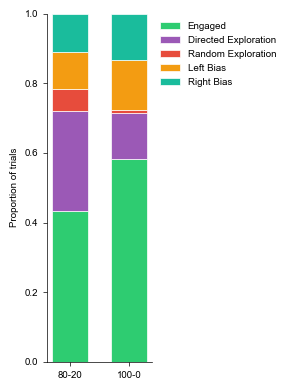

In [216]:
fig2, ax = plt.subplots(figsize=(3, 4))

means_80  = props_80.mean()
means_100 = props_100.mean()

bottom_80  = 0
bottom_100 = 0
for state in STATES:
    ax.bar(0, means_80[state],  bottom=bottom_80,
           color=STATE_COLORS[state], width=0.6, edgecolor='white', lw=0.5)
    ax.bar(1, means_100[state], bottom=bottom_100,
           color=STATE_COLORS[state], width=0.6, edgecolor='white', lw=0.5,
           label=state)
    bottom_80  += means_80[state]
    bottom_100 += means_100[state]

ax.set_xticks([0, 1])
ax.set_xticklabels(['80-20', '100-0'], fontsize=FONTSIZE)
ax.set_ylabel('Proportion of trials', fontsize=FONTSIZE)
ax.set_ylim(0, 1)
ax.legend(frameon=False, fontsize=FONTSIZE, bbox_to_anchor=(1, 1), loc='upper left')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(labelsize=FONTSIZE, length=TICK_LENGTH)

plt.tight_layout()
plt.savefig('BehavioralState_StackedBar.svg', dpi=300, bbox_inches='tight')
plt.show()

In [107]:
def fit_rl_model_fixed_alpha(df, session_col='Session_ID', 
                              alpha_fixed=None, min_trials=30, n_starts=5):
    """
    Fit sticky Q-learning with fixed alpha.
    alpha_fixed: float or dict {Animal_Name: alpha_value}
    Only optimizes beta and kappa.
    """
    bounds  = [(1e-3, 50.0), (-10.0, 10.0)]  # beta, kappa only
    records = []

    for session, sdf in df.groupby(session_col):
        sdf     = sdf.sort_values('Trial').copy()
        animal  = sdf['Animal_Name'].iloc[0]
        valid   = sdf[['Choice_Binary','Outcome_Binary']].dropna()
        choices = valid['Choice_Binary'].values.astype(int)
        rewards = valid['Outcome_Binary'].values.astype(int)

        if len(choices) < min_trials:
            continue

        # Resolve fixed alpha
        if isinstance(alpha_fixed, dict):
            alpha = alpha_fixed.get(animal, np.nan)
            if np.isnan(alpha):
                continue
        else:
            alpha = alpha_fixed

        best_res = None
        for seed in range(n_starts):
            rng = np.random.default_rng(seed)
            x0  = np.array([
                rng.uniform(0.5, 5.0),   # beta
                rng.uniform(-2.0, 2.0),  # kappa
            ])
            res = minimize(
                qlearn_sticky_nll_fixed_alpha,
                x0=x0,
                args=(choices, rewards, alpha),
                method='L-BFGS-B',
                bounds=bounds
            )
            if best_res is None or res.fun < best_res.fun:
                best_res = res

        records.append(dict(
            Session_ID     = session,
            Animal_Name    = animal,
            alpha          = alpha,
            beta           = best_res.x[0],
            kappa          = best_res.x[1],
            nll            = best_res.fun,
            n_trials       = len(choices),
            beta_at_bound  = best_res.x[0] >= 49.9,
            kappa_at_bound = abs(best_res.x[1]) >= 9.9,
        ))

    return pd.DataFrame(records)


def qlearn_sticky_nll_fixed_alpha(params, choices, rewards, alpha):
    """NLL with fixed alpha, optimizing only beta and kappa."""
    beta, kappa = params
    Q           = np.array([0.5, 0.5])
    nll         = 0.0
    prev_choice = None

    for c, r in zip(choices, rewards):
        stick   = 0.0 if prev_choice is None else (
            1.0 if prev_choice == 1 else -1.0)
        z       = beta * (Q[1] - Q[0]) + kappa * stick
        p_right = 1.0 / (1.0 + np.exp(-np.clip(z, -50, 50)))
        p_chose = p_right if c == 1 else 1.0 - p_right
        nll    -= np.log(np.clip(p_chose, 1e-10, 1.0))
        Q[c]   += alpha * (r - Q[c])
        prev_choice = c

    return nll


# ── Animal-level alpha from free 80-20 fit ───────────────────────────────────
alpha_per_animal = (params_80_sess[params_80_sess['group'] == 'non_boundary']
                    .groupby('Animal_Name')['alpha']
                    .mean()
                    .to_dict())
print("Per-animal alpha from 80-20:")
for a, v in alpha_per_animal.items():
    print(f"  {a:12s}: {v:.3f}")

# ── Option 1: Fix alpha=1 for both conditions ────────────────────────────────
print("\nFitting Option 1 (alpha=1) — 80-20...")
params_80_a1 = fit_rl_model_fixed_alpha(
    df_80_pseudo, session_col='Session_ID',
    alpha_fixed=1.0, min_trials=30
)
print(f"  {len(params_80_a1)} sessions, "
      f"boundary: {params_80_a1['beta_at_bound'].sum()}")

print("Fitting Option 1 (alpha=1) — 100-0...")
params_100_a1 = fit_rl_model_fixed_alpha(
    df_100_corrected, session_col='Fit_Session_ID',
    alpha_fixed=1.0, min_trials=30
)
print(f"  {len(params_100_a1)} sessions, "
      f"boundary: {params_100_a1['beta_at_bound'].sum()}")

# ── Option 3: Fix alpha at animal's 80-20 estimate ───────────────────────────
print("\nFitting Option 3 (alpha=animal 80-20 estimate) — 80-20...")
params_80_a3 = fit_rl_model_fixed_alpha(
    df_80_pseudo, session_col='Session_ID',
    alpha_fixed=alpha_per_animal, min_trials=30
)
print(f"  {len(params_80_a3)} sessions, "
      f"boundary: {params_80_a3['beta_at_bound'].sum()}")

print("Fitting Option 3 (alpha=animal 80-20 estimate) — 100-0...")
params_100_a3 = fit_rl_model_fixed_alpha(
    df_100_corrected, session_col='Fit_Session_ID',
    alpha_fixed=alpha_per_animal, min_trials=30
)
print(f"  {len(params_100_a3)} sessions, "
      f"boundary: {params_100_a3['beta_at_bound'].sum()}")

Per-animal alpha from 80-20:
  Fiona       : 0.614
  Knuckles    : 0.676
  Sonic       : 0.782
  Sunflower   : 0.727
  Zazu        : 0.704

Fitting Option 1 (alpha=1) — 80-20...
  100 sessions, boundary: 0
Fitting Option 1 (alpha=1) — 100-0...
  146 sessions, boundary: 0

Fitting Option 3 (alpha=animal 80-20 estimate) — 80-20...
  100 sessions, boundary: 0
Fitting Option 3 (alpha=animal 80-20 estimate) — 100-0...
  122 sessions, boundary: 0


In [108]:
def animal_params_fixed(params_df, condition_label):
    return (params_df
            .groupby('Animal_Name')[['alpha','beta','kappa']]
            .mean()
            .reset_index()
            .assign(condition=condition_label))

# Option 1
animal_80_a1  = animal_params_fixed(params_80_a1,  '80-20')
animal_100_a1 = animal_params_fixed(params_100_a1, '100-0')
merged_a1 = (animal_80_a1
             .merge(animal_100_a1, on='Animal_Name', suffixes=('_80','_100'))
             .query('Animal_Name in @OVERLAPPING_ANIMALS'))

# Option 3
animal_80_a3  = animal_params_fixed(params_80_a3,  '80-20')
animal_100_a3 = animal_params_fixed(params_100_a3, '100-0')
merged_a3 = (animal_80_a3
             .merge(animal_100_a3, on='Animal_Name', suffixes=('_80','_100'))
             .query('Animal_Name in @OVERLAPPING_ANIMALS'))

# Stats
for label, merged in [('Option 1 (α=1)', merged_a1), 
                       ('Option 3 (α=animal estimate)', merged_a3)]:
    print(f"\n{label}")
    print(f"{'':25s}  {'80-20':>6}  {'100-0':>6}  {'p':>6}  sig")
    print("-" * 55)
    for param, pname in [('beta','β'), ('kappa','κ')]:
        v80  = merged[f'{param}_80'].values
        v100 = merged[f'{param}_100'].values
        _, p = ttest_rel(v80, v100)
        sig  = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'n.s.'
        print(f"  {pname:23s}  {v80.mean():6.3f}  {v100.mean():6.3f}  "
              f"{p:6.3f}  {sig}")


Option 1 (α=1)
                            80-20   100-0       p  sig
-------------------------------------------------------
  β                         0.932   2.548   0.057  n.s.
  κ                         1.251   2.139   0.135  n.s.

Option 3 (α=animal estimate)
                            80-20   100-0       p  sig
-------------------------------------------------------
  β                         1.206   2.800   0.079  n.s.
  κ                         1.229   2.102   0.111  n.s.


In [111]:
from scipy.stats import permutation_test

def permutation_paired(params_80, params_100, param, n_perm=10000):
    """Permutation test on animal-level means."""
    animals = OVERLAPPING_ANIMALS
    v80  = np.array([params_80[params_80['Animal_Name']==a][param].mean() 
                     for a in animals])
    v100 = np.array([params_100[params_100['Animal_Name']==a][param].mean() 
                     for a in animals])
    obs_diff = v100.mean() - v80.mean()
    
    diffs = []
    rng = np.random.default_rng(42)
    for _ in range(n_perm):
        # Randomly flip signs of paired differences
        signs = rng.choice([-1, 1], size=len(animals))
        diffs.append(((v100 - v80) * signs).mean())
    
    p = np.mean(np.abs(diffs) >= np.abs(obs_diff))
    return obs_diff, p

print("Permutation tests (n=10,000):")
print(f"\nOption 1 (α=1):")
for param in ['beta', 'kappa']:
    diff, p = permutation_paired(params_80_a1, params_100_a1, param)
    sig = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'n.s.'
    print(f"  {param:6s}: Δ={diff:+.3f}, p={p:.3f} {sig}")

print(f"\nOption 3 (α=animal estimate):")
for param in ['beta', 'kappa']:
    diff, p = permutation_paired(params_80_a3, params_100_a3, param)
    sig = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'n.s.'
    print(f"  {param:6s}: Δ={diff:+.3f}, p={p:.3f} {sig}")

Permutation tests (n=10,000):

Option 1 (α=1):
  beta  : Δ=+1.616, p=0.000 ***
  kappa : Δ=+0.888, p=0.060 n.s.

Option 3 (α=animal estimate):
  beta  : Δ=+1.594, p=0.121 n.s.
  kappa : Δ=+0.873, p=0.121 n.s.


In [116]:
Q_COLS_NEEDED = ['Q_left', 'Q_right', 'Q_diff', 'Model_P_Right', 
                 'Model_Switch', 'Chose_Higher_Q']

print("df_80_pseudo:")
for col in Q_COLS_NEEDED:
    if col in df_80_pseudo.columns:
        n_nan = df_80_pseudo[col].isna().sum()
        print(f"  ✓ {col:20s} (NaN: {n_nan})")
    else:
        print(f"  ✗ {col:20s} MISSING")

print("\ndf_100_corrected:")
for col in Q_COLS_NEEDED:
    if col in df_100_corrected.columns:
        n_nan = df_100_corrected[col].isna().sum()
        print(f"  ✓ {col:20s} (NaN: {n_nan})")
    else:
        print(f"  ✗ {col:20s} MISSING")

df_80_pseudo:
  ✓ Q_left               (NaN: 0)
  ✓ Q_right              (NaN: 0)
  ✓ Q_diff               (NaN: 0)
  ✓ Model_P_Right        (NaN: 0)
  ✓ Model_Switch         (NaN: 100)
  ✓ Chose_Higher_Q       (NaN: 0)

df_100_corrected:
  ✓ Q_left               (NaN: 332)
  ✓ Q_right              (NaN: 332)
  ✓ Q_diff               (NaN: 332)
  ✓ Model_P_Right        (NaN: 332)
  ✓ Model_Switch         (NaN: 509)
  ✗ Chose_Higher_Q       MISSING


In [117]:
# ── Add Chose_Higher_Q to df_100_corrected ────────────────────────────────────
df_100_corrected['Chose_Higher_Q'] = (
    ((df_100_corrected['Choice_Binary'] == 1) & (df_100_corrected['Q_diff'] > 0)) |
    ((df_100_corrected['Choice_Binary'] == 0) & (df_100_corrected['Q_diff'] < 0))
).astype(float)
df_100_corrected.loc[df_100_corrected['Q_diff'] == 0, 'Chose_Higher_Q'] = np.nan

print(f"Chose_Higher_Q mean 80-20: {df_80_pseudo['Chose_Higher_Q'].mean():.3f}")
print(f"Chose_Higher_Q mean 100-0: {df_100_corrected['Chose_Higher_Q'].mean():.3f}")

# ── Alias both as df_80_q and df_100_q ───────────────────────────────────────
df_80_q  = df_80_pseudo
df_100_q = df_100_corrected

# ── Remaining objects needed for figure ──────────────────────────────────────
OVERLAP_ANIMALS = OVERLAPPING_ANIMALS
STATES_ORDERED  = ['Engaged', 'Adapting', 'Directed Exploration',
                   'Random Exploration', 'Left Bias', 'Right Bias']

# Session-level Q-following
sess_80_qf = (df_80_q[df_80_q['Animal_Name'].isin(OVERLAP_ANIMALS)]
              .groupby(['Animal_Name','Session_ID'])['Chose_Higher_Q']
              .mean().reset_index())

sess_100_qf = (df_100_q[df_100_q['Animal_Name'].isin(OVERLAP_ANIMALS)]
               .groupby(['Animal_Name','Fit_Session_ID'])['Chose_Higher_Q']
               .mean().reset_index()
               .rename(columns={'Fit_Session_ID':'Session_ID'}))

# Animal-level params for overlapping animals (fixed alpha=1)
params_80_ov  = (params_80_a1
                 .groupby('Animal_Name')[['alpha','beta','kappa']]
                 .mean().reset_index()
                 .query('Animal_Name in @OVERLAP_ANIMALS'))

params_100_ov = (params_100_a1
                 .groupby('Animal_Name')[['alpha','beta','kappa']]
                 .mean().reset_index()
                 .query('Animal_Name in @OVERLAP_ANIMALS'))

# State occupancy
def state_occupancy(df, states):
    total = df['Behavioral_State'].isin(states).sum()
    return {s: df['Behavioral_State'].eq(s).sum() / total * 100
            for s in states}

state_occ_80  = state_occupancy(df_80_q,  STATES_ORDERED)
state_occ_100 = state_occupancy(df_100_q, STATES_ORDERED)

# Verify all objects
print("\nAll objects ready:")
print(f"  df_80_q:       {len(df_80_q):,} trials")
print(f"  df_100_q:      {len(df_100_q):,} trials")
print(f"  sess_80_qf:    {len(sess_80_qf)} sessions")
print(f"  sess_100_qf:   {len(sess_100_qf)} sessions")
print(f"  params_80_ov:  {len(params_80_ov)} animals")
print(f"  params_100_ov: {len(params_100_ov)} animals")
print(f"  state_occ_80:  {state_occ_80}")
print(f"  state_occ_100: {state_occ_100}")

Chose_Higher_Q mean 80-20: 0.706
Chose_Higher_Q mean 100-0: 0.732

All objects ready:
  df_80_q:       36,673 trials
  df_100_q:      13,163 trials
  sess_80_qf:    100 sessions
  sess_100_qf:   166 sessions
  params_80_ov:  5 animals
  params_100_ov: 5 animals
  state_occ_80:  {'Engaged': np.float64(36.65999506484249), 'Adapting': np.float64(30.20042223014284), 'Directed Exploration': np.float64(21.196501521673568), 'Random Exploration': np.float64(3.989252323636663), 'Left Bias': np.float64(4.197625640885038), 'Right Bias': np.float64(3.7562032188194006)}
  state_occ_100: {'Engaged': np.float64(52.55269696241084), 'Adapting': np.float64(26.977638855494106), 'Directed Exploration': np.float64(9.257032940610724), 'Random Exploration': np.float64(0.11220645988619059), 'Left Bias': np.float64(5.474072293019155), 'Right Bias': np.float64(5.626352488578985)}


Psychometric fits:
  Fiona         80-20: β=2.34 x0=0.14  100-0: β=1.72 x0=-0.01
  Knuckles      80-20: β=1.86 x0=-0.07  100-0: β=1.55 x0=0.06
  Sonic         80-20: β=1.34 x0=0.18  100-0: β=1.67 x0=-0.16
  Zazu          80-20: β=1.40 x0=-0.55  100-0: β=1.76 x0=0.15
  Sunflower     80-20: β=1.90 x0=-0.28  100-0: β=1.50 x0=-0.16
✓ Saved main_figure_cross_prob.svg


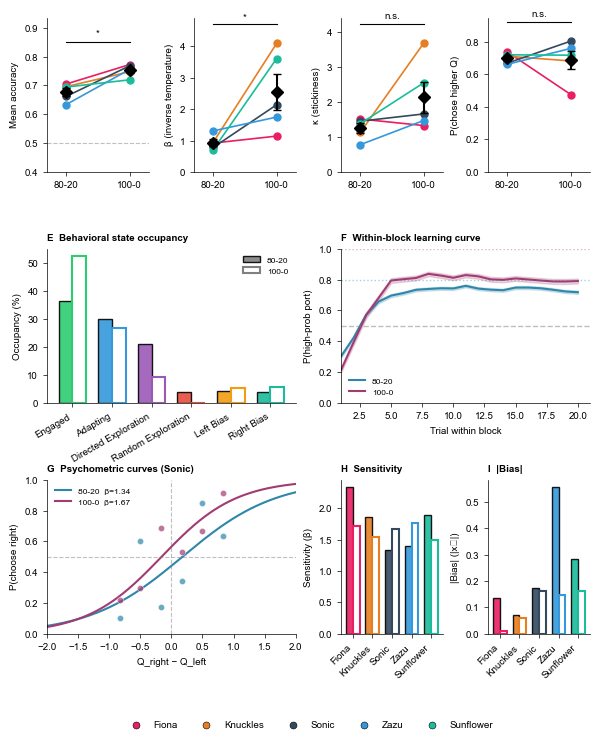

In [188]:
from scipy.optimize import curve_fit
from scipy.stats import ttest_ind, sem

FONTSIZE   = 7
LINE_WIDTH = 1.0
TICK_LENGTH = 3
animals_ov = [a for a in ANIMAL_ORDER if a in OVERLAP_ANIMALS]

# ── Pre-compute sigmoid fits ──────────────────────────────────────────────────
def sigmoid_2param(x, x0, k):
    return 1.0 / (1.0 + np.exp(-k * (x - x0)))

animal_psych_params = {}
for animal in animals_ov:
    animal_psych_params[animal] = {}
    for df_cond, cond_key, scol in [
        (df_80_q,  '80',  'Session_ID'),
        (df_100_q, '100', 'Fit_Session_ID'),
    ]:
        df_a = df_cond[df_cond['Animal_Name'] == animal].copy()
        df_a = df_a.dropna(subset=['Q_right','Q_left','Choice_Binary'])
        if df_a.empty:
            animal_psych_params[animal][cond_key] = (np.nan, np.nan)
            continue

        df_a['delta_Q'] = np.clip(df_a['Q_right'] - df_a['Q_left'], -2, 2)
        bins = np.linspace(-2, 2, 13)
        df_a['bin'] = pd.cut(df_a['delta_Q'], bins=bins,
                              labels=(bins[:-1] + bins[1:]) / 2)
        binned = (df_a.groupby('bin', observed=True)['Choice_Binary']
                  .agg(['mean','count']).reset_index())
        binned = binned[binned['count'] >= 10]
        binned['bin'] = binned['bin'].astype(float)

        if len(binned) < 3:
            animal_psych_params[animal][cond_key] = (np.nan, np.nan)
            continue
        try:
            popt, _ = curve_fit(sigmoid_2param, binned['bin'], binned['mean'],
                                p0=[0, 1.0], bounds=([-2, 0.01], [2, 20.0]))
            animal_psych_params[animal][cond_key] = (popt[0], popt[1])
        except Exception:
            animal_psych_params[animal][cond_key] = (np.nan, np.nan)

print("Psychometric fits:")
for a in animals_ov:
    x0_80, k_80   = animal_psych_params[a]['80']
    x0_100, k_100 = animal_psych_params[a]['100']
    print(f"  {a:12s}  80-20: β={k_80:.2f} x0={x0_80:.2f}  "
          f"100-0: β={k_100:.2f} x0={x0_100:.2f}")

# ── Figure ────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(7, 8))
gs  = gridspec.GridSpec(3, 4, figure=fig, hspace=0.5, wspace=0.45)

# ── Replace α panel with accuracy ────────────────────────────────────────────
ax_acc = fig.add_subplot(gs[0, 0])

acc_80_ov  = (df_80_q[df_80_q['Animal_Name'].isin(OVERLAP_ANIMALS)]
              .groupby('Animal_Name')['High_Prob'].mean())
acc_100_ov = (df_100_q[df_100_q['Animal_Name'].isin(OVERLAP_ANIMALS)]
              .groupby('Animal_Name')['High_Prob'].mean())

v80  = np.array([acc_80_ov.loc[a]  for a in animals_ov])
v100 = np.array([acc_100_ov.loc[a] for a in animals_ov])

for animal, y0, y1 in zip(animals_ov, v80, v100):
    ax_acc.plot([0, 1], [y0, y1], 'o-',
                color=ANIMAL_COLORS[animal], linewidth=1.2, markersize=5)

for x, vals in [(0, v80), (1, v100)]:
    ax_acc.errorbar(x, vals.mean(), yerr=sem(vals),
                    fmt='D', color='black', markersize=6,
                    capsize=3, linewidth=LINE_WIDTH*1.5, zorder=5)

_, p_acc = ttest_rel(v80, v100)
sig_acc  = '***' if p_acc<0.001 else '**' if p_acc<0.01 else '*' if p_acc<0.05 else 'n.s.'
ymax = max(v80.max(), v100.max()) * 1.1
ax_acc.plot([0,1],[ymax,ymax], color='black', lw=0.8)
ax_acc.text(0.5, ymax*1.02, sig_acc, ha='center', va='bottom', fontsize=FONTSIZE)
ax_acc.axhline(0.5, color='gray', ls='--', lw=0.8, alpha=0.5)
ax_acc.set_xticks([0, 1])
ax_acc.set_xticklabels(['80-20','100-0'], fontsize=FONTSIZE)
ax_acc.set_ylabel('Mean accuracy', fontsize=FONTSIZE)
ax_acc.set_xlim(-0.3, 1.3)
ax_acc.set_ylim(0.4, ymax*1.1)
ax_acc.spines[['top','right']].set_visible(False)
ax_acc.tick_params(labelsize=FONTSIZE, length=TICK_LENGTH)


# ── ROW 1: RL parameters ─────────────────────────────────────────────────────
for col, param, label in [
    (1, 'beta',  'β (inverse temperature)'),
    (2, 'kappa', 'κ (stickiness)'),
]:
    ax = fig.add_subplot(gs[0, col])
    v80  = params_80_ov[param].values
    v100 = params_100_ov[param].values

    for animal, y0, y1 in zip(animals_ov, v80, v100):
        ax.plot([0, 1], [y0, y1], 'o-',
                color=ANIMAL_COLORS.get(animal, 'gray'),
                linewidth=1.2, markersize=5)

    for x, vals in [(0, v80), (1, v100)]:
        ax.errorbar(x, vals.mean(), yerr=sem(vals),
                    fmt='D', color='black', markersize=6,
                    capsize=3, linewidth=LINE_WIDTH*1.5, zorder=5)

    _, p = ttest_ind(v80, v100)
    sig  = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'n.s.'
    ymax = max(v80.max(), v100.max()) * 1.15
    ax.plot([0,1],[ymax,ymax], color='black', lw=0.8)
    ax.text(0.5, ymax*1.02, sig, ha='center', va='bottom', fontsize=FONTSIZE)

    ax.set_xticks([0, 1])
    ax.set_xticklabels(['80-20','100-0'], fontsize=FONTSIZE)
    ax.set_ylabel(label, fontsize=FONTSIZE)
    ax.set_xlim(-0.3, 1.3)
    ax.set_ylim(bottom=0)
    ax.spines[['top','right']].set_visible(False)
    ax.tick_params(labelsize=FONTSIZE, length=TICK_LENGTH)

# Panel D: Q-following
ax_D = fig.add_subplot(gs[0, 3])
for animal in animals_ov:
    fq80  = sess_80_qf[sess_80_qf['Animal_Name']  == animal]['Chose_Higher_Q'].mean()
    fq100 = sess_100_qf[sess_100_qf['Animal_Name'] == animal]['Chose_Higher_Q'].mean()
    ax_D.plot([0, 1], [fq80, fq100], 'o-',
              color=ANIMAL_COLORS.get(animal, 'gray'),
              linewidth=1.2, markersize=5)

v80_fq  = np.array([sess_80_qf[sess_80_qf['Animal_Name']==a]['Chose_Higher_Q'].mean()
                     for a in animals_ov])
v100_fq = np.array([sess_100_qf[sess_100_qf['Animal_Name']==a]['Chose_Higher_Q'].mean()
                     for a in animals_ov])
for x, vals in [(0, v80_fq), (1, v100_fq)]:
    ax_D.errorbar(x, vals.mean(), yerr=sem(vals),
                  fmt='D', color='black', markersize=6,
                  capsize=3, linewidth=LINE_WIDTH*1.5, zorder=5)

_, p_fq = ttest_ind(v80_fq, v100_fq)
sig_fq  = '***' if p_fq<0.001 else '**' if p_fq<0.01 else '*' if p_fq<0.05 else 'n.s.'
ymax = max(v80_fq.max(), v100_fq.max()) * 1.15
ax_D.plot([0,1],[ymax,ymax], color='black', lw=0.8)
ax_D.text(0.5, ymax*1.02, sig_fq, ha='center', va='bottom', fontsize=FONTSIZE)
ax_D.set_xticks([0, 1])
ax_D.set_xticklabels(['80-20','100-0'], fontsize=FONTSIZE)
ax_D.set_ylabel('P(chose higher Q)', fontsize=FONTSIZE)
ax_D.set_xlim(-0.3, 1.3)
ax_D.set_ylim(bottom=0)
ax_D.spines[['top','right']].set_visible(False)
ax_D.tick_params(labelsize=FONTSIZE, length=TICK_LENGTH)

# ── ROW 2: State occupancy + within-block learning curve ─────────────────────
ax_E = fig.add_subplot(gs[1, 0:2])
x     = np.arange(len(STATES_ORDERED))
width = 0.35

state_colors = {
    'Engaged':              '#2ecc71',
    'Adapting':             '#3498db',
    'Directed Exploration': '#9b59b6',
    'Random Exploration':   '#e74c3c',
    'Left Bias':            '#f39c12',
    'Right Bias':           '#1abc9c',
}

for i, state in enumerate(STATES_ORDERED):
    ax_E.bar(i - width/2, state_occ_80[state],  width,
             color=state_colors[state], alpha=0.9,
             edgecolor='black', linewidth=LINE_WIDTH)
    ax_E.bar(i + width/2, state_occ_100[state], width,
             color='white',
             edgecolor=state_colors[state], linewidth=1.5)

ax_E.set_xticks(x)
ax_E.set_xticklabels(STATES_ORDERED, rotation=30, ha='right', fontsize=FONTSIZE)
ax_E.set_ylabel('Occupancy (%)', fontsize=FONTSIZE)
ax_E.set_title('E  Behavioral state occupancy',
               fontsize=FONTSIZE, fontweight='bold', loc='left')
from matplotlib.patches import Patch
ax_E.legend([Patch(facecolor='gray', alpha=0.9, edgecolor='black'),
             Patch(facecolor='white', edgecolor='gray', linewidth=1.5)],
            ['80-20','100-0'], fontsize=FONTSIZE-1, frameon=False)
ax_E.spines[['top','right']].set_visible(False)
ax_E.tick_params(labelsize=FONTSIZE, length=TICK_LENGTH)

# Panel F: Within-block learning curve
ax_F = fig.add_subplot(gs[1, 2:4])
for df_cond, color, label in [
    (df_80_q,  COLOR_80_20, '80-20'),
    (df_100_q, COLOR_100_0, '100-0'),
]:
    grouped = (df_cond.groupby('TrialWithinBlock')['High_Prob']
               .agg(['mean','count',sem]).reset_index())
    grouped = grouped[grouped['count'] >= 10]
    ax_F.plot(grouped['TrialWithinBlock'], grouped['mean'],
              '-', color=color, linewidth=1.5, label=label)
    ax_F.fill_between(grouped['TrialWithinBlock'],
                      grouped['mean'] - grouped['sem'],
                      grouped['mean'] + grouped['sem'],
                      color=color, alpha=0.2)

ax_F.axhline(0.5, color='gray', ls='--', lw=LINE_WIDTH, alpha=0.5)
ax_F.axhline(0.8, color=COLOR_80_20, ls=':', lw=1.0, alpha=0.4)
ax_F.axhline(1.0, color=COLOR_100_0, ls=':', lw=1.0, alpha=0.4)
ax_F.set_xlabel('Trial within block', fontsize=FONTSIZE)
ax_F.set_ylabel('P(high-prob port)', fontsize=FONTSIZE)
ax_F.set_title('F  Within-block learning curve',
               fontsize=FONTSIZE, fontweight='bold', loc='left')
ax_F.set_ylim(0, 1)
ax_F.set_xlim(left=1)
ax_F.legend(fontsize=FONTSIZE-1, frameon=False)
ax_F.spines[['top','right']].set_visible(False)
ax_F.tick_params(labelsize=FONTSIZE, length=TICK_LENGTH)

# ── ROW 3: Psychometric curve + sensitivity + bias ───────────────────────────
PSYCH_ANIMAL = animals_ov[2]
ax_G = fig.add_subplot(gs[2, 0:2])
ax_G.set_title(f'G  Psychometric curves ({PSYCH_ANIMAL})',
               fontsize=FONTSIZE, fontweight='bold', loc='left')

for df_cond, color, label, cond_key in [
    (df_80_q,  COLOR_80_20, '80-20', '80'),
    (df_100_q, COLOR_100_0, '100-0', '100'),
]:
    df_a = df_cond[df_cond['Animal_Name'] == PSYCH_ANIMAL].copy()
    df_a = df_a.dropna(subset=['Q_right','Q_left','Choice_Binary'])
    df_a['delta_Q'] = np.clip(df_a['Q_right'] - df_a['Q_left'], -2, 2)
    bins = np.linspace(-2, 2, 13)
    df_a['bin'] = pd.cut(df_a['delta_Q'], bins=bins,
                          labels=(bins[:-1] + bins[1:]) / 2)
    binned = (df_a.groupby('bin', observed=True)['Choice_Binary']
              .agg(['mean','count']).reset_index())
    binned = binned[binned['count'] >= 10]
    binned['bin'] = binned['bin'].astype(float)

    ax_G.scatter(binned['bin'], binned['mean'], color=color,
                 s=20, alpha=0.7, edgecolors='white', linewidths=0.4, zorder=4)
    x0, k = animal_psych_params[PSYCH_ANIMAL][cond_key]
    if not np.isnan(k):
        x_sm = np.linspace(-2, 2, 200)
        ax_G.plot(x_sm, sigmoid_2param(x_sm, x0, k), color=color,
                  linewidth=1.5, label=f'{label}  β={k:.2f}')

ax_G.axhline(0.5, color='gray', ls='--', lw=0.8, alpha=0.5)
ax_G.axvline(0.0, color='gray', ls='--', lw=0.8, alpha=0.5)
ax_G.set_xlabel('Q_right − Q_left', fontsize=FONTSIZE)
ax_G.set_ylabel('P(choose right)', fontsize=FONTSIZE)
ax_G.set_xlim(-2, 2)
ax_G.set_ylim(0, 1)
ax_G.legend(fontsize=FONTSIZE-1, frameon=False)
ax_G.spines[['top','right']].set_visible(False)
ax_G.tick_params(labelsize=FONTSIZE, length=TICK_LENGTH)

# Panels H & I: Sensitivity and Bias
for ax_panel, param_idx, ylabel, title in [
    (fig.add_subplot(gs[2, 2]), 1, 'Sensitivity (β)',  'H  Sensitivity'),
    (fig.add_subplot(gs[2, 3]), 0, '|Bias| (|x₀|)',    'I  |Bias|'),
]:
    x_pos = np.arange(len(animals_ov))
    for xi, animal in enumerate(animals_ov):
        color = ANIMAL_COLORS.get(animal, 'gray')
        v80  = animal_psych_params[animal]['80'][param_idx]
        v100 = animal_psych_params[animal]['100'][param_idx]
        if param_idx == 0:
            v80  = abs(v80)  if not np.isnan(v80)  else np.nan
            v100 = abs(v100) if not np.isnan(v100) else np.nan
        ax_panel.bar(xi - width/2, v80,  width, color=color,
                     alpha=0.9, edgecolor='black', linewidth=LINE_WIDTH)
        ax_panel.bar(xi + width/2, v100, width, color='white',
                     edgecolor=color, linewidth=1.5)
    ax_panel.set_xticks(x_pos)
    ax_panel.set_xticklabels(animals_ov, rotation=45, ha='right',
                              fontsize=FONTSIZE-1)
    ax_panel.set_ylabel(ylabel, fontsize=FONTSIZE)
    ax_panel.set_title(title, fontsize=FONTSIZE, fontweight='bold', loc='left')
    ax_panel.set_ylim(bottom=0)
    ax_panel.spines[['top','right']].set_visible(False)
    ax_panel.tick_params(labelsize=FONTSIZE, length=TICK_LENGTH)

# ── Animal legend ─────────────────────────────────────────────────────────────
handles = [plt.scatter([], [], color=ANIMAL_COLORS[a], s=25,
                       edgecolor='black', linewidth=0.4, label=a)
           for a in animals_ov]
fig.legend(handles=handles, loc='lower center', ncol=5,
           frameon=False, fontsize=FONTSIZE,
           bbox_to_anchor=(0.5, -0.02))

plt.savefig(os.path.join(FIGURE_PATH, 'main_figure_cross_prob.svg'), dpi=300, bbox_inches='tight')
print("✓ Saved main_figure_cross_prob.svg")
plt.show()

In [167]:
for col in df.columns.unique():
    print(col)


Trial
BlockCount
TrialWithinBlock
Block
Condition
TrialError
ReactionTime
AbsoluteTrialStartTime
Year
Month
Day
Hour
Minute
Second
BehavioralCodes
ObjectStatusRecord
RewardRecord
VariableChanges
CycleRate_1
CycleRate_2
Ver
Target1_name
Target1_x
Target1_y
Target1_xsize
Target1_ysize
Target1_path
Target2_name
Target2_x
Target2_y
Target2_xsize
Target2_ysize
Target2_path
RewardVolume
RewardType
BlockLength
RandomValue
Block_Prob
StimuliChosen
ProbReward
Reward
Animal_Name
Session_Filename
CodeTimes_1
CodeTimes_2
CodeTimes_3
CodeTimes_4
CodeNumbers_1
CodeNumbers_2
CodeNumbers_3
CodeNumbers_4
StartTimes
EndTimes
reward_dur
EyeOffset_1
EyeOffset_2
Eye2Offset_1
Eye2Offset_2
CodeTimes_5
CodeTimes_6
CodeTimes_7
CodeNumbers_5
CodeNumbers_6
CodeNumbers_7
Date
Outcome
Target1_location
Target2_location
Session_ID
PhysicalChoice
PrevPhysicalChoice
PhysicalSwitch
prob_Condition
Task_Type
TaskObject1_Type
TaskObject1_Size_1
TaskObject1_Size_2
TaskObject1_Color_1
TaskObject1_Color_2
TaskObject1_Color_3

In [180]:
print("="*70)
print("LOSE-STAY TRIALS IN EXPLOIT: STATE TRANSITIONS")
print("="*70)

for label, df in [('100-0', df_100_corrected), ('80-20', df_80_corrected)]:
    df = df.copy()
    df = df.sort_values(['Animal_Name', 'Session_ID', 'Trial'])
    df['Prev_Outcome'] = df.groupby(
        ['Animal_Name', 'Session_ID'])['Outcome_Binary'].shift(1)
    df['lose_stay'] = (df['Prev_Outcome'] == 0) & (df['PhysicalSwitch'] == 0)
    df['next_state'] = df.groupby(
        ['Animal_Name', 'Session_ID'])['Behavioral_State'].shift(-1)

    exploit_df = df[df['Behavioral_State'] == 'Exploit'].copy()
    lose_stay_exploit = exploit_df[exploit_df['lose_stay'] == True].dropna(subset=['next_state'])

    print(f"\n{label}:")
    print(f"  Total Exploit trials: {len(exploit_df)}")
    print(f"  Lose-stay in Exploit: {len(lose_stay_exploit)} ({len(lose_stay_exploit)/len(exploit_df)*100:.1f}%)")
    next_counts = lose_stay_exploit['next_state'].value_counts()
    next_pct = (next_counts / len(lose_stay_exploit) * 100).round(1)
    for state, count in next_counts.items():
        print(f"    {state:25s}: {count:5d} ({next_pct[state]:.1f}%)")

LOSE-STAY TRIALS IN EXPLOIT: STATE TRANSITIONS

100-0:
  Total Exploit trials: 6557
  Lose-stay in Exploit: 37 (0.6%)
    Exploit                  :    28 (75.7%)
    Left Bias                :     6 (16.2%)
    Unknown                  :     2 (5.4%)
    Right Bias               :     1 (2.7%)

80-20:
  Total Exploit trials: 13371
  Lose-stay in Exploit: 2040 (15.3%)
    Exploit                  :  1588 (77.8%)
    Directed Exploration     :   277 (13.6%)
    Adapting                 :   143 (7.0%)
    Random Exploration       :    20 (1.0%)
    Left Bias                :     7 (0.3%)
    Right Bias               :     5 (0.2%)


In [182]:
print("="*70)
print("STATE TRANSITION PROBABILITIES: 80-20 vs 100-0")
print("="*70)

from itertools import product
from scipy import stats

STATES = ['Exploit', 'Directed Exploration', 'Random Exploration', 
          'Left Bias', 'Right Bias']

# Find animals present in both conditions
animals_100 = set(df_100_corrected['Animal_Name'].unique())
animals_80 = set(df_80_corrected['Animal_Name'].unique())
shared_animals = animals_100 & animals_80
print(f"Animals in both conditions: {sorted(shared_animals)}")

results = []

for label, df in [('80-20', df_80_corrected), ('100-0', df_100_corrected)]:
    df = df[df['Animal_Name'].isin(shared_animals)].copy()
    df = df.sort_values(['Animal_Name', 'Session_ID', 'Trial'])
    df['next_state'] = df.groupby(
        ['Animal_Name', 'Session_ID'])['Behavioral_State'].shift(-1)
    
    for animal in sorted(shared_animals):
        adf = df[df['Animal_Name'] == animal].copy()
        
        for from_state in STATES:
            from_df = adf[adf['Behavioral_State'] == from_state].dropna(subset=['next_state'])
            if len(from_df) < 10:
                continue
            
            for to_state in STATES:
                p_trans = (from_df['next_state'] == to_state).mean()
                results.append({
                    'condition': label,
                    'animal': animal,
                    'from_state': from_state,
                    'to_state': to_state,
                    'p_transition': p_trans,
                    'n_trials': len(from_df)
                })

trans_df = pd.DataFrame(results)

print(f"\n{'From':25s} {'To':25s} {'80-20':>8s} {'100-0':>8s} {'p':>8s}")
print("-"*80)

for from_state, to_state in product(STATES, STATES):
    vals_80 = trans_df[
        (trans_df['condition']=='80-20') & 
        (trans_df['from_state']==from_state) & 
        (trans_df['to_state']==to_state)
    ].set_index('animal')['p_transition'].reindex(sorted(shared_animals))
    
    vals_100 = trans_df[
        (trans_df['condition']=='100-0') & 
        (trans_df['from_state']==from_state) & 
        (trans_df['to_state']==to_state)
    ].set_index('animal')['p_transition'].reindex(sorted(shared_animals))
    
    # Drop pairs where either condition has NaN
    mask = vals_80.notna() & vals_100.notna()
    vals_80 = vals_80[mask].values
    vals_100 = vals_100[mask].values
    
    if len(vals_80) < 3:
        continue
    
    t, p = stats.ttest_rel(vals_80, vals_100)
    mean_80 = vals_80.mean()
    mean_100 = vals_100.mean()
    
    sig = '*' if p < 0.05 else ''
    print(f"{from_state:25s} {to_state:25s} {mean_80:8.3f} {mean_100:8.3f} {p:8.3f} {sig}")

STATE TRANSITION PROBABILITIES: 80-20 vs 100-0
Animals in both conditions: ['Fiona', 'Knuckles', 'Sonic', 'Sunflower', 'Zazu']

From                      To                           80-20    100-0        p
--------------------------------------------------------------------------------
Exploit                   Exploit                      0.840    0.907    0.000 *
Exploit                   Directed Exploration         0.086    0.044    0.015 *
Exploit                   Random Exploration           0.002    0.000    0.008 *
Exploit                   Left Bias                    0.002    0.008    0.218 
Exploit                   Right Bias                   0.002    0.002    0.888 
Directed Exploration      Exploit                      0.184    0.334    0.005 *
Directed Exploration      Directed Exploration         0.630    0.416    0.001 *
Directed Exploration      Random Exploration           0.062    0.000    0.000 *
Directed Exploration      Left Bias                    0.027    0.

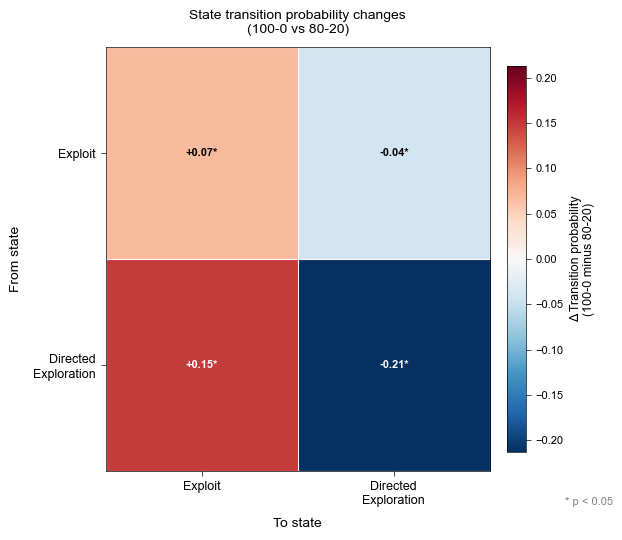

Saved Figure_8f_transition_heatmap.pdf and .png


In [185]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from scipy import stats

# States to include (excluding Adapting/Unknown for clarity)
STATES_PLOT = ['Exploit', 'Directed\nExploration', 
               'Left Bias', 'Right Bias']
STATES_KEY = ['Exploit', 'Directed Exploration',  
              'Left Bias', 'Right Bias']

STATES_PLOT = ['Exploit', 'Directed\nExploration']
STATES_KEY = ['Exploit', 'Directed Exploration']

# Build difference matrix and p-value matrix
n = len(STATES_KEY)
diff_matrix = np.full((n, n), np.nan)
pval_matrix = np.full((n, n), np.nan)
mean_80_matrix = np.full((n, n), np.nan)
mean_100_matrix = np.full((n, n), np.nan)

for i, from_state in enumerate(STATES_KEY):
    for j, to_state in enumerate(STATES_KEY):
        vals_80 = trans_df[
            (trans_df['condition']=='80-20') & 
            (trans_df['from_state']==from_state) & 
            (trans_df['to_state']==to_state)
        ].set_index('animal')['p_transition'].reindex(sorted(shared_animals))
        
        vals_100 = trans_df[
            (trans_df['condition']=='100-0') & 
            (trans_df['from_state']==from_state) & 
            (trans_df['to_state']==to_state)
        ].set_index('animal')['p_transition'].reindex(sorted(shared_animals))
        
        mask = vals_80.notna() & vals_100.notna()
        vals_80 = vals_80[mask].values
        vals_100 = vals_100[mask].values
        
        if len(vals_80) < 3:
            continue
        
        t, p = stats.ttest_rel(vals_80, vals_100)
        diff_matrix[i, j] = vals_100.mean() - vals_80.mean()
        pval_matrix[i, j] = p
        mean_80_matrix[i, j] = vals_80.mean()
        mean_100_matrix[i, j] = vals_100.mean()

# Plot
fig, ax = plt.subplots(figsize=(6.5, 5.5))

# Symmetric colormap centered at 0
vmax = np.nanmax(np.abs(diff_matrix))
im = ax.imshow(diff_matrix, cmap='RdBu_r', vmin=-vmax, vmax=vmax, aspect='auto')

# Colorbar
cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Δ Transition probability\n(100-0 minus 80-20)', fontsize=9)
cbar.ax.tick_params(labelsize=8)

# Significance asterisks and mean values
for i in range(n):
    for j in range(n):
        if np.isnan(diff_matrix[i, j]):
            ax.text(j, i, 'n.d.', ha='center', va='center', 
                   fontsize=7, color='gray')
            continue
        
        # Show difference value
        val_text = f'{diff_matrix[i,j]:+.2f}'
        sig = '*' if pval_matrix[i, j] < 0.05 else ''
        
        # Text color based on background
        text_color = 'white' if abs(diff_matrix[i,j]) > vmax*0.5 else 'black'
        
        ax.text(j, i, f'{val_text}{sig}', ha='center', va='center',
               fontsize=8, fontweight='bold' if sig else 'normal',
               color=text_color)

# Axes
ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(STATES_PLOT, fontsize=9)
ax.set_yticklabels(STATES_PLOT, fontsize=9)
ax.set_xlabel('To state', fontsize=10, labelpad=8)
ax.set_ylabel('From state', fontsize=10, labelpad=8)
ax.set_title('State transition probability changes\n(100-0 vs 80-20)', 
             fontsize=10, pad=10)

# Add grid lines
for i in range(n+1):
    ax.axhline(i-0.5, color='white', linewidth=0.8)
    ax.axvline(i-0.5, color='white', linewidth=0.8)

# Legend for asterisk
ax.text(1.32, -0.08, '* p < 0.05', transform=ax.transAxes, 
        fontsize=8, color='gray', ha='right')

plt.tight_layout()
plt.savefig('Figure_8f_transition_heatmap.pdf', bbox_inches='tight', dpi=300)
plt.savefig('Figure_8f_transition_heatmap.png', bbox_inches='tight', dpi=300)
plt.show()
print("Saved Figure_8f_transition_heatmap.pdf and .png")

In [186]:
print("="*70)
print("BIAS STATE CROSS-TRANSITIONS: RAW COUNTS PER ANIMAL")
print("="*70)

for label, df in [('80-20', df_80_corrected), ('100-0', df_100_corrected)]:
    df = df.copy()
    df = df.sort_values(['Animal_Name', 'Session_ID', 'Trial'])
    df['next_state'] = df.groupby(
        ['Animal_Name', 'Session_ID'])['Behavioral_State'].shift(-1)
    
    print(f"\n{label}:")
    for animal in sorted(shared_animals):
        adf = df[(df['Animal_Name'] == animal)].dropna(subset=['next_state'])
        
        lb_total = len(adf[adf['Behavioral_State'] == 'Left Bias'])
        rb_total = len(adf[adf['Behavioral_State'] == 'Right Bias'])
        
        lr = len(adf[(adf['Behavioral_State'] == 'Left Bias') & 
                     (adf['next_state'] == 'Right Bias')])
        rl = len(adf[(adf['Behavioral_State'] == 'Right Bias') & 
                     (adf['next_state'] == 'Left Bias')])
        
        print(f"  {animal:12s} | Left Bias total: {lb_total:4d} | "
              f"Right Bias total: {rb_total:4d} | "
              f"L→R: {lr:3d} | R→L: {rl:3d}")

BIAS STATE CROSS-TRANSITIONS: RAW COUNTS PER ANIMAL

80-20:
  Fiona        | Left Bias total:  246 | Right Bias total:  124 | L→R:   0 | R→L:   0
  Knuckles     | Left Bias total:  340 | Right Bias total:  443 | L→R:   0 | R→L:   0
  Sonic        | Left Bias total:  684 | Right Bias total:   93 | L→R:   0 | R→L:   0
  Sunflower    | Left Bias total:  176 | Right Bias total:  395 | L→R:   0 | R→L:   0
  Zazu         | Left Bias total:   83 | Right Bias total:  305 | L→R:   0 | R→L:   0

100-0:
  Fiona        | Left Bias total:  107 | Right Bias total:   95 | L→R:  22 | R→L:  26
  Knuckles     | Left Bias total:   99 | Right Bias total:   63 | L→R:   8 | R→L:  10
  Sonic        | Left Bias total:   47 | Right Bias total:   83 | L→R:  14 | R→L:  10
  Sunflower    | Left Bias total:  102 | Right Bias total:  118 | L→R:  20 | R→L:  23
  Zazu         | Left Bias total:  115 | Right Bias total:  124 | L→R:  27 | R→L:  24


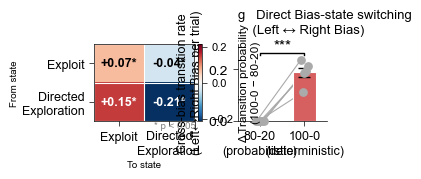


Paired t-test (cross-bias rate 80-20 vs 100-0): t=-8.841, p=0.0009
Mean cross-bias rate 80-20: 0.000 ± 0.000
Mean cross-bias rate 100-0: 0.188 ± 0.019


In [197]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from scipy import stats

# ── shared animals & states ──────────────────────────────────────────────────
SHARED_ANIMALS = ['Fiona', 'Knuckles', 'Sonic', 'Sunflower', 'Zazu']

STATES_KEY_MAIN  = ['Exploit', 'Directed Exploration']
STATES_PLOT_MAIN = ['Exploit', 'Directed\nExploration']

# ── colour palette (publication-style) ───────────────────────────────────────
COL_80  = '#4878CF'   # blue  – probabilistic
COL_100 = '#D65F5F'   # red   – deterministic
GREY    = '#AAAAAA'
FONTSIZE = 7
# ── Figure layout ─────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(3, 1))
gs  = fig.add_gridspec(1, 2, width_ratios=[1.1, 0.9], wspace=0.35)
ax_heat = fig.add_subplot(gs[0])
ax_bar  = fig.add_subplot(gs[1])

# ══════════════════════════════════════════════════════════════════════════════
# PANEL 8f – 3×3 difference heatmap (Exploit + Exploration only)
# ══════════════════════════════════════════════════════════════════════════════
n = len(STATES_KEY_MAIN)
diff_matrix  = np.full((n, n), np.nan)
pval_matrix  = np.full((n, n), np.nan)

for i, from_state in enumerate(STATES_KEY_MAIN):
    for j, to_state in enumerate(STATES_KEY_MAIN):
        v80 = (trans_df[(trans_df['condition']  == '80-20') &
                        (trans_df['from_state'] == from_state) &
                        (trans_df['to_state']   == to_state)]
               .set_index('animal')['p_transition']
               .reindex(SHARED_ANIMALS))
        v100 = (trans_df[(trans_df['condition']  == '100-0') &
                         (trans_df['from_state'] == from_state) &
                         (trans_df['to_state']   == to_state)]
                .set_index('animal')['p_transition']
                .reindex(SHARED_ANIMALS))

        mask = v80.notna() & v100.notna()
        v80, v100 = v80[mask].values, v100[mask].values
        if len(v80) < 3:
            continue

        t, p = stats.ttest_rel(v80, v100)
        diff_matrix[i, j] = v100.mean() - v80.mean()
        pval_matrix[i, j] = p

vmax = np.nanmax(np.abs(diff_matrix))
im   = ax_heat.imshow(diff_matrix, cmap='RdBu_r',
                      vmin=-vmax, vmax=vmax, aspect='auto')

cbar = plt.colorbar(im, ax=ax_heat, fraction=0.046, pad=0.04)
cbar.set_label('Δ Transition probability\n(100-0 − 80-20)', fontsize=8.5)
cbar.ax.tick_params(labelsize=8)

for i in range(n):
    for j in range(n):
        if np.isnan(diff_matrix[i, j]):
            continue
        sig  = '*' if pval_matrix[i, j] < 0.05 else ''
        tcol = 'white' if abs(diff_matrix[i, j]) > vmax * 0.55 else 'black'
        ax_heat.text(j, i,
                     f'{diff_matrix[i,j]:+.2f}{sig}',
                     ha='center', va='center', fontsize=9,
                     fontweight='bold' if sig else 'normal',
                     color=tcol)

for k in range(n + 1):
    ax_heat.axhline(k - 0.5, color='white', linewidth=0.8)
    ax_heat.axvline(k - 0.5, color='white', linewidth=0.8)

ax_heat.set_xticks(range(n))
ax_heat.set_yticks(range(n))
ax_heat.set_xticklabels(STATES_PLOT_MAIN, fontsize=9)
ax_heat.set_yticklabels(STATES_PLOT_MAIN, fontsize=9)
ax_heat.set_xlabel('To state',   fontsize=FONTSIZE, labelpad=2)
ax_heat.set_ylabel('From state', fontsize=FONTSIZE, labelpad=2)
# ax_heat.set_title('f   Transition probability changes\n    (Exploit & Exploration states)',
#                   fontsize=9.FONTSIZE, loc='left', pad=8)
ax_heat.text(n - 0.45, n - 0.3, '* p < 0.05',
             fontsize=FONTSIZE, color='gray', ha='right')

# ══════════════════════════════════════════════════════════════════════════════
# PANEL 8g – Bias cross-transition bar plot (per animal, paired)
# ══════════════════════════════════════════════════════════════════════════════
# Compute per-animal cross-transition RATES (L→R and R→L pooled)
cross_80  = []
cross_100 = []

for label, df, store in [('80-20',  df_80_corrected,  cross_80),
                          ('100-0',  df_100_corrected, cross_100)]:
    df = df.copy()
    df = df.sort_values(['Animal_Name', 'Session_ID', 'Trial'])
    df['next_state'] = (df.groupby(['Animal_Name', 'Session_ID'])
                          ['Behavioral_State'].shift(-1))

    for animal in SHARED_ANIMALS:
        adf = df[df['Animal_Name'] == animal].dropna(subset=['next_state'])

        lb_total = len(adf[adf['Behavioral_State'] == 'Left Bias'])
        rb_total = len(adf[adf['Behavioral_State'] == 'Right Bias'])
        total_bias = lb_total + rb_total

        lr = len(adf[(adf['Behavioral_State'] == 'Left Bias') &
                     (adf['next_state']        == 'Right Bias')])
        rl = len(adf[(adf['Behavioral_State'] == 'Right Bias') &
                     (adf['next_state']        == 'Left Bias')])

        rate = (lr + rl) / total_bias if total_bias > 0 else 0
        store.append(rate)

cross_80  = np.array(cross_80)
cross_100 = np.array(cross_100)

# paired t-test
t_cross, p_cross = stats.ttest_rel(cross_80, cross_100)

# bar positions
x     = np.array([0, 1])
means = [cross_80.mean(), cross_100.mean()]
sems  = [cross_80.std() / np.sqrt(len(cross_80)),
         cross_100.std() / np.sqrt(len(cross_100))]

bars = ax_bar.bar(x, means, width=0.5,
                  color=[COL_80, COL_100],
                  edgecolor='white', linewidth=0.8, zorder=2)
ax_bar.errorbar(x, means, yerr=sems,
                fmt='none', color='black', capsize=4, linewidth=1.2, zorder=3)

# individual animal lines
jitter = np.linspace(-0.08, 0.08, len(SHARED_ANIMALS))
for idx, animal in enumerate(SHARED_ANIMALS):
    ax_bar.plot([0 + jitter[idx], 1 + jitter[idx]],
                [cross_80[idx], cross_100[idx]],
                color=GREY, linewidth=0.8, zorder=1)
    ax_bar.scatter([0 + jitter[idx], 1 + jitter[idx]],
                   [cross_80[idx], cross_100[idx]],
                   color=GREY, s=28, zorder=4, clip_on=False)

# significance bracket
y_sig = max(cross_80.max(), cross_100.max()) + 0.02
ax_bar.plot([0, 0, 1, 1],
            [y_sig, y_sig + 0.005, y_sig + 0.005, y_sig],
            color='black', linewidth=1)
p_label = '***' if p_cross < 0.001 else ('**' if p_cross < 0.01 else
           ('*' if p_cross < 0.05 else 'n.s.'))
ax_bar.text(0.5, y_sig + 0.008, p_label,
            ha='center', va='bottom', fontsize=11)

ax_bar.set_xticks(x)
ax_bar.set_xticklabels(['80-20\n(probabilistic)', '100-0\n(deterministic)'],
                       fontsize=9)
ax_bar.set_ylabel('Cross-bias transition rate\n(Left↔Right Bias per trial)', fontsize=9)
ax_bar.set_xlim(-0.5, 1.5)
ax_bar.set_ylim(0, y_sig + 0.04)
ax_bar.spines['top'].set_visible(False)
ax_bar.spines['right'].set_visible(False)
ax_bar.set_title('g   Direct Bias-state switching\n    (Left ↔ Right Bias)',
                 fontsize=9.5, loc='left', pad=8)

plt.rcParams['svg.fonttype'] = 'none'

plt.savefig(os.path.join(FIGURE_PATH, 'Figure_8fg.svg'), bbox_inches='tight', dpi=300)
plt.savefig(os.path.join(FIGURE_PATH, 'Figure_8fg.png'), bbox_inches='tight', dpi=300)
plt.show()
print(f"\nPaired t-test (cross-bias rate 80-20 vs 100-0): t={t_cross:.3f}, p={p_cross:.4f}")
print(f"Mean cross-bias rate 80-20: {cross_80.mean():.3f} ± {cross_80.std()/np.sqrt(len(cross_80)):.3f}")
print(f"Mean cross-bias rate 100-0: {cross_100.mean():.3f} ± {cross_100.std()/np.sqrt(len(cross_100)):.3f}")

In [191]:
from scipy.optimize import curve_fit
from scipy.stats import ttest_rel, sem
from matplotlib.patches import Patch

FONTSIZE    = 7
LINE_WIDTH  = 1.0
TICK_LENGTH = 3
animals_ov  = [a for a in ANIMAL_ORDER if a in OVERLAP_ANIMALS]
PSYCH_ANIMAL = 'Sunflower'

fig = plt.figure(figsize=(7, 8))
gs  = gridspec.GridSpec(3, 4, figure=fig, hspace=0.5, wspace=0.45)

# ── ROW 1: Accuracy, β, κ, Trials-to-criterion ───────────────────────────────

# Panel A: Accuracy
ax_A = fig.add_subplot(gs[0, 0])
acc_80_ov  = (df_80_q[df_80_q['Animal_Name'].isin(OVERLAP_ANIMALS)]
              .groupby('Animal_Name')['High_Prob'].mean())
acc_100_ov = (df_100_q[df_100_q['Animal_Name'].isin(OVERLAP_ANIMALS)]
              .groupby('Animal_Name')['High_Prob'].mean())
v80  = np.array([acc_80_ov.loc[a]  for a in animals_ov])
v100 = np.array([acc_100_ov.loc[a] for a in animals_ov])

for animal, y0, y1 in zip(animals_ov, v80, v100):
    ax_A.plot([0,1],[y0,y1],'o-',color=ANIMAL_COLORS[animal],
              linewidth=1.2, markersize=5)
for x, vals in [(0,v80),(1,v100)]:
    ax_A.errorbar(x, vals.mean(), yerr=sem(vals), fmt='D',
                  color='black', markersize=6, capsize=3,
                  linewidth=LINE_WIDTH*1.5, zorder=5)
_, p = ttest_rel(v80, v100)
sig  = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'n.s.'
ymax = max(v80.max(), v100.max()) * 1.1
ax_A.plot([0,1],[ymax,ymax], color='black', lw=0.8)
ax_A.text(0.5, ymax*1.02, sig, ha='center', va='bottom', fontsize=FONTSIZE)
ax_A.axhline(0.5, color='gray', ls='--', lw=0.8, alpha=0.5)
ax_A.set_xticks([0,1])
ax_A.set_xticklabels(['80-20','100-0'], fontsize=FONTSIZE)
ax_A.set_ylabel('Mean accuracy', fontsize=FONTSIZE)
ax_A.set_xlim(-0.3, 1.3)
ax_A.set_ylim(0.4, ymax*1.1)
ax_A.set_title('A', fontsize=FONTSIZE, fontweight='bold', loc='left')
ax_A.spines[['top','right']].set_visible(False)
ax_A.tick_params(labelsize=FONTSIZE, length=TICK_LENGTH)

# Panel B: β
ax_B = fig.add_subplot(gs[0, 1])
v80  = params_80_ov['beta'].values
v100 = params_100_ov['beta'].values
for animal, y0, y1 in zip(animals_ov, v80, v100):
    ax_B.plot([0,1],[y0,y1],'o-',color=ANIMAL_COLORS[animal],
              linewidth=1.2, markersize=5)
for x, vals in [(0,v80),(1,v100)]:
    ax_B.errorbar(x, vals.mean(), yerr=sem(vals), fmt='D',
                  color='black', markersize=6, capsize=3,
                  linewidth=LINE_WIDTH*1.5, zorder=5)
_, p = ttest_rel(v80, v100)
sig  = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'n.s.'
ymax = max(v80.max(), v100.max()) * 1.15
ax_B.plot([0,1],[ymax,ymax], color='black', lw=0.8)
ax_B.text(0.5, ymax*1.02, sig, ha='center', va='bottom', fontsize=FONTSIZE)
ax_B.set_xticks([0,1])
ax_B.set_xticklabels(['80-20','100-0'], fontsize=FONTSIZE)
ax_B.set_ylabel('β (inverse temperature)', fontsize=FONTSIZE)
ax_B.set_xlim(-0.3, 1.3)
ax_B.set_ylim(bottom=0)
ax_B.set_title('B', fontsize=FONTSIZE, fontweight='bold', loc='left')
ax_B.spines[['top','right']].set_visible(False)
ax_B.tick_params(labelsize=FONTSIZE, length=TICK_LENGTH)

# Panel C: κ
ax_C = fig.add_subplot(gs[0, 2])
v80  = params_80_ov['kappa'].values
v100 = params_100_ov['kappa'].values
for animal, y0, y1 in zip(animals_ov, v80, v100):
    ax_C.plot([0,1],[y0,y1],'o-',color=ANIMAL_COLORS[animal],
              linewidth=1.2, markersize=5)
for x, vals in [(0,v80),(1,v100)]:
    ax_C.errorbar(x, vals.mean(), yerr=sem(vals), fmt='D',
                  color='black', markersize=6, capsize=3,
                  linewidth=LINE_WIDTH*1.5, zorder=5)
_, p = ttest_rel(v80, v100)
sig  = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'n.s.'
ymax = max(v80.max(), v100.max()) * 1.15
ax_C.plot([0,1],[ymax,ymax], color='black', lw=0.8)
ax_C.text(0.5, ymax*1.02, sig, ha='center', va='bottom', fontsize=FONTSIZE)
ax_C.set_xticks([0,1])
ax_C.set_xticklabels(['80-20','100-0'], fontsize=FONTSIZE)
ax_C.set_ylabel('κ (stickiness)', fontsize=FONTSIZE)
ax_C.set_xlim(-0.3, 1.3)
ax_C.set_ylim(bottom=0)
ax_C.set_title('C', fontsize=FONTSIZE, fontweight='bold', loc='left')
ax_C.spines[['top','right']].set_visible(False)
ax_C.tick_params(labelsize=FONTSIZE, length=TICK_LENGTH)

# Panel D: Trials to criterion
ax_D = fig.add_subplot(gs[0, 3])
v80  = np.array([ttc_80.loc[a]  if a in ttc_80.index  else np.nan
                 for a in animals_ov])
v100 = np.array([ttc_100.loc[a] if a in ttc_100.index else np.nan
                 for a in animals_ov])
mask = ~(np.isnan(v80) | np.isnan(v100))
for animal, y0, y1 in zip(np.array(animals_ov)[mask],
                           v80[mask], v100[mask]):
    ax_D.plot([0,1],[y0,y1],'o-',color=ANIMAL_COLORS[animal],
              linewidth=1.2, markersize=5)
for x, vals in [(0,v80[mask]),(1,v100[mask])]:
    ax_D.errorbar(x, vals.mean(), yerr=sem(vals), fmt='D',
                  color='black', markersize=6, capsize=3,
                  linewidth=LINE_WIDTH*1.5, zorder=5)
_, p = ttest_rel(v80[mask], v100[mask])
sig  = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'n.s.'
ymax = np.nanmax([v80, v100]) * 1.15
ax_D.plot([0,1],[ymax,ymax], color='black', lw=0.8)
ax_D.text(0.5, ymax*1.02, sig, ha='center', va='bottom', fontsize=FONTSIZE)
ax_D.set_xticks([0,1])
ax_D.set_xticklabels(['80-20','100-0'], fontsize=FONTSIZE)
ax_D.set_ylabel('Trials to criterion', fontsize=FONTSIZE)
ax_D.set_xlim(-0.3, 1.3)
ax_D.set_ylim(bottom=0)
ax_D.set_title('D', fontsize=FONTSIZE, fontweight='bold', loc='left')
ax_D.spines[['top','right']].set_visible(False)
ax_D.tick_params(labelsize=FONTSIZE, length=TICK_LENGTH)

# ── ROW 2: State occupancy + accuracy and switch rate by trial within block ───

# Panel E: State occupancy
ax_E = fig.add_subplot(gs[1, 0:2])
x     = np.arange(len(STATES_ORDERED))
width = 0.35
for i, state in enumerate(STATES_ORDERED):
    ax_E.bar(i - width/2, state_occ_80[state],  width,
             color=state_colors[state], alpha=0.9,
             edgecolor='black', linewidth=LINE_WIDTH)
    ax_E.bar(i + width/2, state_occ_100[state], width,
             color='white', edgecolor=state_colors[state], linewidth=1.5)
ax_E.set_xticks(x)
ax_E.set_xticklabels(STATES_ORDERED, rotation=30, ha='right', fontsize=FONTSIZE)
ax_E.set_ylabel('Occupancy (%)', fontsize=FONTSIZE)
ax_E.set_title('E  Behavioral state occupancy',
               fontsize=FONTSIZE, fontweight='bold', loc='left')
ax_E.legend([Patch(facecolor='gray', alpha=0.9, edgecolor='black'),
             Patch(facecolor='white', edgecolor='gray', linewidth=1.5)],
            ['80-20','100-0'], fontsize=FONTSIZE-1, frameon=False)
ax_E.spines[['top','right']].set_visible(False)
ax_E.tick_params(labelsize=FONTSIZE, length=TICK_LENGTH)

# Panel F: Accuracy by trial within block
ax_F = fig.add_subplot(gs[1, 2])
for df_cond, color, label in [
    (df_80_q,  COLOR_80_20, '80-20'),
    (df_100_q, COLOR_100_0, '100-0'),
]:
    grouped = (df_cond.groupby('TrialWithinBlock')['High_Prob']
               .agg(['mean','count',sem]).reset_index())
    grouped = grouped[grouped['count'] >= 10]
    ax_F.plot(grouped['TrialWithinBlock'], grouped['mean'],
              '-', color=color, linewidth=1.5, label=label)
    ax_F.fill_between(grouped['TrialWithinBlock'],
                      grouped['mean'] - grouped['sem'],
                      grouped['mean'] + grouped['sem'],
                      color=color, alpha=0.2)
ax_F.axhline(0.5, color='gray', ls='--', lw=0.8, alpha=0.5)
ax_F.axhline(0.8, color=COLOR_80_20, ls=':', lw=1.0, alpha=0.4)
ax_F.axhline(1.0, color=COLOR_100_0, ls=':', lw=1.0, alpha=0.4)
ax_F.set_xlabel('Trial within block', fontsize=FONTSIZE)
ax_F.set_ylabel('P(high-prob port)', fontsize=FONTSIZE)
ax_F.set_title('F', fontsize=FONTSIZE, fontweight='bold', loc='left')
ax_F.set_ylim(0, 1)
ax_F.set_xlim(1, 20)
ax_F.legend(fontsize=FONTSIZE-1, frameon=False)
ax_F.spines[['top','right']].set_visible(False)
ax_F.tick_params(labelsize=FONTSIZE, length=TICK_LENGTH)

# Panel G: Switch rate by trial within block
ax_G2 = fig.add_subplot(gs[1, 3])
for df_cond, color, label in [
    (df_80_q,  COLOR_80_20, '80-20'),
    (df_100_q, COLOR_100_0, '100-0'),
]:
    grouped = (df_cond.groupby('TrialWithinBlock')['PhysicalSwitch']
               .agg(['mean','count',sem]).reset_index())
    grouped = grouped[grouped['count'] >= 10]
    ax_G2.plot(grouped['TrialWithinBlock'], grouped['mean'],
               '-', color=color, linewidth=1.5, label=label)
    ax_G2.fill_between(grouped['TrialWithinBlock'],
                       grouped['mean'] - grouped['sem'],
                       grouped['mean'] + grouped['sem'],
                       color=color, alpha=0.2)
ax_G2.set_xlabel('Trial within block', fontsize=FONTSIZE)
ax_G2.set_ylabel('Switch rate', fontsize=FONTSIZE)
ax_G2.set_title('G', fontsize=FONTSIZE, fontweight='bold', loc='left')
ax_G2.set_ylim(0, 0.55)
ax_G2.set_xlim(1, 20)
ax_G2.legend(fontsize=FONTSIZE-1, frameon=False)
ax_G2.spines[['top','right']].set_visible(False)
ax_G2.tick_params(labelsize=FONTSIZE, length=TICK_LENGTH)

# ── ROW 3: Psychometric curve + sensitivity + bias ───────────────────────────
ax_H = fig.add_subplot(gs[2, 0:2])
ax_H.set_title(f'H  Psychometric curves ({PSYCH_ANIMAL})',
               fontsize=FONTSIZE, fontweight='bold', loc='left')
for df_cond, color, label, cond_key in [
    (df_80_q,  COLOR_80_20, '80-20', '80'),
    (df_100_q, COLOR_100_0, '100-0', '100'),
]:
    df_a = df_cond[df_cond['Animal_Name'] == PSYCH_ANIMAL].copy()
    df_a = df_a.dropna(subset=['Q_right','Q_left','Choice_Binary'])
    df_a['delta_Q'] = np.clip(df_a['Q_right'] - df_a['Q_left'], -2, 2)
    bins = np.linspace(-2, 2, 13)
    df_a['bin'] = pd.cut(df_a['delta_Q'], bins=bins,
                          labels=(bins[:-1]+bins[1:])/2)
    binned = (df_a.groupby('bin', observed=True)['Choice_Binary']
              .agg(['mean','count']).reset_index())
    binned = binned[binned['count'] >= 10]
    binned['bin'] = binned['bin'].astype(float)
    ax_H.scatter(binned['bin'], binned['mean'], color=color,
                 s=20, alpha=0.7, edgecolors='white', linewidths=0.4, zorder=4)
    x0, k = animal_psych_params[PSYCH_ANIMAL][cond_key]
    if not np.isnan(k):
        x_sm = np.linspace(-2, 2, 200)
        ax_H.plot(x_sm, sigmoid_2param(x_sm, x0, k), color=color,
                  linewidth=1.5, label=f'{label}  β={k:.2f}')
ax_H.axhline(0.5, color='gray', ls='--', lw=0.8, alpha=0.5)
ax_H.axvline(0.0, color='gray', ls='--', lw=0.8, alpha=0.5)
ax_H.set_xlabel('Q_right − Q_left', fontsize=FONTSIZE)
ax_H.set_ylabel('P(choose right)', fontsize=FONTSIZE)
ax_H.set_xlim(-2, 2)
ax_H.set_ylim(0, 1)
ax_H.legend(fontsize=FONTSIZE-1, frameon=False)
ax_H.spines[['top','right']].set_visible(False)
ax_H.tick_params(labelsize=FONTSIZE, length=TICK_LENGTH)

# Panels I & J: Sensitivity and Bias
for ax_panel, param_idx, ylabel, title, col in [
    (fig.add_subplot(gs[2, 2]), 1, 'Sensitivity (β)', 'I  Sensitivity', 2),
    (fig.add_subplot(gs[2, 3]), 0, '|Bias| (|x₀|)',   'J  |Bias|',      3),
]:
    x_pos = np.arange(len(animals_ov))
    for xi, animal in enumerate(animals_ov):
        color = ANIMAL_COLORS.get(animal, 'gray')
        v80  = animal_psych_params[animal]['80'][param_idx]
        v100 = animal_psych_params[animal]['100'][param_idx]
        if param_idx == 0:
            v80  = abs(v80)  if not np.isnan(v80)  else np.nan
            v100 = abs(v100) if not np.isnan(v100) else np.nan
        ax_panel.bar(xi - width/2, v80,  width, color=color,
                     alpha=0.9, edgecolor='black', linewidth=LINE_WIDTH)
        ax_panel.bar(xi + width/2, v100, width, color='white',
                     edgecolor=color, linewidth=1.5)
    ax_panel.set_xticks(x_pos)
    ax_panel.set_xticklabels(animals_ov, rotation=45, ha='right',
                              fontsize=FONTSIZE-1)
    ax_panel.set_ylabel(ylabel, fontsize=FONTSIZE)
    ax_panel.set_title(title, fontsize=FONTSIZE, fontweight='bold', loc='left')
    ax_panel.set_ylim(bottom=0)
    ax_panel.spines[['top','right']].set_visible(False)
    ax_panel.tick_params(labelsize=FONTSIZE, length=TICK_LENGTH)

# ── Legend ────────────────────────────────────────────────────────────────────
handles = [plt.scatter([], [], color=ANIMAL_COLORS[a], s=25,
                       edgecolor='black', linewidth=0.4, label=a)
           for a in animals_ov]
fig.legend(handles=handles, loc='lower center', ncol=5,
           frameon=False, fontsize=FONTSIZE,
           bbox_to_anchor=(0.5, -0.02))


plt.savefig(os.path.join(FIGURE_PATH, 'main_figure_cross_prob_v3.svg'), dpi=300, bbox_inches='tight')
print("✓ Saved main_figure_cross_prob_v3.svg")
plt.show()

NameError: name 'OVERLAP_ANIMALS' is not defined

In [130]:
# ── Run adaptation analysis for both conditions ───────────────────────────────
def get_adaptation_df(df, session_col='Session_ID'):
    records = []
    for (animal, session), grp in df.groupby(['Animal_Name', session_col]):
        grp = grp.sort_values('Trial').reset_index(drop=True)
        block_ids = sorted(grp['BlockCount'].unique())
        
        for i, bid in enumerate(block_ids[1:], 1):
            block_data = grp[grp['BlockCount'] == bid].sort_values('Trial')
            
            post_rev = block_data[block_data['Trials_Since_Transition'] <= 5]
            if len(post_rev) < 3:
                continue
            
            adaptation_accuracy = post_rev['High_Prob'].mean()
            
            stable_window = block_data[
                (block_data['Trials_Since_Transition'] > 5) &
                (block_data['Trials_Since_Transition'] <= 10)
            ]
            if len(stable_window) < 3:
                continue
            
            stable_state = stable_window['Behavioral_State'].mode().iloc[0]
            
            records.append({
                'animal':         animal,
                'session':        session,
                'block':          bid,
                'adaptation_acc': adaptation_accuracy,
                'stable_state':   stable_state,
                'n_post_rev':     len(post_rev),
                'n_stable':       len(stable_window),
            })
    
    df_out = pd.DataFrame(records)
    median_acc = df_out['adaptation_acc'].median()
    df_out['adaptation_speed'] = np.where(
        df_out['adaptation_acc'] >= median_acc, 'Fast', 'Slow'
    )
    return df_out

adaptation_80  = get_adaptation_df(df_80_q,  session_col='Session_ID')
adaptation_100 = get_adaptation_df(df_100_q, session_col='Fit_Session_ID')

for label, adf in [('80-20', adaptation_80), ('100-0', adaptation_100)]:
    print(f"\n{label}:")
    print(f"  Total blocks: {len(adf)}, "
          f"median acc: {adf['adaptation_acc'].median():.3f}")
    print(f"  Fast stable states:")
    fast = adf[adf['adaptation_speed']=='Fast']['stable_state'].value_counts(normalize=True)
    print(fast.round(3).to_string())
    print(f"  Slow stable states:")
    slow = adf[adf['adaptation_speed']=='Slow']['stable_state'].value_counts(normalize=True)
    print(slow.round(3).to_string())


80-20:
  Total blocks: 1740, median acc: 0.500
  Fast stable states:
stable_state
Engaged                 0.661
Directed Exploration    0.285
Random Exploration      0.028
Left Bias               0.014
Right Bias              0.012
  Slow stable states:
stable_state
Directed Exploration    0.483
Engaged                 0.201
Right Bias              0.140
Left Bias               0.129
Random Exploration      0.047

100-0:
  Total blocks: 440, median acc: 0.667
  Fast stable states:
stable_state
Engaged                 0.855
Right Bias              0.055
Directed Exploration    0.055
Left Bias               0.034
  Slow stable states:
stable_state
Engaged                 0.746
Directed Exploration    0.098
Right Bias              0.088
Left Bias               0.068


In [132]:
def get_reversal_aligned_highprob(df, window_before=5, window_after=15):
    all_aligned = []
    for session_id in df['Session_ID'].unique():
        session_data = df[df['Session_ID'] == session_id].reset_index(drop=True).copy()
        reversals = session_data[session_data['Block_Transition'] == 1].index.tolist()
        
        if len(reversals) > 0 and reversals[0] < window_before:
            reversals = reversals[1:]
        
        for rev_idx in reversals:
            start = rev_idx - window_before
            end   = min(rev_idx + window_after, len(session_data))
            if start >= 0 and (end - rev_idx) >= 10:
                block_window = session_data.iloc[start:end].copy()
                block_window['Trial_Relative'] = np.arange(len(block_window)) - window_before
                all_aligned.append(block_window[['Trial_Relative', 'High_Prob']])
    
    return pd.concat(all_aligned) if all_aligned else None

highprob_80_aligned  = get_reversal_aligned_highprob(df_80_q)
highprob_100_aligned = get_reversal_aligned_highprob(df_100_q)

print(f"High prob aligned — 80-20: {len(highprob_80_aligned):,} trials")
print(f"High prob aligned — 100-0: {len(highprob_100_aligned):,} trials")

High prob aligned — 80-20: 34,645 trials
High prob aligned — 100-0: 5,432 trials


In [136]:
wslr_80

,WinStay,LoseSwitch
Animal_Name,,
Fiona,0.917787,0.272486
Knuckles,0.900365,0.368395
Sonic,0.914934,0.282294
Sunflower,0.890162,0.445076
Zazu,0.887254,0.273279


In [147]:
animals_ov

['Fiona', 'Knuckles', 'Sonic', 'Zazu', 'Sunflower']

✓ Saved main_figure_cross_prob_final.svg


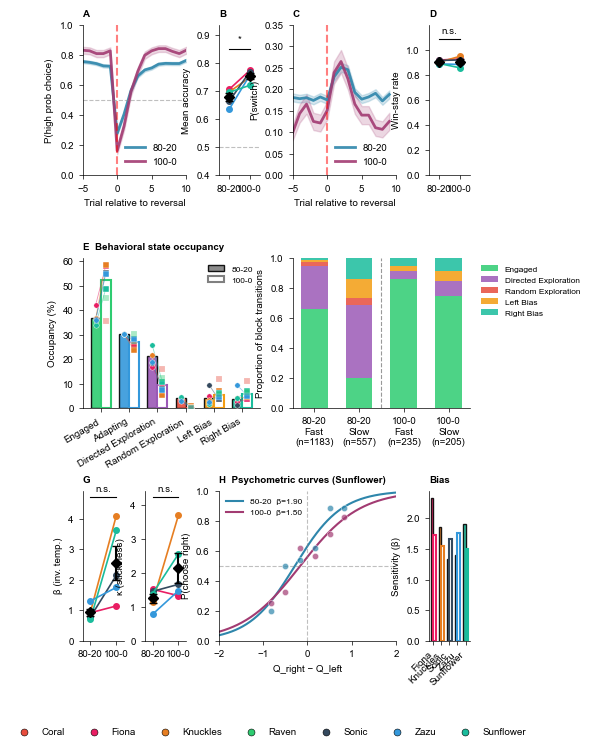

In [193]:
from matplotlib.patches import Patch
from scipy.optimize import curve_fit

# set all the axes and tick width to 0.5
plt.rcParams['axes.linewidth'] = 0.5
plt.rcParams['xtick.major.width'] = 0.5
plt.rcParams['ytick.major.width'] = 0.5

FONTSIZE    = 7
LINE_WIDTH  = 1.0
TICK_LENGTH = 3
PSYCH_ANIMAL = 'Sunflower'
animals_ov   = [a for a in ANIMAL_ORDER if a in OVERLAP_ANIMALS]

fig = plt.figure(figsize=(5, 8))
gs  = gridspec.GridSpec(3, 4, figure=fig, hspace=0.55, wspace=0.45,
                         width_ratios=[1, 0.4, 1, 0.4])

# ── ROW 1 ─────────────────────────────────────────────────────────────────────

# Panel A: Reversal-aligned P(high prob)
ax_A = fig.add_subplot(gs[0, 0])
for aligned, color, label in [
    (highprob_80_aligned,  COLOR_80_20, '80-20'),
    (highprob_100_aligned, COLOR_100_0, '100-0'),
]:
    grouped = aligned.groupby('Trial_Relative')['High_Prob'].agg(['mean', sem])
    ax_A.plot(grouped.index, grouped['mean'], '-',
              color=color, linewidth=2.0, alpha=0.9, label=label)
    ax_A.fill_between(grouped.index,
                      grouped['mean'] - grouped['sem'],
                      grouped['mean'] + grouped['sem'],
                      color=color, alpha=0.2)
ax_A.axvline(0, color='red', ls='--', lw=1.5, alpha=0.5)
ax_A.axhline(0.5, color='gray', ls='--', lw=0.8, alpha=0.5)
ax_A.set_xlabel('Trial relative to reversal', fontsize=FONTSIZE)
ax_A.set_ylabel('P(high prob choice)', fontsize=FONTSIZE)
ax_A.set_xlim(-5, 10)
ax_A.set_ylim(0, 1)
ax_A.set_title('A', fontsize=FONTSIZE, fontweight='bold', loc='left')
ax_A.legend(frameon=False, fontsize=FONTSIZE)
ax_A.spines[['top','right']].set_visible(False)
ax_A.tick_params(labelsize=FONTSIZE, length=TICK_LENGTH)

# Panel B: Accuracy paired plot
ax_B = fig.add_subplot(gs[0, 1])
acc_80_ov  = (df_80_q[df_80_q['Animal_Name'].isin(OVERLAP_ANIMALS)]
              .groupby('Animal_Name')['High_Prob'].mean())
acc_100_ov = (df_100_q[df_100_q['Animal_Name'].isin(OVERLAP_ANIMALS)]
              .groupby('Animal_Name')['High_Prob'].mean())
v80  = np.array([acc_80_ov.loc[a]  for a in animals_ov])
v100 = np.array([acc_100_ov.loc[a] for a in animals_ov])
for animal, y0, y1 in zip(animals_ov, v80, v100):
    ax_B.plot([0,1],[y0,y1],'o-',color=ANIMAL_COLORS[animal],
              linewidth=1.2, markersize=4)
for x, vals in [(0,v80),(1,v100)]:
    ax_B.errorbar(x, vals.mean(), yerr=sem(vals), fmt='D',
                  color='black', markersize=5, capsize=3,
                  linewidth=LINE_WIDTH*1.5, zorder=5)
_, p = ttest_rel(v80, v100)
sig  = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'n.s.'
ymax = max(v80.max(), v100.max()) * 1.1
ax_B.plot([0,1],[ymax,ymax], color='black', lw=0.8)
ax_B.text(0.5, ymax*1.02, sig, ha='center', va='bottom', fontsize=FONTSIZE)
ax_B.axhline(0.5, color='gray', ls='--', lw=0.8, alpha=0.5)
ax_B.set_xticks([0,1])
ax_B.set_xticklabels(['80-20','100-0'], fontsize=FONTSIZE)
ax_B.set_ylabel('Mean accuracy', fontsize=FONTSIZE)
ax_B.set_xlim(-0.5, 1.5)
ax_B.set_ylim(0.4, ymax*1.1)
ax_B.set_title('B', fontsize=FONTSIZE, fontweight='bold', loc='left')
ax_B.spines[['top','right']].set_visible(False)
ax_B.tick_params(labelsize=FONTSIZE, length=TICK_LENGTH)

# Panel C: Reversal-aligned switch rate
ax_C = fig.add_subplot(gs[0, 2])
for aligned, color, label in [
    (switching_80_aligned,  COLOR_80_20, '80-20'),
    (switching_100_aligned, COLOR_100_0, '100-0'),
]:
    grouped = aligned.groupby('Trial_Relative')['Switched'].agg(['mean', sem])
    ax_C.plot(grouped.index, grouped['mean'], '-',
              color=color, linewidth=2.0, alpha=0.9, label=label)
    ax_C.fill_between(grouped.index,
                      grouped['mean'] - grouped['sem'],
                      grouped['mean'] + grouped['sem'],
                      color=color, alpha=0.2)
ax_C.axvline(0, color='red', ls='--', lw=1.5, alpha=0.5)
ax_C.set_xlabel('Trial relative to reversal', fontsize=FONTSIZE)
ax_C.set_ylabel('P(switch)', fontsize=FONTSIZE)
ax_C.set_xlim(-5, 10)
ax_C.set_ylim(0, 0.35)
ax_C.set_title('C', fontsize=FONTSIZE, fontweight='bold', loc='left')
ax_C.legend(frameon=False, fontsize=FONTSIZE)
ax_C.spines[['top','right']].set_visible(False)
ax_C.tick_params(labelsize=FONTSIZE, length=TICK_LENGTH)

# Panel D: Lose-switch paired plot
# ax_D = fig.add_subplot(gs[0, 3])
# v80  = np.array([wslr_80.loc[a,  'LoseSwitch'] for a in animals_ov
#                  if a in wslr_80.index])
# v100 = np.array([wslr_100.loc[a, 'LoseSwitch'] for a in animals_ov
#                  if a in wslr_100.index])
# for animal, y0, y1 in zip(animals_ov, v80, v100):
#     ax_D.plot([0,1],[y0,y1],'o-',color=ANIMAL_COLORS[animal],
#               linewidth=1.2, markersize=4)
# for x, vals in [(0,v80),(1,v100)]:
#     ax_D.errorbar(x, vals.mean(), yerr=sem(vals), fmt='D',
#                   color='black', markersize=5, capsize=3,
#                   linewidth=LINE_WIDTH*1.5, zorder=5)
# _, p = ttest_rel(v80, v100)
# sig  = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'n.s.'
# ymax = max(v80.max(), v100.max()) * 1.15
# ax_D.plot([0,1],[ymax,ymax], color='black', lw=0.8)
# ax_D.text(0.5, ymax*1.02, sig, ha='center', va='bottom', fontsize=FONTSIZE)
# ax_D.set_xticks([0,1])
# ax_D.set_xticklabels(['80-20','100-0'], fontsize=FONTSIZE)
# ax_D.set_ylabel('Lose-switch rate', fontsize=FONTSIZE)
# ax_D.set_xlim(-0.5, 1.5)
# ax_D.set_ylim(0, ymax*1.1)
# ax_D.set_title('D', fontsize=FONTSIZE, fontweight='bold', loc='left')
# ax_D.spines[['top','right']].set_visible(False)
# ax_D.tick_params(labelsize=FONTSIZE, length=TICK_LENGTH)

ax_D = fig.add_subplot(gs[0, 3])
v80  = np.array([wslr_80.loc[a,  'WinStay'] for a in animals_ov
                 if a in wslr_80.index])
v100 = np.array([wslr_100.loc[a, 'WinStay'] for a in animals_ov
                 if a in wslr_100.index])
for animal, y0, y1 in zip(animals_ov, v80, v100):
    ax_D.plot([0,1],[y0,y1],'o-',color=ANIMAL_COLORS[animal],
              linewidth=1.2, markersize=4)
for x, vals in [(0,v80),(1,v100)]:
    ax_D.errorbar(x, vals.mean(), yerr=sem(vals), fmt='D',
                  color='black', markersize=5, capsize=3,
                  linewidth=LINE_WIDTH*1.5, zorder=5)
_, p = ttest_rel(v80, v100)
sig  = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'n.s.'
ymax = max(v80.max(), v100.max()) * 1.15
ax_D.plot([0,1],[ymax,ymax], color='black', lw=0.8)
ax_D.text(0.5, ymax*1.02, sig, ha='center', va='bottom', fontsize=FONTSIZE)
ax_D.set_xticks([0,1])
ax_D.set_xticklabels(['80-20','100-0'], fontsize=FONTSIZE)
ax_D.set_ylabel('Win-stay rate', fontsize=FONTSIZE)
ax_D.set_xlim(-0.5, 1.5)
ax_D.set_ylim(0, ymax*1.1)
ax_D.set_title('D', fontsize=FONTSIZE, fontweight='bold', loc='left')
ax_D.spines[['top','right']].set_visible(False)
ax_D.tick_params(labelsize=FONTSIZE, length=TICK_LENGTH)

# ── ROW 2 ─────────────────────────────────────────────────────────────────────

# Panel E: Behavioral state comparison with individual animal dots
ax_E = fig.add_subplot(gs[1, 0:2])
x     = np.arange(len(STATES_ORDERED))
width = 0.35

for i, state in enumerate(STATES_ORDERED):
    # Bars
    ax_E.bar(i - width/2, state_occ_80[state], width,
             color=state_colors[state], alpha=0.9,
             edgecolor='black', linewidth=LINE_WIDTH)
    ax_E.bar(i + width/2, state_occ_100[state], width,
             color='white', edgecolor=state_colors[state], linewidth=1.5)

    # Paired animals — connected dots
    for animal in OVERLAPPING_ANIMALS:
        if animal in props_80.index and animal in props_100.index:
            v80  = props_80.loc[animal, state]  * 100
            v100 = props_100.loc[animal, state] * 100
            # Connection line
            ax_E.plot([i - width/2, i + width/2], [v80, v100],
                      color=ANIMAL_COLORS[animal], lw=0.6,
                      alpha=0.5, zorder=4)
            ax_E.scatter(i - width/2, v80,
                         color=ANIMAL_COLORS[animal], s=15,
                         zorder=5, edgecolor='white', linewidth=0.3)
            ax_E.scatter(i + width/2, v100,
                         color=ANIMAL_COLORS[animal], s=15,
                         marker='s', zorder=5,
                         edgecolor='white', linewidth=0.3)

    # Unpaired 100-0 animals — standalone dots, lower alpha
    for animal in UNPAIRED_100:
        if animal in props_100.index:
            v100 = props_100.loc[animal, state] * 100
            ax_E.scatter(i + width/2, v100,
                         color=ANIMAL_COLORS[animal], s=15,
                         marker='s', zorder=5, alpha=0.4,
                         edgecolor='white', linewidth=0.3)

ax_E.set_xticks(x)
ax_E.set_xticklabels(STATES_ORDERED, rotation=30, ha='right', fontsize=FONTSIZE)
ax_E.set_ylabel('Occupancy (%)', fontsize=FONTSIZE)
ax_E.set_title('E  Behavioral state occupancy',
               fontsize=FONTSIZE, fontweight='bold', loc='left')
ax_E.legend([Patch(facecolor='gray', alpha=0.9, edgecolor='black'),
             Patch(facecolor='white', edgecolor='gray', linewidth=1.5)],
            ['80-20','100-0'], fontsize=FONTSIZE-1, frameon=False)
ax_E.spines[['top','right']].set_visible(False)
ax_E.tick_params(labelsize=FONTSIZE, length=TICK_LENGTH)

# Replace Panel F with stacked bar style
ax_F = fig.add_subplot(gs[1, 2:4])


states_order = ['Engaged', 'Directed Exploration',
                'Random Exploration', 'Left Bias', 'Right Bias']

# Build data for 4 groups
groups = [
    ('80-20\nFast', adaptation_80,  'Fast'),
    ('80-20\nSlow', adaptation_80,  'Slow'),
    ('100-0\nFast', adaptation_100, 'Fast'),
    ('100-0\nSlow', adaptation_100, 'Slow'),
]

group_labels = []
group_ns     = []
plot_data    = []

for label, adf, speed in groups:
    sdf   = adf[adf['adaptation_speed'] == speed]
    props = sdf['stable_state'].value_counts(normalize=True)
    plot_data.append({s: props.get(s, 0) for s in states_order})
    group_labels.append(label)
    group_ns.append(len(sdf))

x_pos   = np.arange(len(groups))
bottoms = np.zeros(len(groups))

for state in states_order:
    vals = [plot_data[i][state] for i in range(len(groups))]
    ax_F.bar(x_pos, vals, bottom=bottoms,
             color=state_colors[state], alpha=0.85,
             edgecolor='none', width=0.6, label=state)
    bottoms += np.array(vals)

# Divider between conditions
ax_F.axvline(1.5, color='black', lw=0.8, ls='--', alpha=0.4)

ax_F.set_xticks(x_pos)
ax_F.set_xticklabels(
    [f'{l}\n(n={n})' for l, n in zip(group_labels, group_ns)],
    fontsize=FONTSIZE
)
ax_F.set_ylabel('Proportion of block transitions', fontsize=FONTSIZE)
ax_F.set_ylim(0, 1)
ax_F.spines[['top','right']].set_visible(False)
ax_F.tick_params(labelsize=FONTSIZE, length=TICK_LENGTH)
ax_F.legend(fontsize=FONTSIZE-1, frameon=False,
            loc='upper left', bbox_to_anchor=(1.02, 1.0), ncol=1)

# ── ROW 3 ─────────────────────────────────────────────────────────────────────

# Panel G: β and κ paired (side by side in one subplot area)
gs_G = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=gs[2, 0],
                                         wspace=0.5)
for i, (param, ylabel) in enumerate([('beta',  'β (inv. temp.)'),
                                       ('kappa', 'κ (stickiness)')]):
    ax = fig.add_subplot(gs_G[i])
    v80  = params_80_ov[param].values
    v100 = params_100_ov[param].values
    for animal, y0, y1 in zip(animals_ov, v80, v100):
        ax.plot([0,1],[y0,y1],'o-',color=ANIMAL_COLORS[animal],
                linewidth=1.2, markersize=4)
    for x, vals in [(0,v80),(1,v100)]:
        ax.errorbar(x, vals.mean(), yerr=sem(vals), fmt='D',
                    color='black', markersize=5, capsize=3,
                    linewidth=LINE_WIDTH*1.5, zorder=5)
    _, p = ttest_rel(v80, v100)
    sig  = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'n.s.'
    ymax = max(v80.max(), v100.max()) * 1.15
    ax.plot([0,1],[ymax,ymax], color='black', lw=0.8)
    ax.text(0.5, ymax*1.02, sig, ha='center', va='bottom', fontsize=FONTSIZE)
    ax.set_xticks([0,1])
    ax.set_xticklabels(['80-20','100-0'], fontsize=FONTSIZE)
    ax.set_ylabel(ylabel, fontsize=FONTSIZE)
    ax.set_xlim(-0.3, 1.3)
    ax.set_ylim(bottom=0)
    ax.set_title('G' if i==0 else '', fontsize=FONTSIZE,
                 fontweight='bold', loc='left')
    ax.spines[['top','right']].set_visible(False)
    ax.tick_params(labelsize=FONTSIZE, length=TICK_LENGTH)

# Panel H: Psychometric curve
ax_H = fig.add_subplot(gs[2, 1:3])
ax_H.set_title(f'H  Psychometric curves ({PSYCH_ANIMAL})',
               fontsize=FONTSIZE, fontweight='bold', loc='left')
for df_cond, color, label, cond_key in [
    (df_80_q,  COLOR_80_20, '80-20', '80'),
    (df_100_q, COLOR_100_0, '100-0', '100'),
]:
    df_a = df_cond[df_cond['Animal_Name'] == PSYCH_ANIMAL].copy()
    df_a = df_a.dropna(subset=['Q_right','Q_left','Choice_Binary'])
    df_a['delta_Q'] = np.clip(df_a['Q_right'] - df_a['Q_left'], -2, 2)
    bins = np.linspace(-2, 2, 13)
    df_a['bin'] = pd.cut(df_a['delta_Q'], bins=bins,
                          labels=(bins[:-1]+bins[1:])/2)
    binned = (df_a.groupby('bin', observed=True)['Choice_Binary']
              .agg(['mean','count']).reset_index())
    binned = binned[binned['count'] >= 10]
    binned['bin'] = binned['bin'].astype(float)
    ax_H.scatter(binned['bin'], binned['mean'], color=color,
                 s=20, alpha=0.7, edgecolors='white', linewidths=0.4, zorder=4)
    x0, k = animal_psych_params[PSYCH_ANIMAL][cond_key]
    if not np.isnan(k):
        x_sm = np.linspace(-2, 2, 200)
        ax_H.plot(x_sm, sigmoid_2param(x_sm, x0, k), color=color,
                  linewidth=1.5, label=f'{label}  β={k:.2f}')
ax_H.axhline(0.5, color='gray', ls='--', lw=0.8, alpha=0.5)
ax_H.axvline(0.0, color='gray', ls='--', lw=0.8, alpha=0.5)
ax_H.set_xlabel('Q_right − Q_left', fontsize=FONTSIZE)
ax_H.set_ylabel('P(choose right)', fontsize=FONTSIZE)
ax_H.set_xlim(-2, 2)
ax_H.set_ylim(0, 1)
ax_H.legend(fontsize=FONTSIZE-1, frameon=False)
ax_H.spines[['top','right']].set_visible(False)
ax_H.tick_params(labelsize=FONTSIZE, length=TICK_LENGTH)

# Panels I & J: Sensitivity and Bias
for ax_panel, param_idx, ylabel, title in [
    (fig.add_subplot(gs[2, 3]), 1, 'Sensitivity (β)', 'Bias'),
]:
    x_pos = np.arange(len(animals_ov))
    for xi, animal in enumerate(animals_ov):
        color = ANIMAL_COLORS.get(animal, 'gray')
        v80  = animal_psych_params[animal]['80'][param_idx]
        v100 = animal_psych_params[animal]['100'][param_idx]
        ax_panel.bar(xi - width/2, v80,  width, color=color,
                     alpha=0.9, edgecolor='black', linewidth=LINE_WIDTH)
        ax_panel.bar(xi + width/2, v100, width, color='white',
                     edgecolor=color, linewidth=1.5)
    ax_panel.set_xticks(x_pos)
    ax_panel.set_xticklabels(animals_ov, rotation=45, ha='right',
                              fontsize=FONTSIZE-1)
    ax_panel.set_ylabel(ylabel, fontsize=FONTSIZE)
    ax_panel.set_title(title, fontsize=FONTSIZE, fontweight='bold', loc='left')
    ax_panel.set_ylim(bottom=0)
    ax_panel.spines[['top','right']].set_visible(False)
    ax_panel.tick_params(labelsize=FONTSIZE, length=TICK_LENGTH)

# ── Legend ────────────────────────────────────────────────────────────────────
handles = [plt.scatter([], [], color=ANIMAL_COLORS[a], s=25,
                       edgecolor='black', linewidth=0.4, label=a)
           for a in ANIMAL_ORDER if a in ANIMALS_80 + ANIMALS_100]
fig.legend(handles=handles, loc='lower center', ncol=7,
           frameon=False, fontsize=FONTSIZE,
           bbox_to_anchor=(0.5, -0.02))


plt.savefig(os.path.join(FIGURE_PATH, 'main_figure_cross_prob_final.svg'), dpi=300, bbox_inches='tight')
print("✓ Saved main_figure_cross_prob_final.svg")
plt.show()

In [195]:
# For each reversal, get the modal state in the 5 trials before
# and the modal state in trials 1-10 after
def get_reversal_state_transitions(df, session_col, 
                                    pre_window=5, post_window=10):
    records = []
    
    for (animal, session), sdf in df.groupby(['Animal_Name', session_col]):
        sdf = sdf.sort_values('Trial').reset_index(drop=True)
        rev_idx = sdf.index[sdf['Block_Transition'] == 1].tolist()
        
        for idx in rev_idx:
            # Pre-reversal state — modal state in window before
            pre = sdf.loc[max(0, idx-pre_window):idx-1, 'Behavioral_State']
            pre = pre[~pre.isin(['Unknown', 'Adapting'])]
            if len(pre) < 3:
                continue
            pre_state = pre.mode().iloc[0]
            
            # Post-reversal state — modal state in window after
            post = sdf.loc[idx:idx+post_window-1, 'Behavioral_State']
            post = post[~post.isin(['Unknown', 'Adapting'])]
            if len(post) < 3:
                continue
            post_state = post.mode().iloc[0]
            
            records.append({
                'Animal_Name': animal,
                'session':     session,
                'pre_state':   pre_state,
                'post_state':  post_state,
            })
    
    return pd.DataFrame(records)

transitions_80  = get_reversal_state_transitions(df_80_q,  'Session_ID')
transitions_100 = get_reversal_state_transitions(df_100_q, 'Fit_Session_ID')

print(f"80-20: {len(transitions_80)} reversal transitions")
print(f"100-0: {len(transitions_100)} reversal transitions")

print("\n80-20 pre-state distribution:")
print(transitions_80['pre_state'].value_counts())
print("\n100-0 pre-state distribution:")
print(transitions_100['pre_state'].value_counts())

print("\n80-20 post-state distribution:")
print(transitions_80['post_state'].value_counts())
print("\n100-0 post-state distribution:")
print(transitions_100['post_state'].value_counts())

80-20: 1740 reversal transitions
100-0: 272 reversal transitions

80-20 pre-state distribution:
pre_state
Engaged                 935
Directed Exploration    587
Left Bias                87
Random Exploration       70
Right Bias               61
Name: count, dtype: int64

100-0 pre-state distribution:
pre_state
Engaged                 218
Directed Exploration     22
Left Bias                19
Right Bias               13
Name: count, dtype: int64

80-20 post-state distribution:
post_state
Engaged                 800
Directed Exploration    689
Left Bias                97
Right Bias               96
Random Exploration       58
Name: count, dtype: int64

100-0 post-state distribution:
post_state
Engaged                 206
Directed Exploration     34
Left Bias                17
Right Bias               15
Name: count, dtype: int64


In [196]:
import matplotlib.pyplot as plt
import numpy as np

STATES_MATRIX = ['Engaged', 'Directed Exploration', 
                 'Random Exploration', 'Left Bias', 'Right Bias']

def compute_transition_matrix(transitions_df, states):
    """Row = pre-state, Col = post-state, values = row-normalized proportions"""
    matrix = pd.DataFrame(0.0, index=states, columns=states)
    for _, row in transitions_df.iterrows():
        if row['pre_state'] in states and row['post_state'] in states:
            matrix.loc[row['pre_state'], row['post_state']] += 1
    # Row normalize
    matrix = matrix.div(matrix.sum(axis=1), axis=0).fillna(0)
    return matrix

mat_80  = compute_transition_matrix(transitions_80,  STATES_MATRIX)
mat_100 = compute_transition_matrix(transitions_100, STATES_MATRIX)

print("80-20 transition matrix:")
print(mat_80.round(3).to_string())
print("\n100-0 transition matrix:")
print(mat_100.round(3).to_string())

80-20 transition matrix:
                      Engaged  Directed Exploration  Random Exploration  Left Bias  Right Bias
Engaged                 0.405                 0.425               0.035      0.073       0.062
Directed Exploration    0.494                 0.375               0.036      0.044       0.051
Random Exploration      0.500                 0.400               0.029      0.014       0.057
Left Bias               0.644                 0.287               0.023      0.000       0.046
Right Bias              0.656                 0.311               0.000      0.033       0.000

100-0 transition matrix:
                      Engaged  Directed Exploration  Random Exploration  Left Bias  Right Bias
Engaged                 0.739                 0.133                 0.0      0.069       0.060
Directed Exploration    0.864                 0.091                 0.0      0.000       0.045
Random Exploration      0.000                 0.000                 0.0      0.000       0.000

✓ Saved StateTransitionMatrix.svg


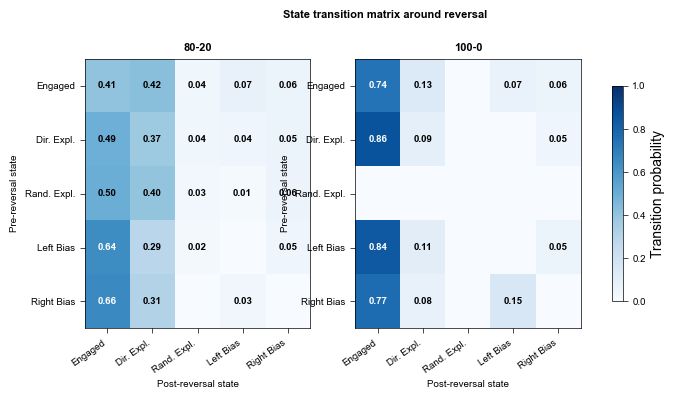

In [197]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))

for ax, matrix, title in [
    (axes[0], mat_80,  '80-20'),
    (axes[1], mat_100, '100-0'),
]:
    # Shorten state labels for display
    short_labels = ['Engaged', 'Dir. Expl.', 'Rand. Expl.', 'Left Bias', 'Right Bias']
    
    im = ax.imshow(matrix.values, cmap='Blues', vmin=0, vmax=1, aspect='auto')
    
    # Annotate cells
    for i in range(len(STATES_MATRIX)):
        for j in range(len(STATES_MATRIX)):
            val = matrix.values[i, j]
            if val > 0:
                text_color = 'white' if val > 0.6 else 'black'
                ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                        fontsize=FONTSIZE, color=text_color, fontweight='bold')
    
    ax.set_xticks(range(len(STATES_MATRIX)))
    ax.set_yticks(range(len(STATES_MATRIX)))
    ax.set_xticklabels(short_labels, rotation=35, ha='right', fontsize=FONTSIZE)
    ax.set_yticklabels(short_labels, fontsize=FONTSIZE)
    ax.set_xlabel('Post-reversal state', fontsize=FONTSIZE)
    ax.set_ylabel('Pre-reversal state', fontsize=FONTSIZE)
    ax.set_title(title, fontsize=FONTSIZE+1, fontweight='bold')

# Colorbar
cbar = fig.colorbar(im, ax=axes, shrink=0.8, label='Transition probability')
cbar.ax.tick_params(labelsize=FONTSIZE)

plt.suptitle('State transition matrix around reversal',
             fontsize=FONTSIZE+1, fontweight='bold', y=1.02)
plt.savefig('StateTransitionMatrix.svg', dpi=300, bbox_inches='tight')
print("✓ Saved StateTransitionMatrix.svg")
plt.show()

In [198]:
# Get trial-by-trial states around each reversal for each animal
def get_reversal_state_raster(df, session_col, 
                               pre_window=10, post_window=20,
                               animals=None):
    records = []
    
    for (animal, session), sdf in df.groupby(['Animal_Name', session_col]):
        if animals and animal not in animals:
            continue
        sdf = sdf.sort_values('Trial').reset_index(drop=True)
        rev_idx = sdf.index[sdf['Block_Transition'] == 1].tolist()
        
        for rev_num, idx in enumerate(rev_idx):
            start = idx - pre_window
            end   = min(idx + post_window, len(sdf))
            if start < 0:
                continue
                
            window = sdf.iloc[start:end].copy()
            window['Trial_Relative'] = np.arange(len(window)) - pre_window
            window['reversal_num']   = rev_num
            window['Animal_Name']    = animal
            records.append(window[['Animal_Name', 'reversal_num', 
                                   'Trial_Relative', 'Behavioral_State',
                                   'High_Prob']])
    
    return pd.concat(records) if records else None

raster_80  = get_reversal_state_raster(df_80_q,  'Session_ID',
                                        animals=animals_ov)
raster_100 = get_reversal_state_raster(df_100_q, 'Fit_Session_ID',
                                        animals=animals_ov)

print(f"80-20:  {len(raster_80):,} trial-reversal observations")
print(f"100-0:  {len(raster_100):,} trial-reversal observations")

# Check reversal counts per animal
print("\n80-20 reversals per animal:")
print(raster_80.groupby('Animal_Name')['reversal_num'].nunique())
print("\n100-0 reversals per animal:")
print(raster_100.groupby('Animal_Name')['reversal_num'].nunique())

80-20:  52,463 trial-reversal observations
100-0:  5,452 trial-reversal observations

80-20 reversals per animal:
Animal_Name
Fiona        27
Knuckles     27
Sonic        29
Sunflower    22
Zazu         17
Name: reversal_num, dtype: int64

100-0 reversals per animal:
Animal_Name
Fiona        21
Knuckles      3
Sonic         3
Sunflower     2
Zazu         19
Name: reversal_num, dtype: int64


In [199]:
# Classify each reversal as fast or slow based on trials 1-5 post-reversal accuracy
def classify_reversal_speed(raster_df, threshold=0.6):
    records = []
    for (animal, rev_num), grp in raster_df.groupby(['Animal_Name','reversal_num']):
        post_early = grp[(grp['Trial_Relative'] >= 1) & 
                         (grp['Trial_Relative'] <= 5)]
        if len(post_early) < 3:
            continue
        acc = post_early['High_Prob'].mean()
        records.append({
            'Animal_Name':   animal,
            'reversal_num':  rev_num,
            'adaptation_acc': acc,
            'speed': 'Fast' if acc >= threshold else 'Slow'
        })
    return pd.DataFrame(records)

speed_80  = classify_reversal_speed(raster_80)
speed_100 = classify_reversal_speed(raster_100)

print("80-20 fast vs slow:")
print(speed_80['speed'].value_counts())
print("\n100-0 fast vs slow:")
print(speed_100['speed'].value_counts())

80-20 fast vs slow:
speed
Fast    62
Slow    60
Name: count, dtype: int64

100-0 fast vs slow:
speed
Fast    26
Slow    22
Name: count, dtype: int64


✓ Saved StateRaster.svg


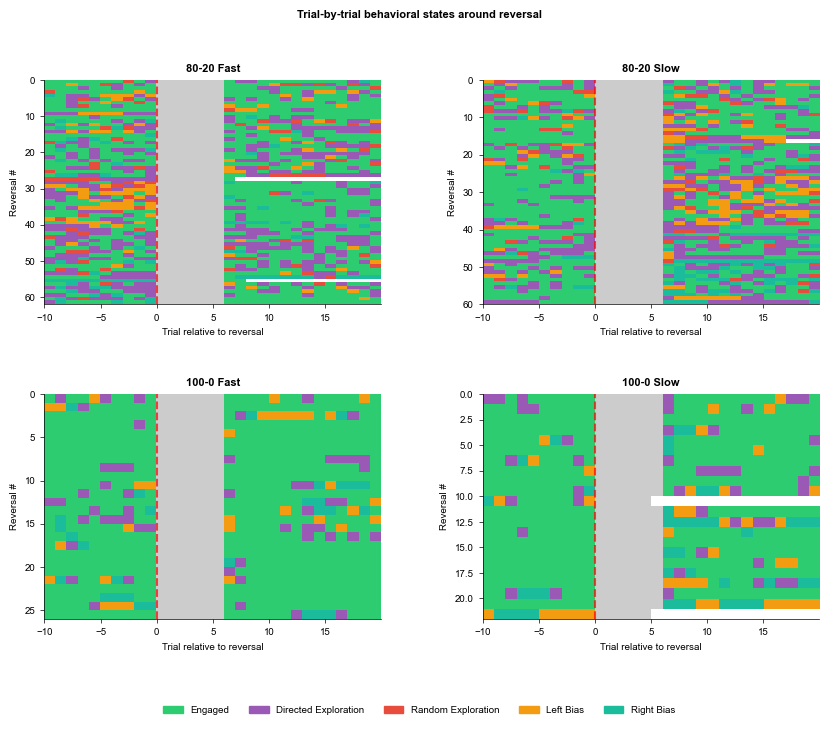

In [222]:
# Merge speed classification back into raster
raster_80_spd  = raster_80.merge(speed_80,  on=['Animal_Name','reversal_num'])
raster_100_spd = raster_100.merge(speed_100, on=['Animal_Name','reversal_num'])

# State to integer mapping for color
STATE_INT = {
    'Engaged':              0,
    'Directed Exploration': 1,
    'Random Exploration':   2,
    'Left Bias':            3,
    'Right Bias':           4,
    'Adapting':             5,
    'Unknown':              6,
}
STATE_CMAP = [
    STATE_COLORS['Engaged'],
    STATE_COLORS['Directed Exploration'],
    STATE_COLORS['Random Exploration'],
    STATE_COLORS['Left Bias'],
    STATE_COLORS['Right Bias'],
    '#cccccc',  # Adapting
    '#ffffff',  # Unknown
]

from matplotlib.colors import ListedColormap
cmap_states = ListedColormap(STATE_CMAP)

def build_raster_matrix(raster_df, speed_df, speed, 
                         pre=10, post=20, n_states=7):
    """Build matrix of shape (n_reversals, n_trials) for given speed."""
    revs = speed_df[speed_df['speed'] == speed][['Animal_Name','reversal_num']]
    rows = []
    for _, rev in revs.iterrows():
        grp = raster_df[(raster_df['Animal_Name'] == rev['Animal_Name']) &
                        (raster_df['reversal_num'] == rev['reversal_num'])]
        grp = grp.sort_values('Trial_Relative')
        row = []
        for t in range(-pre, post):
            trial = grp[grp['Trial_Relative'] == t]
            if len(trial) == 0:
                row.append(6)  # Unknown
            else:
                state = trial['Behavioral_State'].iloc[0]
                row.append(STATE_INT.get(state, 6))
        rows.append(row)
    return np.array(rows)

fig, axes = plt.subplots(2, 2, figsize=(10, 7),
                          gridspec_kw={'hspace': 0.4, 'wspace': 0.3})

titles = [('80-20 Fast', raster_80_spd,  speed_80,  'Fast'),
          ('80-20 Slow', raster_80_spd,  speed_80,  'Slow'),
          ('100-0 Fast', raster_100_spd, speed_100, 'Fast'),
          ('100-0 Slow', raster_100_spd, speed_100, 'Slow')]

x_ticks = range(-10, 20, 5)

for ax, (title, raster, speed_df, speed) in zip(axes.flat, titles):
    mat = build_raster_matrix(raster, speed_df, speed)
    
    ax.imshow(mat, aspect='auto', cmap=cmap_states,
              vmin=0, vmax=6, interpolation='none',
              extent=[-10, 20, len(mat), 0])
    
    ax.axvline(0, color='red', lw=1.5, ls='--', alpha=0.7)
    ax.set_xlabel('Trial relative to reversal', fontsize=FONTSIZE)
    ax.set_ylabel('Reversal #', fontsize=FONTSIZE)
    ax.set_title(title, fontsize=FONTSIZE+1, fontweight='bold')
    ax.set_xticks(x_ticks)
    ax.tick_params(labelsize=FONTSIZE, length=TICK_LENGTH)
    ax.spines[['top','right']].set_visible(False)

# Legend
legend_elements = [plt.Rectangle((0,0),1,1, color=STATE_CMAP[i], 
                                  label=s)
                   for s, i in STATE_INT.items() 
                   if s not in ['Adapting','Unknown']]
fig.legend(handles=legend_elements, loc='lower center', ncol=5,
           frameon=False, fontsize=FONTSIZE,
           bbox_to_anchor=(0.5, -0.04))

plt.suptitle('Trial-by-trial behavioral states around reversal',
             fontsize=FONTSIZE+1, fontweight='bold')
plt.savefig(os.path.join(FIGURE_PATH, 'StateRaster.svg'), dpi=300, bbox_inches='tight')
print("✓ Saved StateRaster.svg")
plt.show()

In [194]:
# ── Zero-Q model for both conditions ─────────────────────────────────────────
KAPPA_ZERO_Q = 1.264  # fixed from 80-20 animal-level mean

for df_cond, label in [(df_80_q, '80-20'), (df_100_q, '100-0')]:
    df_cond['Model_P_Right_ZeroQ'] = df_cond['Choice_Lag1'].map({
        1.0:  1 / (1 + np.exp(-KAPPA_ZERO_Q)),
        0.0:  1 / (1 + np.exp( KAPPA_ZERO_Q)),
    })
    
    df_cond['ZeroQ_Prediction'] = (df_cond['Model_P_Right_ZeroQ'] > 0.5).astype(float)
    df_cond['Follows_ZeroQ']    = (df_cond['Choice_Binary'] == df_cond['ZeroQ_Prediction']).astype(float)

    print(f"\n{label}:")
    print(f"  P(follows zero-Q): {df_cond['Follows_ZeroQ'].mean():.3f}")
    print(f"  P(follows Q-value): {df_cond['Chose_Higher_Q'].mean():.3f}")

# ── Per-animal paired comparison ──────────────────────────────────────────────
print("\nPer-animal Zero-Q following:")
for a in animals_ov:
    v80  = df_80_q[df_80_q['Animal_Name']==a]['Follows_ZeroQ'].mean()
    v100 = df_100_q[df_100_q['Animal_Name']==a]['Follows_ZeroQ'].mean()
    print(f"  {a:12s}  80-20: {v80:.3f}  100-0: {v100:.3f}  Δ={v100-v80:+.3f}")

v80_arr  = [df_80_q[df_80_q['Animal_Name']==a]['Follows_ZeroQ'].mean() 
            for a in animals_ov]
v100_arr = [df_100_q[df_100_q['Animal_Name']==a]['Follows_ZeroQ'].mean() 
            for a in animals_ov]
_, p = ttest_rel(v80_arr, v100_arr)
print(f"\nPaired t-test: p={p:.3f} "
      f"{'***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'n.s.'}")


80-20:
  P(follows zero-Q): 0.804
  P(follows Q-value): 0.706


KeyError: 'Choice_Lag1'

In [153]:
def animal_violation_rate(df, animals, threshold=0.1):
    records = []
    for animal in animals:
        df_a = df[df['Animal_Name'] == animal].dropna(
            subset=['Q_diff','Choice_Binary'])
        df_a = df_a[df_a['Q_diff'].abs() > threshold]
        if len(df_a) < 10:
            continue
        viol = (
            ((df_a['Choice_Binary'] == 1) & (df_a['Q_diff'] < 0)) |
            ((df_a['Choice_Binary'] == 0) & (df_a['Q_diff'] > 0))
        ).mean()
        records.append({'Animal_Name': animal, 'violation_rate': viol})
    return pd.DataFrame(records).set_index('Animal_Name')

viol_80  = animal_violation_rate(df_80_q,  animals_ov)
viol_100 = animal_violation_rate(df_100_q, animals_ov)

print("Per-animal violation rates:")
for a in animals_ov:
    v80  = viol_80.loc[a,  'violation_rate']
    v100 = viol_100.loc[a, 'violation_rate']
    print(f"  {a:12s}  80-20: {v80:.3f}  100-0: {v100:.3f}  Δ={v100-v80:+.3f}")

_, p = ttest_rel(viol_80['violation_rate'].values,
                 viol_100['violation_rate'].values)
print(f"\nPaired t-test: p={p:.3f} "
      f"{'***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'n.s.'}")
      
viol_80  = animal_violation_rate(df_80_q,  animals_ov)
viol_100 = animal_violation_rate(df_100_q, animals_ov)

print("Per-animal violation rates:")
for a in animals_ov:
    v80  = viol_80.loc[a,  'violation_rate']
    v100 = viol_100.loc[a, 'violation_rate']
    print(f"  {a:12s}  80-20: {v80:.3f}  100-0: {v100:.3f}  Δ={v100-v80:+.3f}")

_, p = ttest_rel(viol_80['violation_rate'].values,
                 viol_100['violation_rate'].values)
print(f"\nPaired t-test: p={p:.3f} "
      f"{'***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'n.s.'}")

Per-animal violation rates:
  Fiona         80-20: 0.216  100-0: 0.161  Δ=-0.055
  Knuckles      80-20: 0.246  100-0: 0.238  Δ=-0.008
  Sonic         80-20: 0.294  100-0: 0.170  Δ=-0.124
  Zazu          80-20: 0.303  100-0: 0.180  Δ=-0.123
  Sunflower     80-20: 0.218  100-0: 0.236  Δ=+0.017

Paired t-test: p=0.114 n.s.
Per-animal violation rates:
  Fiona         80-20: 0.216  100-0: 0.161  Δ=-0.055
  Knuckles      80-20: 0.246  100-0: 0.238  Δ=-0.008
  Sonic         80-20: 0.294  100-0: 0.170  Δ=-0.124
  Zazu          80-20: 0.303  100-0: 0.180  Δ=-0.123
  Sunflower     80-20: 0.218  100-0: 0.236  Δ=+0.017

Paired t-test: p=0.114 n.s.


In [223]:
ANIMALS_80

['Fiona', 'Knuckles', 'Sonic', 'Sunflower', 'Zazu']

In [160]:
STATES_NO_ADAPT = ['Engaged', 'Directed Exploration', 
                   'Random Exploration', 'Left Bias', 'Right Bias']

def state_proportions_no_adapt(df, animals, exclude_states=['Unknown', 'Adapting']):
    included = [s for s in STATES_ORDERED if s not in exclude_states]
    records  = []
    for animal, adf in df.groupby('Animal_Name'):
        if animal not in animals:
            continue
        total = adf['Behavioral_State'].isin(included).sum()
        row   = {'Animal_Name': animal}
        for state in included:
            count = (adf['Behavioral_State'] == state).sum()
            row[state] = count / total if total > 0 else np.nan
        records.append(row)
    return pd.DataFrame(records).set_index('Animal_Name')

props_80_na  = state_proportions_no_adapt(df_80_q,  ANIMALS_80)
props_100_na = state_proportions_no_adapt(df_100_q, ANIMALS_100)

# Verify
print(props_80_na.round(3))
print(props_80_na.sum(axis=1))  # should be 1.0

# Stats
print(f"\n{'State':25s}  {'80-20':>6}  {'100-0':>6}  {'p':>6}  sig")
print("-" * 55)
for state in STATES_NO_ADAPT:
    v80  = np.array([props_80_na.loc[a,  state] for a in OVERLAPPING_ANIMALS])
    v100 = np.array([props_100_na.loc[a, state] for a in OVERLAPPING_ANIMALS])
    _, p = ttest_rel(v80, v100)
    sig  = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'n.s.'
    print(f"  {state:23s}  {v80.mean()*100:6.1f}%  {v100.mean()*100:6.1f}%  "
          f"{p:6.3f}  {sig}")

             Engaged  Directed Exploration  Random Exploration  Left Bias  \
Animal_Name                                                                 
Fiona          0.605                 0.240               0.052      0.068   
Knuckles       0.527                 0.313               0.058      0.044   
Sonic          0.522                 0.263               0.059      0.137   
Sunflower      0.487                 0.367               0.062      0.026   
Zazu           0.515                 0.270               0.043      0.037   

             Right Bias  
Animal_Name              
Fiona             0.034  
Knuckles          0.058  
Sonic             0.019  
Sunflower         0.058  
Zazu              0.135  
Animal_Name
Fiona        1.0
Knuckles     1.0
Sonic        1.0
Sunflower    1.0
Zazu         1.0
dtype: float64

State                       80-20   100-0       p  sig
-------------------------------------------------------
  Engaged                    53.1%    74.8%   0.000  *

✓ Saved BehavioralState_Comparison_NoAdapt.svg


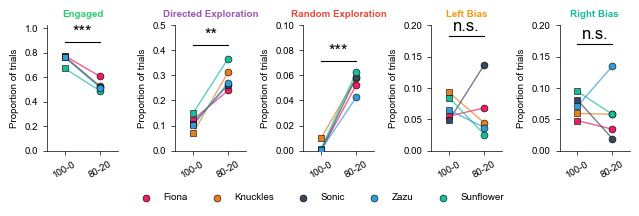

In [221]:
sig_map = {
    'Engaged':              '***',
    'Directed Exploration': '**',
    'Random Exploration':   '***',
    'Left Bias':            'n.s.',
    'Right Bias':           'n.s.',
}

fig, axes = plt.subplots(1, len(STATES_NO_ADAPT), figsize=(6.5, 2))


for ax, state in zip(axes, STATES_NO_ADAPT):
    v80  = np.array([props_80_na.loc[a, state] for a in OVERLAPPING_ANIMALS])
    v100 = np.array([props_100_na.loc[a, state] for a in OVERLAPPING_ANIMALS])

    # # Unpaired 100-0 animals
    # for a in UNPAIRED_100:
    #     if a in props_100_na.index:
    #         ax.scatter([1], [props_100_na.loc[a, state]],
    #                    color=ANIMAL_COLORS[a], s=25,
    #                    marker='s', edgecolor='black',
    #                    linewidth=0.4, alpha=0.5, zorder=3)

    # Paired lines
    for a in OVERLAPPING_ANIMALS:
        ax.plot([0, 1], [props_100_na.loc[a, state], props_80_na.loc[a, state]],
                color=ANIMAL_COLORS[a], lw=LINE_WIDTH, alpha=0.7, zorder=2)
        ax.scatter([1], [props_80_na.loc[a, state]],
                   color=ANIMAL_COLORS[a], s=25,
                   edgecolor='black', linewidth=0.4, zorder=3)
        ax.scatter([0], [props_100_na.loc[a, state]],
                   color=ANIMAL_COLORS[a], s=25,
                   marker='s', edgecolor='black', linewidth=0.4, zorder=3)

    # # Mean ± SEM
    # for x, vals in [(0,v100 ), (1, v80)]:
    #     ax.errorbar(x, vals.mean(), yerr=sem(vals),
    #                 fmt='o', color='black', markersize=5,
    #                 capsize=3, linewidth=LINE_WIDTH*1.5, zorder=5)

    # Significance
    sig  = sig_map[state]
    ymax = max(props_100_na[state].max(), props_80_na[state].max()) * 1.15
    ax.plot([0, 1], [ymax, ymax], color='black', lw=0.8)
    ax.text(0.5, ymax*1.02, sig, ha='center', va='bottom', fontsize=12)

    ax.set_xticks([0, 1])
    ax.set_xticklabels(['100-0', '80-20'], fontsize=FONTSIZE, rotation=30)
    ax.set_ylabel('Proportion of trials', fontsize=FONTSIZE)
    ax.set_title(state, fontsize=FONTSIZE, color=STATE_COLORS[state],
                 fontweight='bold')
    
    ax.set_xlim(-0.5, 1.5)
    # Set Right and left Bias ylim to be 0, 0.20
    if state == 'Right Bias':
        ax.set_ylim(0, 0.20)
    elif state == 'Left Bias':
        ax.set_ylim(0, 0.20)
    elif state == 'Random Exploration':
        ax.set_ylim(0, 0.10)
    elif state == 'Directed Exploration':
        ax.set_ylim(0, 0.50)
    else:
        ax.set_ylim(0, ymax * 1.15)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(labelsize=FONTSIZE, length=TICK_LENGTH)

# Legend
handles = [plt.scatter([], [], color=ANIMAL_COLORS[a], s=25,
                       edgecolor='black', linewidth=0.4, label=a)
           for a in ANIMAL_ORDER if a in OVERLAPPING_ANIMALS]
fig.legend(handles=handles, loc='lower center', ncol=7,
           frameon=False, fontsize=FONTSIZE,
           bbox_to_anchor=(0.5, -0.08))

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_PATH, 'BehavioralState_Comparison_NoAdapt.svg'), dpi=300, bbox_inches='tight')
print("✓ Saved BehavioralState_Comparison_NoAdapt.svg")
plt.show()

In [ ]:
sig_map = {
    'Engaged':              '***',
    'Directed Exploration': '**',
    'Random Exploration':   '***',
    'Left Bias':            'n.s.',
    'Right Bias':           'n.s.',
}

fig, axes = plt.subplots(1, len(STATES_NO_ADAPT), figsize=(6.5, 2))


for ax, state in zip(axes, STATES_NO_ADAPT):
    v80  = np.array([props_80_na.loc[a, state] for a in OVERLAPPING_ANIMALS])
    v100 = np.array([props_100_na.loc[a, state] for a in OVERLAPPING_ANIMALS])

    # # Unpaired 100-0 animals
    # for a in UNPAIRED_100:
    #     if a in props_100_na.index:
    #         ax.scatter([1], [props_100_na.loc[a, state]],
    #                    color=ANIMAL_COLORS[a], s=25,
    #                    marker='s', edgecolor='black',
    #                    linewidth=0.4, alpha=0.5, zorder=3)

    # Paired lines
    for a in OVERLAPPING_ANIMALS:
        ax.plot([0, 1], [props_100_na.loc[a, state], props_80_na.loc[a, state]],
                color=ANIMAL_COLORS[a], lw=LINE_WIDTH, alpha=0.7, zorder=2)
        ax.scatter([1], [props_80_na.loc[a, state]],
                   color=ANIMAL_COLORS[a], s=25,
                   edgecolor='black', linewidth=0.4, zorder=3)
        ax.scatter([0], [props_100_na.loc[a, state]],
                   color=ANIMAL_COLORS[a], s=25,
                   marker='s', edgecolor='black', linewidth=0.4, zorder=3)

    # # Mean ± SEM
    # for x, vals in [(0,v100 ), (1, v80)]:
    #     ax.errorbar(x, vals.mean(), yerr=sem(vals),
    #                 fmt='o', color='black', markersize=5,
    #                 capsize=3, linewidth=LINE_WIDTH*1.5, zorder=5)

    # Significance
    sig  = sig_map[state]
    ymax = max(props_100_na[state].max(), props_80_na[state].max()) * 1.15
    ax.plot([0, 1], [ymax, ymax], color='black', lw=0.8)
    ax.text(0.5, ymax*1.02, sig, ha='center', va='bottom', fontsize=12)

    ax.set_xticks([0, 1])
    ax.set_xticklabels(['100-0', '80-20'], fontsize=FONTSIZE, rotation=30)
    ax.set_ylabel('Proportion of trials', fontsize=FONTSIZE)
    ax.set_title(state, fontsize=FONTSIZE, color=STATE_COLORS[state],
                 fontweight='bold')
    
    ax.set_xlim(-0.5, 1.5)
    # Set Right and left Bias ylim to be 0, 0.20
    if state == 'Right Bias':
        ax.set_ylim(0, 0.20)
    elif state == 'Left Bias':
        ax.set_ylim(0, 0.20)
    elif state == 'Random Exploration':
        ax.set_ylim(0, 0.10)
    elif state == 'Directed Exploration':
        ax.set_ylim(0, 0.50)
    else:
        ax.set_ylim(0, ymax * 1.15)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(labelsize=FONTSIZE, length=TICK_LENGTH)

# Legend
handles = [plt.scatter([], [], color=ANIMAL_COLORS[a], s=25,
                       edgecolor='black', linewidth=0.4, label=a)
           for a in ANIMAL_ORDER if a in OVERLAPPING_ANIMALS]
fig.legend(handles=handles, loc='lower center', ncol=7,
           frameon=False, fontsize=FONTSIZE,
           bbox_to_anchor=(0.5, -0.08))

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_PATH, 'BehavioralState_Comparison_NoAdapt.svg'), dpi=300, bbox_inches='tight')
print("✓ Saved BehavioralState_Comparison_NoAdapt.svg")
plt.show()

In [142]:
# Extract mean switch rate at trials 1-3 post-reversal per animal
def post_reversal_switch(aligned_df, animals):
    records = []
    # Need animal info — merge back from original df
    post = aligned_df[(aligned_df['Trial_Relative'] >= 1) & 
                      (aligned_df['Trial_Relative'] <= 3)]
    # aligned_df doesn't have Animal_Name — need to recompute with animal info
    return post['Switched'].mean()

# Recompute aligned switching with animal info included
def get_reversal_aligned_switching_with_animal(df, session_col='Session_ID',
                                                window_before=5, window_after=10):
    all_aligned = []
    for session_id in df[session_col].unique():
        session_data = df[df[session_col] == session_id].reset_index(drop=True).copy()
        animal = session_data['Animal_Name'].iloc[0]
        session_data['Switched'] = (
            session_data['Choice_Binary'] != session_data['Choice_Binary'].shift(1)
        ).astype(float)
        reversals = session_data[session_data['Block_Transition'] == 1].index.tolist()
        if len(reversals) > 0 and reversals[0] < window_before:
            reversals = reversals[1:]
        for rev_idx in reversals:
            start = rev_idx - window_before
            end   = min(rev_idx + window_after, len(session_data))
            if start >= 0 and (end - rev_idx) >= 10:
                block_window = session_data.iloc[start:end].copy()
                block_window['Trial_Relative'] = np.arange(len(block_window)) - window_before
                block_window['Animal_Name']    = animal
                all_aligned.append(block_window[['Trial_Relative','Switched','Animal_Name']])
    return pd.concat(all_aligned) if all_aligned else None

sw_80_an  = get_reversal_aligned_switching_with_animal(df_80_q,  'Session_ID')
sw_100_an = get_reversal_aligned_switching_with_animal(df_100_q, 'Fit_Session_ID')

# Animal-level mean post-reversal switch rate (trials 1-3)
post_sw_80 = (sw_80_an[sw_80_an['Trial_Relative'].between(1,3)]
              .groupby('Animal_Name')['Switched'].mean())
post_sw_100 = (sw_100_an[sw_100_an['Trial_Relative'].between(1,3)]
               .groupby('Animal_Name')['Switched'].mean())

print("Post-reversal switch rate (trials 1-3):")
for a in animals_ov:
    v80  = post_sw_80.loc[a]  if a in post_sw_80.index  else np.nan
    v100 = post_sw_100.loc[a] if a in post_sw_100.index else np.nan
    print(f"  {a:12s}  80-20: {v80:.3f}  100-0: {v100:.3f}  Δ={v100-v80:+.3f}")

_, p = ttest_rel(
    [post_sw_80.loc[a]  for a in animals_ov],
    [post_sw_100.loc[a] for a in animals_ov]
)
print(f"\nPaired t-test: p={p:.3f}")

Post-reversal switch rate (trials 1-3):
  Fiona         80-20: 0.208  100-0: 0.228  Δ=+0.019
  Knuckles      80-20: 0.252  100-0: 0.333  Δ=+0.082
  Sonic         80-20: 0.217  100-0: 0.304  Δ=+0.087
  Zazu          80-20: 0.167  100-0: 0.227  Δ=+0.061
  Sunflower     80-20: 0.292  100-0: 0.250  Δ=-0.042

Paired t-test: p=0.158


In [126]:
def get_reversal_aligned_switching(df, window_before=5, window_after=20):
    """
    Extract switching rate around reversals
    """
    all_aligned = []
    
    for session_id in df['Session_ID'].unique():
        session_data = df[df['Session_ID'] == session_id].reset_index(drop=True).copy()
        
        # Calculate switching (changed choice from previous trial)
        session_data['Switched'] = (
            session_data['Choice_Binary'] != session_data['Choice_Binary'].shift(1)
        ).astype(float)
        
        # Find reversals
        reversals = session_data[session_data['Block_Transition'] == 1].index.tolist()
        
        if len(reversals) > 0 and reversals[0] < window_before:
            reversals = reversals[1:]
        
        for rev_idx in reversals:
            start = rev_idx - window_before
            end = min(rev_idx + window_after, len(session_data))
            
            if start >= 0 and (end - rev_idx) >= 10:
                block_window = session_data.iloc[start:end].copy()
                block_window['Trial_Relative'] = np.arange(len(block_window)) - window_before
                
                all_aligned.append(block_window[['Trial_Relative', 'Switched']])
    
    if len(all_aligned) > 0:
        return pd.concat(all_aligned)
    else:
        return None

def get_epoch_switching(df, window_pre=5, window_post_early=5, window_late=5):
    """
    Get switching rate in 3 epochs
    """
    results = []
    
    for session_id in df['Session_ID'].unique():
        session_data = df[df['Session_ID'] == session_id].reset_index(drop=True).copy()
        
        # Calculate switching
        session_data['Switched'] = (
            session_data['Choice_Binary'] != session_data['Choice_Binary'].shift(1)
        ).astype(float)
        
        animal = session_data['Animal_Name'].iloc[0] if 'Animal_Name' in session_data.columns else 'Unknown'
        
        reversals = session_data[session_data['Block_Transition'] == 1].index.tolist()
        
        if len(reversals) > 0 and reversals[0] < window_pre:
            reversals = reversals[1:]
        
        for i, rev_idx in enumerate(reversals):
            pre_start = rev_idx - window_pre
            pre_end = rev_idx
            post_start = rev_idx
            post_end = min(rev_idx + window_post_early, len(session_data))
            
            if i < len(reversals) - 1:
                next_rev = reversals[i + 1]
                late_start = max(rev_idx, next_rev - window_late)
                late_end = next_rev
            else:
                late_start = max(rev_idx, len(session_data) - window_late)
                late_end = len(session_data)
            
            if pre_start >= 0 and (post_end - post_start) >= 3 and (late_end - late_start) >= 3:
                pre_data = session_data.iloc[pre_start:pre_end]
                post_data = session_data.iloc[post_start:post_end]
                late_data = session_data.iloc[late_start:late_end]
                
                results.append({
                    'session_id': session_id,
                    'animal': animal,
                    'reversal_idx': i,
                    'pre': pre_data['Switched'].mean(),
                    'post': post_data['Switched'].mean(),
                    'late': late_data['Switched'].mean()
                })
    
    return pd.DataFrame(results)


In [127]:
# ============================================================================
# SWITCHING BEHAVIOR ANALYSIS (3 PANELS)
# ============================================================================
# ── Add session column alias for 100-0 ───────────────────────────────────────
df_100_q['Session_ID'] = df_100_q['Fit_Session_ID']

# ── Run switching analysis ────────────────────────────────────────────────────
print("Processing switching data...")
switching_80_aligned  = get_reversal_aligned_switching(df_80_q,
                            window_before=5, window_after=10)
switching_100_aligned = get_reversal_aligned_switching(df_100_q,
                            window_before=5, window_after=10)

switching_epochs_80  = get_epoch_switching(df_80_q)
switching_epochs_100 = get_epoch_switching(df_100_q)

# Animal-level aggregation
animal_switch_80  = switching_epochs_80.groupby('animal')[['pre','post','late']].mean()
animal_switch_100 = switching_epochs_100.groupby('animal')[['pre','post','late']].mean()

# Quick sanity check
print(f"80-20:  {len(switching_80_aligned):,} aligned trials, "
      f"{len(switching_epochs_80)} reversal epochs")
print(f"100-0:  {len(switching_100_aligned):,} aligned trials, "
      f"{len(switching_epochs_100)} reversal epochs")
print(f"\n80-20 animals:  {sorted(animal_switch_80.index.tolist())}")
print(f"100-0 animals:  {sorted(animal_switch_100.index.tolist())}")
print(f"\n80-20 epoch means:\n{animal_switch_80.round(3)}")
print(f"\n100-0 epoch means:\n{animal_switch_100.round(3)}")

Processing switching data...
80-20:  26,040 aligned trials, 1773 reversal epochs
100-0:  4,080 aligned trials, 275 reversal epochs

80-20 animals:  ['Fiona', 'Knuckles', 'Sonic', 'Sunflower', 'Zazu']
100-0 animals:  ['Coral', 'Fiona', 'Knuckles', 'Raven', 'Sonic', 'Sunflower', 'Zazu']

80-20 epoch means:
             pre   post   late
animal                        
Fiona      0.130  0.179  0.143
Knuckles   0.201  0.237  0.213
Sonic      0.151  0.202  0.150
Sunflower  0.212  0.255  0.214
Zazu       0.168  0.178  0.180

100-0 epoch means:
             pre   post   late
animal                        
Coral      0.217  0.233  0.333
Fiona      0.138  0.210  0.102
Knuckles   0.225  0.300  0.150
Raven      0.180  0.202  0.192
Sonic      0.096  0.278  0.096
Sunflower  0.133  0.225  0.175
Zazu       0.063  0.179  0.075


Switching statistics:

80-20:
  Pre vs Post:  t=-6.91, p=0.0000 ***
  Post vs Late: t=5.76, p=0.0000 ***

100-0:
  Pre vs Post:  t=-6.40, p=0.0000 ***
  Post vs Late: t=5.45, p=0.0000 ***

80-20 vs 100-0:
  pre  : t=3.81, p=0.0001 ***
  post : t=0.96, p=0.3377 n.s.
  late : t=3.87, p=0.0001 ***

✓ Saved switching_behavior_3panel.svg


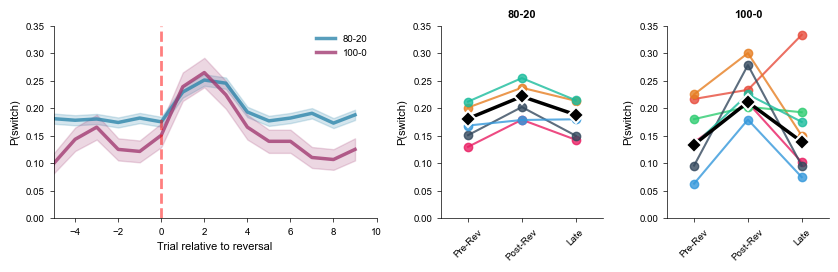

In [178]:
fig = plt.figure(figsize=(10, 2.5))
gs  = fig.add_gridspec(1, 3, wspace=0.3, width_ratios=[1, 0.5, 0.5])

# ── Panel A: Reversal-aligned switching ──────────────────────────────────────
ax_A = fig.add_subplot(gs[0])

for aligned, color, label in [
    (switching_80_aligned,  COLOR_80_20, '80-20'),
    (switching_100_aligned, COLOR_100_0, '100-0'),
]:
    if aligned is not None:
        grouped = (aligned.groupby('Trial_Relative')['Switched']
                   .agg(['mean', sem]))
        ax_A.plot(grouped.index, grouped['mean'], '-',
                  color=color, linewidth=2.5, alpha=0.8, label=label)
        ax_A.fill_between(grouped.index,
                          grouped['mean'] - grouped['sem'],
                          grouped['mean'] + grouped['sem'],
                          color=color, alpha=0.2)

ax_A.axvline(0, color='red', ls='--', lw=2, alpha=0.5)
ax_A.set_xlabel('Trial relative to reversal', fontsize=FONTSIZE+1)
ax_A.set_ylabel('P(switch)', fontsize=FONTSIZE+1)
ax_A.set_xlim(-5, 10)
ax_A.set_ylim(0, 0.35)
ax_A.legend(frameon=False, fontsize=FONTSIZE)
ax_A.spines[['top','right']].set_visible(False)
ax_A.tick_params(labelsize=FONTSIZE, length=TICK_LENGTH)

# ── Panels B & C: Epoch switching per condition ───────────────────────────────
x_positions = [1, 2, 3]
x_labels    = ['Pre-Rev', 'Post-Rev', 'Late']

for ax_panel, animal_switch, pop_df, title in [
    (fig.add_subplot(gs[1]), animal_switch_80,  switching_epochs_80,  '80-20'),
    (fig.add_subplot(gs[2]), animal_switch_100, switching_epochs_100, '100-0'),
]:
    for animal in sorted(animal_switch.index):
        color  = ANIMAL_COLORS.get(animal, 'gray')
        values = [animal_switch.loc[animal, 'pre'],
                  animal_switch.loc[animal, 'post'],
                  animal_switch.loc[animal, 'late']]
        ax_panel.plot(x_positions, values, 'o-', color=color,
                      linewidth=1.5, markersize=6, alpha=0.8)

    pop_mean = pop_df[['pre','post','late']].mean()
    ax_panel.plot(x_positions,
                  [pop_mean['pre'], pop_mean['post'], pop_mean['late']],
                  'D-', color='black', linewidth=2.5, markersize=8,
                  markeredgecolor='white', markeredgewidth=1.5,
                  alpha=1.0, zorder=10)

    ax_panel.set_xticks(x_positions)
    ax_panel.set_xticklabels(x_labels, fontsize=FONTSIZE, rotation=45)
    ax_panel.set_ylabel('P(switch)', fontsize=FONTSIZE+1)
    ax_panel.set_title(title, fontsize=FONTSIZE+1, fontweight='bold')
    ax_panel.set_xlim(0.5, 3.5)
    ax_panel.set_ylim(0, 0.35)
    ax_panel.spines[['top','right']].set_visible(False)
    ax_panel.tick_params(labelsize=FONTSIZE, length=TICK_LENGTH)

# ── Statistics ────────────────────────────────────────────────────────────────
print("Switching statistics:")
for label, epochs in [('80-20', switching_epochs_80),
                       ('100-0', switching_epochs_100)]:
    t1, p1 = ttest_rel(epochs['pre'],  epochs['post'])
    t2, p2 = ttest_rel(epochs['post'], epochs['late'])
    print(f"\n{label}:")
    print(f"  Pre vs Post:  t={t1:.2f}, p={p1:.4f} "
          f"{'***' if p1<0.001 else '**' if p1<0.01 else '*' if p1<0.05 else 'n.s.'}")
    print(f"  Post vs Late: t={t2:.2f}, p={p2:.4f} "
          f"{'***' if p2<0.001 else '**' if p2<0.01 else '*' if p2<0.05 else 'n.s.'}")

print("\n80-20 vs 100-0:")
for epoch in ['pre', 'post', 'late']:
    t, p = ttest_ind(switching_epochs_80[epoch], switching_epochs_100[epoch])
    print(f"  {epoch:5s}: t={t:.2f}, p={p:.4f} "
          f"{'***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'n.s.'}")

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_PATH, 'switching_behavior_3panel.svg'), dpi=300, bbox_inches='tight')
print("\n✓ Saved switching_behavior_3panel.svg")
plt.show()

In [201]:
# Within Engaged state — does Q-following differ across conditions?
for df_cond, label in [(df_80_q, '80-20'), (df_100_q, '100-0')]:
    engaged = df_cond[df_cond['Behavioral_State'] == 'Engaged']
    print(f"{label} Engaged Q-following: {engaged['Chose_Higher_Q'].mean():.3f}")

80-20 Engaged Q-following: 0.867
100-0 Engaged Q-following: 0.898


In [203]:
# Q-following rate per state per condition per animal
def qfollow_by_state(df, animals, states=STATES_NO_ADAPT):
    records = []
    for animal in animals:
        for state in states:
            mask = ((df['Animal_Name'] == animal) & 
                    (df['Behavioral_State'] == state))
            val = df[mask]['Chose_Higher_Q'].mean()
            records.append({
                'Animal_Name': animal,
                'state':       state,
                'qfollow':     val
            })
    return pd.DataFrame(records)

qf_80  = qfollow_by_state(df_80_q,  animals_ov)
qf_100 = qfollow_by_state(df_100_q, animals_ov)

print("Q-following by state:")
print(f"\n{'State':25s}  {'80-20':>6}  {'100-0':>6}  {'Δ':>6}")
print("-" * 50)
for state in STATES_NO_ADAPT:
    v80  = qf_80[qf_80['state']==state]['qfollow'].mean()
    v100 = qf_100[qf_100['state']==state]['qfollow'].mean()
    print(f"  {state:23s}  {v80:.3f}   {v100:.3f}  {v100-v80:+.3f}")

Q-following by state:

State                       80-20   100-0       Δ
--------------------------------------------------
  Engaged                  0.862   0.907  +0.045
  Directed Exploration     0.659   0.626  -0.033
  Random Exploration       0.499   0.000  -0.499
  Left Bias                0.367   0.435  +0.068
  Right Bias               0.346   0.396  +0.050


✓ Saved QFollowing_ByState.svg


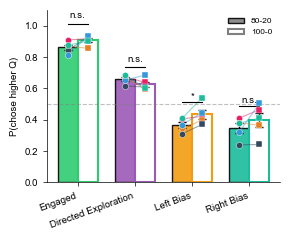

In [206]:
fig, ax = plt.subplots(figsize=(3, 2.5))

states_plot = ['Engaged', 'Directed Exploration', 'Left Bias', 'Right Bias']
x = np.arange(len(states_plot))
width = 0.35

for xi, state in enumerate(states_plot):
    # Individual animal lines
    for animal in animals_ov:
        v80  = qf_80[(qf_80['Animal_Name']==animal) & 
                     (qf_80['state']==state)]['qfollow'].values
        v100 = qf_100[(qf_100['Animal_Name']==animal) & 
                      (qf_100['state']==state)]['qfollow'].values
        if len(v80) > 0 and len(v100) > 0:
            ax.plot([xi - width/2, xi + width/2],
                    [v80[0], v100[0]],
                    color=ANIMAL_COLORS[animal], lw=0.8,
                    alpha=0.5, zorder=2)
            ax.scatter(xi - width/2, v80[0],
                      color=ANIMAL_COLORS[animal], s=20,
                      zorder=3, edgecolor='white', linewidth=0.3)
            ax.scatter(xi + width/2, v100[0],
                      color=ANIMAL_COLORS[animal], s=20,
                      marker='s', zorder=3,
                      edgecolor='white', linewidth=0.3)

    # Group means
    m80  = qf_80[qf_80['state']==state]['qfollow'].mean()
    m100 = qf_100[qf_100['state']==state]['qfollow'].mean()
    s80  = sem(qf_80[qf_80['state']==state]['qfollow'].dropna())
    s100 = sem(qf_100[qf_100['state']==state]['qfollow'].dropna())

    ax.bar(xi - width/2, m80,  width, color=STATE_COLORS[state],
           alpha=0.9, edgecolor='black', linewidth=LINE_WIDTH)
    ax.bar(xi + width/2, m100, width, color='white',
           edgecolor=STATE_COLORS[state], linewidth=1.5)
    ax.errorbar(xi - width/2, m80,  yerr=s80,  fmt='none',
                color='black', capsize=3, linewidth=LINE_WIDTH)
    ax.errorbar(xi + width/2, m100, yerr=s100, fmt='none',
                color='black', capsize=3, linewidth=LINE_WIDTH)

    # Stats
    v80_arr  = qf_80[qf_80['state']==state]['qfollow'].values
    v100_arr = qf_100[qf_100['state']==state]['qfollow'].values
    if len(v80_arr) >= 2 and len(v100_arr) >= 2:
        _, p = ttest_rel(v80_arr, v100_arr)
        sig  = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'n.s.'
        ymax = max(m80 + s80, m100 + s100) * 1.1
        ax.plot([xi - width/2, xi + width/2], [ymax, ymax],
                color='black', lw=0.8)
        ax.text(xi, ymax * 1.02, sig, ha='center',
                va='bottom', fontsize=FONTSIZE)

ax.axhline(0.5, color='gray', ls='--', lw=0.8, alpha=0.5)
ax.set_xticks(x)
ax.set_xticklabels(states_plot, rotation=20, ha='right', fontsize=FONTSIZE)
ax.set_ylabel('P(chose higher Q)', fontsize=FONTSIZE)
ax.set_ylim(0, 1.1)
ax.legend([Patch(facecolor='gray', alpha=0.9, edgecolor='black'),
           Patch(facecolor='white', edgecolor='gray', linewidth=1.5)],
          ['80-20','100-0'], fontsize=FONTSIZE-1, frameon=False)
ax.spines[['top','right']].set_visible(False)
ax.tick_params(labelsize=FONTSIZE, length=TICK_LENGTH)

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_PATH, 'QFollowing_ByState.svg'), dpi=300, bbox_inches='tight')
print("✓ Saved QFollowing_ByState.svg")
plt.show()